<div style="background:#fafbfc; border:1px solid #d8d9dc; border-radius:12px; padding:22px; margin:16px 0 28px 0; color:#26313f; ">

<h1 style="margin-top:0; font-weight:900;">Image Pair Ranking</h1>

<p>
<b>Kaggle:</b> Yulia Nikitina<br>
<b>Real name:</b> Юлия Никитина<br>
<b>Leaderboard:</b> 2 место
</p>

<img src="./files/lb_screenshot.png" alt="Leaderboard" style="max-width:820px; width:100%; height:auto; margin:8px 0 20px 0;">

<p style="margin:0 0; padding:0 0;"><b>Late submission</b> | до лидера: <code>0.00110</code></p>

<img src="./files/submission_screenshot.png" alt="Late submission" style="max-width:820px; width:100%; height:auto; margin:8px 0 10px 0;">

<p style="margin-top:0; padding-top:0;">
После окончания соревнования я переобучила те же модели <b>с большим числом сидов</b> и усреднила их предсказания. Late private score вырос до <code>0.66122</code>: это выше конкурсного сабмита <code>0.65898</code>. До результата лидера <code>0.66232</code> не хватило <code>0.00110</code> ROC AUC.
</p>

<p>
В рамках соревнования сид-ансамбли успели получить только самые сильные модели. После расширения всех моделей до 11 сидов улучшился private score и немного поменялись веса финального бленда.
</p>

</div>

# Intro

<style>
p { font-size: 14px; line-height: 1.3; margin:14px 0;}
</style>
<p>В этом соревновании нужно предсказать, какую из двух сгенерированных картинок выбрала экспертная комиссия. Известны только сами изображения и бинарный таргет, исходных промптов нет. Train небольшой, а выбор комиссии субъективный, поэтому дообучивать визуальные энкодеры я не стала, риск переобучения здесь выше возможной пользы. Вместо этого я сравнила несколько готовых VLM-эмбеддингов и построила поверх них два типа моделей. CatBoost давал лучший самостоятельный AUC, а самописный Siamese comparator на PyTorch иначе сравнивал изображения и добавлял в бленд отличающиеся предсказания. </p>

### Дневник экспериментов

<style>
  table.exp-hover tr:hover td {
    background: #fbfcfd !important;
  }
</style>

<table class="exp-hover" style="width:100%; border-collapse:collapse; border:none; font-size:14px; line-height:1.25;">
  <tr>
    <td style="width:10px; max-width:30px; color:#c1c6ce; font-weight:900; font-size:20px; white-space:nowrap; vertical-align:top; padding:14px 6px 12px 6px; line-height:0.8em; border:none; border-bottom:1px solid #e5e7eb; background:#ffffff;">1</td>
    <td style="color:#1f2937; padding:10px 14px 12px 14px; vertical-align:top; border:none; border-bottom:1px solid #e5e7eb; background:#ffffff;">
      <b>Baseline на ручных признаках</b>
      <p style="margin:10px 0;">Первая гипотеза: выбор победителя можно объяснить базовыми характеристиками изображения.
        Для каждой картинки рассчитала яркость, контраст, резкость, цветовые статистики и разницу этих значений внутри пары,
        затем обучила на них CatBoost.</p>
      <p style="margin:10px 0;">Результат оказался слабым, простых характеристик было недостаточно, чтобы надежно определить победителя пары. Поэтому дальше я перешла к эмбеддингам изображений.</p>
      <p style="margin:10px 0;">ROC AUC: <code style="background:#f0f0f0; color:#30363d; padding:1px 5px; border-radius:4px; font-size:13px;">0.602</code></p>
    </td>
  </tr>

  <tr>
    <td style="width:10px; max-width:30px; color:#c1c6ce; font-weight:900; font-size:20px; white-space:nowrap; vertical-align:top; padding:14px 6px 12px 6px; line-height:0.8em; border:none; border-bottom:1px solid #e5e7eb; background:#ffffff;">2</td>
    <td style="color:#1f2937; padding:10px 14px 12px 14px; vertical-align:top; border:none; border-bottom:1px solid #e5e7eb; background:#ffffff;">
      <b>Baseline на pre-trained embeddings CLIP ViT-B/32 + CatBoost</b>
      <p style="margin:10px 0;">Первым энкодером стал OpenAI CLIP ViT-B/32. Для каждой пары картинок использовались:</p>
      <ul style="margin:0; padding-left:2em;">
        <li style="margin:0; padding:0;">эмбеддинг image_1;</li>
        <li style="margin:0; padding:0;">эмбеддинг image_2;</li>
        <li style="margin:0; padding:0;">разность эмбеддингов;</li>
        <li style="margin:0; padding:0;">абсолютная разность;</li>
        <li style="margin:0; padding:0;">покомпонентное произведение.</li>
      </ul>
      <p style="margin:10px 0;">CatBoost на этих CLIP-based признаках показал заметно лучший результат, чем на ручных признаках, и стал первым сильным бейзлайном.</p>
      <p style="margin:10px 0;">ROC AUC: <code style="background:#f0f0f0; color:#30363d; padding:1px 5px; border-radius:4px; font-size:13px;">0.645</code></p>
      <p style="margin:10px 0;"><b>Swapped augmentation</b> ухудшила результат. В датасете есть сильная зависимость от позиции, image_2 выигрывает примерно в 65% пар, поэтому исходный порядок изображений сохранялся во всех следующих экспериментах. Впрочем, это могло не сработать, если бы positional bias в test отличался от train.</p>
    </td>
  </tr>

  <tr>
    <td style="width:10px; max-width:30px; color:#c1c6ce; font-weight:900; font-size:20px; white-space:nowrap; vertical-align:top; padding:14px 6px 12px 6px; line-height:0.8em; border:none; border-bottom:1px solid #e5e7eb; background:#ffffff;">3</td>
    <td style="color:#1f2937; padding:10px 14px 12px 14px; vertical-align:top; border:none; border-bottom:1px solid #e5e7eb; background:#ffffff;">
      <b>Проверка aesthetic score и DINOv2</b>
      <p style="margin:10px 0;">После CLIP baseline я проверила еще две гипотезы.</p>
      <ul style="margin:0; padding-left:2em;">
        <li style="margin:0; padding:0;">Первая: комиссия выбирала победителя по общей визуальной привлекательности. Ее я проверила с помощью LAION aesthetic head на эмбеддингах CLIP ViT-B/32.</li>
        <li style="margin:0; padding:0;">Вторая: визуальная структура и локальные детали важнее соответствия промпту. Здесь я взяла DINOv2, vision-only энкодер без обучения на текстовых описаниях.</li>
      </ul>
      <p style="margin:10px 0;">Оба подхода показали результат хуже CLIP ViT-B/32 с CatBoost. Одной оценки привлекательности оказалось недостаточно, выбор комиссии иногда выглядел довольно странно, во многих случаях выигрывали изображения, которые казались менее эстетичными, но, вероятно, лучше соответствовали промпту генерации. DINOv2 тоже оказался слабее CLIP.</p>
      <p style="margin:10px 0;">
        LAION aesthetic ROC AUC: <code style="background:#f0f0f0; color:#30363d; padding:1px 5px; border-radius:4px; font-size:13px;">0.517</code><br>
        DINOv2 ROC AUC: <code style="background:#f0f0f0; color:#30363d; padding:1px 5px; border-radius:4px; font-size:13px;">0.584</code>
      </p>
    </td>
  </tr>

  <tr>
    <td style="width:10px; max-width:30px; color:#c1c6ce; font-weight:900; font-size:20px; white-space:nowrap; vertical-align:top; padding:14px 6px 12px 6px; line-height:0.8em; border:none; border-bottom:1px solid #e5e7eb; background:#ffffff;">4</td>
    <td style="color:#1f2937; padding:10px 14px 12px 14px; vertical-align:top; border:none; border-bottom:1px solid #e5e7eb; background:#ffffff;">
      <b>Добавление Siamese comparator</b>
      <p style="margin:10px 0;">Следующей идеей стала парная нейронная модель на тех же CLIP-эмбеддингах. Я обучила Siamese-сеть на PyTorch с общими весами для двух изображений и MLP-компаратором. Бленд двух моделей дал заметный прирост.</p>
      <p style="margin:10px 0;">Негативное влияние swap augmentation подтвердилось и для Siamese-модели:</p>
      <p style="margin:10px 0;">
        augment_swap=True: <code style="background:#f0f0f0; color:#30363d; padding:1px 5px; border-radius:4px; font-size:13px;">0.655</code><br>
        augment_swap=False: <code style="background:#f0f0f0; color:#30363d; padding:1px 5px; border-radius:4px; font-size:13px;">0.658</code>
      </p>
    </td>
  </tr>

  <tr>
    <td style="width:10px; max-width:30px; color:#c1c6ce; font-weight:900; font-size:20px; white-space:nowrap; vertical-align:top; padding:14px 6px 12px 6px; line-height:0.8em; border:none; border-bottom:1px solid #e5e7eb; background:#ffffff;">5</td>
    <td style="color:#1f2937; padding:10px 14px 12px 14px; vertical-align:top; border:none; border-bottom:1px solid #e5e7eb; background:#ffffff;">
      <b>Расширение набора моделей</b>
      <p style="margin:10px 0;"><b>Энкодеры</b><br>
      Я проверила другие визуальные энкодеры, чтобы найти модели с более точными или просто отличающимися предсказаниями:
      </p>
      <ul style="margin:0; padding-left:2em;">
        <li style="margin:0; padding:0;">CLIP ViT-L/14 дал небольшой прирост, а blend CLIP Base и Large оказался заметно сильнее каждой модели по отдельности.</li>
        <li style="margin:0; padding:0;">SigLIP-256 показал лучший результат среди отдельных моделей на этом этапе и усилил ансамбль.</li>
        <li style="margin:0; padding:0;">SigLIP-384, OpenCLIP ConvNeXt, EVA-B и EVA-L. Самым удачным из этих экспериментов на public leaderboard оказался EVA-B CatBoost. Siamese на EVA-B улучшал локальную метрику, но не public score.</li>
      </ul>
      <p style="margin:10px 0;">Прирост от новых энкодеров постепенно снижался. Перспективные модели я оставила в наборе кандидатов, а позже проверила их пользу для ансамбля через ablation test.</p>
      <p style="margin:10px 0;"><b>Comparator-модели</b><br>
      Кроме Siamese я проверила Pair MLP с другой схемой совместной обработки эмбеддингов двух изображений. Multi-encoder Pair MLP получал эмбеддинги сразу нескольких энкодеров. Устойчивого прироста эти варианты не дали и в финальный ансамбль не вошли.
      </p>
    </td>
  </tr>

  <tr>
    <td style="width:10px; max-width:30px; color:#c1c6ce; font-weight:900; font-size:20px; white-space:nowrap; vertical-align:top; padding:14px 6px 12px 6px; line-height:0.8em; border:none; border-bottom:1px solid #e5e7eb; background:#ffffff;">6</td>
    <td style="color:#1f2937; padding:10px 14px 12px 14px; vertical-align:top; border:none; border-bottom:1px solid #e5e7eb; background:#ffffff;">
      <b>Анализ похожих изображений</b>
      <p style="margin:10px 0;"><b>Similarity-признаки</b>. Анализ ошибок показал, что модели чаще ошибаются на парах с очень похожими изображениями. Сначала я добавила к OOF-предсказаниям cosine similarity, расстояния между эмбеддингами и другие признаки похожести, но локальная метрика ухудшилась. Возможно, они дублировали парные признаки и предсказания моделей. Затем я отдельно подобрала веса ансамбля для простых и сложных пар. На OOF был прирост, но на public он не перенесся.</p>
      <p style="margin:10px 0;"><b>Ближайшие соседи</b>. В датасете не нашлось точных дубликатов по хешу, но некоторые изображения выглядели практически идентично. Поэтому для каждой картинки я искала ближайших соседей в train и использовала частоту их побед как дополнительный признак. На раннем CLIP-стеке KNN-признаки дали небольшой прирост, но после добавления более сильных энкодеров перестали улучшать ансамбль и в финальный набор моделей не вошли.</p>
    </td>
  </tr>

  <tr>
    <td style="width:10px; max-width:30px; color:#c1c6ce; font-weight:900; font-size:20px; white-space:nowrap; vertical-align:top; padding:14px 6px 12px 6px; line-height:0.8em; border:none; border-bottom:1px solid #e5e7eb; background:#ffffff;">7</td>
    <td style="color:#1f2937; padding:10px 14px 12px 14px; vertical-align:top; border:none; border-bottom:1px solid #e5e7eb; background:#ffffff;">
      <b>Проверка мета-моделей</b>
      <p style="margin:10px 0;">Я пробовала заменить линейный бленд обучаемой мета-моделью: Ridge Regression, Logistic Regression и MLP на OOF-предсказаниях. Некоторые варианты улучшали OOF, но прирост не переносился на leaderboard. Похоже, мета-модели переобучались, выборка небольшая, предсказания сильно коррелируют. В финальном решении остался линейный blend.</p>
    </td>
  </tr>

  <tr>
    <td style="width:10px; max-width:30px; color:#c1c6ce; font-weight:900; font-size:20px; white-space:nowrap; vertical-align:top; padding:14px 6px 12px 6px; line-height:0.8em; border:none; border-bottom:1px solid #e5e7eb; background:#ffffff;">8</td>
    <td style="color:#1f2937; padding:10px 14px 12px 14px; vertical-align:top; border:none; border-bottom:1px solid #e5e7eb; background:#ffffff;">
      <b>Seed ensemble</b>
      <p style="margin:10px 0;">После формирования набора кандидатов я переобучила все модели с 11 сидами при одинаковом разбиении на пять фолдов и усреднила OOF-предсказания. Это сгладило разницу между отдельными запусками и улучшило большинство моделей. Основной прирост дали первые пять сидов.</p>
    </td>
  </tr>

  <tr>
    <td style="width:10px; max-width:30px; color:#c1c6ce; font-weight:900; font-size:20px; white-space:nowrap; vertical-align:top; padding:14px 6px 12px 6px; line-height:0.8em; border:none; border-bottom:1px solid #e5e7eb; background:#ffffff;">9</td>
    <td style="color:#1f2937; padding:10px 14px 12px 14px; vertical-align:top; border:none; border-bottom:1px solid #e5e7eb; background:#ffffff;">
      <b>Финальный ансамбль</b>
      <p style="margin:10px 0;"><b>Ablation test</b>. Высокая standalone-метрика еще не означает, что модель улучшит бленд, ее предсказания могут дублировать другие модели. Для проверки я по очереди исключала модели из бленда, заново подбирала веса и смотрела, как меняется качество бленда на OOF. В итоге убрала CLIP Base CatBoost, CLIP Large CatBoost (Siamese-модели для CLIP остались) и EVA-L CatBoost.</p>
      <p style="margin:10px 0;"><b>Подбор весов</b>. Для оставшихся моделей я случайно сгенерировала 50 000 наборов весов и усреднила 100 лучших вариантов, чтобы результат меньше зависел от одной случайно удачной комбинации. Веса подбирались по OOF-предсказаниям, их переносимость на test проверялась уже по leaderboard.</p>
    </td>
  </tr>

  <tr>
    <td style="width:10px; max-width:30px; color:#c1c6ce; font-weight:900; font-size:20px; white-space:nowrap; vertical-align:top; padding:14px 6px 12px 6px; line-height:0.8em; border:none; background:#ffffff;"></td>
    <td style="color:#1f2937; padding:10px 14px 12px 14px; vertical-align:top; border:none; background:#ffffff;">
      <p style="margin:10px 0;"><b>Итог</b><br>В начале соревнования основной прирост давали новые эмбеддинги и модели на их основе. Потом стало сложнее, локально метрика росла, а на leaderboard улучшение часто не переносилось. В финале я оставила семь моделей, прошедших ablation test, усреднила предсказания по сидам и подобрала веса для линейного бленда.</p>
    </td>
  </tr>
</table>

### Применимость в бизнес-процессах

<style>
p { font-size: 14px; line-height: 1.3; margin:14px 0;}
</style>
<p>Самый реалистичный сценарий – предварительный отбор генераций перед ручной проверкой. Например, сервис создает 20 вариантов изображения, модель ранжирует их и показывает дизайнеру или редактору несколько наиболее перспективных. Это сокращает время на просмотр, но не заменяет человека полностью.</p>

<p>Для реального бизнес-процесса улучшение разметки было бы важнее дальнейшего усложнения модели. Сейчас один бинарный выбор скрывает причину решения. Комиссия могла оценивать соответствие промпту, техническое качество, композицию, стиль или просто субъективную привлекательность. Полезнее было бы собирать оценки по отдельным критериям, разрешить вариант "равноценны" и передавать спорные пары нескольким экспертам. Вместо жесткого таргета 0/1 можно использовать долю голосов за каждое изображение. Такая разметка дала бы модели более последовательный сигнал и позволила бы понять причины ее ошибок.</p>

## Описание финального решения

In [1]:
import pandas as pd

print('Финальный ансамбль')
final_weights_df = pd.read_csv('files/final_weights.csv')
(
    final_weights_df
    .style
    .background_gradient(cmap='Blues', subset=['blend weight'])
    .background_gradient(cmap='Greens', subset=['oof auc'])
    .format({
        'blend weight': '{:.3f}',
        'oof auc': '{:.4f}',
    })
)

Финальный ансамбль


,model,blend weight,oof auc
0,siglip_256_catboost,0.202,0.6672
1,siglip_384_catboost,0.198,0.6669
2,eva_b_catboost,0.190,0.6632
3,convnext_catboost,0.130,0.6639
4,clip_base_siamese,0.120,0.6584
5,siglip_256_siamese,0.086,0.6609
6,clip_large_siamese,0.074,0.6548


<br>

### Выбор визуальных энкодеров

<p style="font-size:13px; padding-bottom:20px;">
  <span style="color:#16a34a; font-weight:700;">✓</span> – пробовала, вошло в финальный ансамбль<br>
  <span style="color:#dc2626; font-weight:700;">×</span> – пробовала, не вошло в финальный ансамбль<br>
  <span style="color:#909398;">серый текст</span> – не пробовала<br>
</p>

<table style="border-collapse:collapse; max-width:100%; width:850px; table-layout:fixed; font-size:14px; margin:0 auto 0 0;">
  <colgroup>
    <col style="width:16%;">
    <col style="width:21%;">
    <col style="width:21%;">
    <col style="width:21%;">
    <col style="width:21%;">
  </colgroup>
  <thead>
    <tr>
      <th style="border:1px solid #d1d5db; padding:8px; text-align:left; vertical-align:top; word-wrap:break-word; background:#ffffff;">Architecture / family</th>
      <th style="border:1px solid #d1d5db; padding:8px; text-align:left; vertical-align:top; word-wrap:break-word; background:#ffffff;">Supervised</th>
      <th style="border:1px solid #d1d5db; padding:8px; text-align:left; vertical-align:top; word-wrap:break-word; background:#ffffff;">Contrastive VLM</th>
      <th style="border:1px solid #d1d5db; padding:8px; text-align:left; vertical-align:top; word-wrap:break-word; background:#ffffff;">Sigmoid VLM</th>
      <th style="border:1px solid #d1d5db; padding:8px; text-align:left; vertical-align:top; word-wrap:break-word; background:#ffffff;">Self-supervised</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th style="border:1px solid #d1d5db; padding:8px; text-align:left; vertical-align:top; word-wrap:break-word; background:#ffffff;">ViT</th>
      <td style="border:1px solid #d1d5db; padding:8px; text-align:left; vertical-align:top; word-wrap:break-word; background:#ffffff; color:#9ca3af;">ViT (ImageNet)</td>
      <td style="border:1px solid #d1d5db; padding:8px; text-align:left; vertical-align:top; word-wrap:break-word; background:#ffffff;">
        <span style="color:#16a34a; font-weight:700;">✓</span> CLIP ViT-B/32
        <br><span style="color:#16a34a; font-weight:700;">✓</span> CLIP ViT-L/14
        <hr style="border:none; border-top:1px solid #e5e7eb;">
        <span style="color:#dc2626; font-weight:700;">×</span> LAION aesthetic head
         over CLIP ViT-B/32
      </td>
      <td style="border:1px solid #d1d5db; padding:8px; text-align:left; vertical-align:top; word-wrap:break-word; background:#ffffff;">
        <span style="color:#16a34a; font-weight:700;">✓</span> SigLIP Large 256
        <br><span style="color:#16a34a; font-weight:700;">✓</span> SigLIP Large 384
      </td>
      <td style="border:1px solid #d1d5db; padding:8px; text-align:left; vertical-align:top; word-wrap:break-word; background:#ffffff;">
        <span style="color:#dc2626; font-weight:700;">×</span> DINOv2 ViT-S/14
      </td>
    </tr>
    <tr>
      <th style="border:1px solid #d1d5db; padding:8px; text-align:left; vertical-align:top; word-wrap:break-word; background:#ffffff;">EVA (ViT family)</th>
      <td style="border:1px solid #d1d5db; padding:8px; vertical-align:top; word-wrap:break-word; background:#f9fafb; color:#9ca3af; text-align:center;">—</td>
      <td style="border:1px solid #d1d5db; padding:8px; text-align:left; vertical-align:top; word-wrap:break-word; background:#ffffff;">
        <span style="color:#16a34a; font-weight:700;">✓</span> EVA-CLIP Base
        <br><span style="color:#dc2626; font-weight:700;">×</span> EVA-CLIP Large
      </td>
      <td style="border:1px solid #d1d5db; padding:8px; vertical-align:top; word-wrap:break-word; background:#f9fafb; color:#9ca3af; text-align:center;">—</td>
      <td style="border:1px solid #d1d5db; padding:8px; text-align:left; vertical-align:top; word-wrap:break-word; background:#ffffff; color:#9ca3af;">
        EVA-02
      </td>
    </tr>
    <tr>
      <th style="border:1px solid #d1d5db; padding:8px; text-align:left; vertical-align:top; word-wrap:break-word; background:#ffffff;">CNN / ConvNet</th>
      <td style="border:1px solid #d1d5db; padding:8px; text-align:left; vertical-align:top; word-wrap:break-word; background:#ffffff;">
        <span style="color:#dc2626; font-weight:700;">×</span> ConvNeXt Base (ImageNet)
        <br><span style="color:#9ca3af;">ResNet50
        <br>EfficientNet-B3</span>
      </td>
      <td style="border:1px solid #d1d5db; padding:8px; text-align:left; vertical-align:top; word-wrap:break-word; background:#ffffff;">
        <span style="color:#16a34a; font-weight:700;">✓</span> OpenCLIP ConvNeXt Base
        <br><span style="color:#9ca3af;">CLIP RN50, OpenCLIP RN50</span>
      </td>
      <td style="border:1px solid #d1d5db; padding:8px; vertical-align:top; word-wrap:break-word; background:#f9fafb; color:#9ca3af; text-align:center;">—</td>
      <td style="border:1px solid #d1d5db; padding:8px; text-align:left; vertical-align:top; word-wrap:break-word; background:#ffffff; color:#9ca3af;">MoCo v3 ResNet50</td>
    </tr>
    <tr>
      <th style="border:1px solid #d1d5db; padding:8px; text-align:left; vertical-align:top; word-wrap:break-word; background:#ffffff;">Swin Transformer</th>
      <td style="border:1px solid #d1d5db; padding:8px; text-align:left; vertical-align:top; word-wrap:break-word; background:#ffffff; color:#9ca3af;">Swin-T/B/L, ...</td>
      <td style="border:1px solid #d1d5db; padding:8px; text-align:left; vertical-align:top; word-wrap:break-word; background:#ffffff; color:#9ca3af;">OpenCLIP Swin, ...</td>
      <td style="border:1px solid #d1d5db; padding:8px; vertical-align:top; word-wrap:break-word; background:#f9fafb; color:#9ca3af; text-align:center;">—</td>
      <td style="border:1px solid #d1d5db; padding:8px; text-align:left; vertical-align:top; word-wrap:break-word; background:#ffffff; color:#9ca3af;">SimMIM Swin, ...</td>
    </tr>
  </tbody>
</table>

<p><br></p>

### Архитектура финального решения

<div style="
  background:#101820;
  color:#e5eef7;
  border-radius:10px;
  padding:18px 22px;
  font-family: ui-monospace, SFMono-Regular, Menlo, Monaco, Consolas, monospace;
  font-size:12px;
  line-height:1.55;
  overflow-x:auto;
  width:800px;
  max-width:100%;
">
<pre style="margin:0; color:inherit; background:transparent; border:none;">
PIPELINE
│
├── предсказания базовых моделей
│   │
│   ├── CLIP ViT Base        | CatBoost | Siamese
│   ├── CLIP ViT Large       | CatBoost | Siamese
│   │
│   ├── SigLIP 256           | CatBoost | Siamese
│   ├── SigLIP 384           | CatBoost
│   │
│   ├── OpenCLIP ConvNeXt    | CatBoost
│   │
│   ├── EVA-CLIP Large       | CatBoost
│   └── EVA-CLIP Base        | CatBoost 
│
├── отбор моделей: ablation test по oof ROC AUC
│
└── стабилизация весов
    │
    ├── random search весов по OOF-предсказаниям
    ├── усреднение top-100 наборов весов
    └── final prediction: взвешенная сумма test-предсказаний выбранных моделей
</pre>

<p>&nbsp;</p>

---

# Pipeline

## Импорты \ загрузка датасетов

In [2]:
%autosave 60

import io
import logging
import random
import warnings
from pathlib import Path
import base64
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import FancyBboxPatch
from matplotlib.ticker import PercentFormatter
from PIL import Image, ImageFilter, ImageOps
from IPython.display import HTML, display
from tqdm import tqdm

from catboost import CatBoostClassifier
from joblib import Parallel, delayed
from sklearn.metrics import roc_auc_score
from sklearn.metrics.pairwise import paired_cosine_distances
from sklearn.model_selection import StratifiedKFold, train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

import open_clip
from transformers import AutoModel, AutoProcessor, CLIPModel, CLIPProcessor

warnings.filterwarnings('ignore')
logging.getLogger('huggingface_hub').setLevel(logging.ERROR)

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', 180)

%config InlineBackend.figure_format = 'retina'

Autosaving every 60 seconds


/Users/yulia/Library/CloudStorage/Dropbox/MTC/5_NN/02_img_processing/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# артефакты моделей сохраняются:
ARTEFACTS_DIR = Path('artefacts')
ARTEFACTS_DIR.mkdir(exist_ok=True)

SUBMISSIONS_DIR = Path('submissions')
SUBMISSIONS_DIR.mkdir(exist_ok=True)


In [4]:
# загрузка данных
train = pd.read_parquet("data/train.parquet", engine="fastparquet")
test = pd.read_parquet("data/test.parquet", engine="fastparquet")
sample_submission = pd.read_csv("data/sample_submission.csv")


In [5]:
print(f'TRAIN shape: {train.shape}; {train.columns.tolist()}, ')
print(f'TEST shape:  {test.shape}; {test.columns.tolist()}')


TRAIN shape: (8710, 3); ['image_1', 'image_2', 'is_image1_better'], 
TEST shape:  (4290, 2); ['image_1', 'image_2']


In [6]:
# общий таргет
target = train['is_image1_better'].astype(int).values
target.shape

(8710,)

In [7]:
def decode_image(image_bytes):
    return Image.open(io.BytesIO(image_bytes)).convert('RGB')

In [8]:
def resize_with_padding(image, size=220, fill='white'):
    image = image.copy()
    image.thumbnail((size, size))

    canvas = Image.new('RGB', (size, size), fill)
    x = (size - image.width) // 2
    y = (size - image.height) // 2
    canvas.paste(image, (x, y))

    return canvas

In [9]:
# Функция выводит карточки пары картинок
def plot_pair_cards(df, title, n_pairs=6, n_cols=2, target_col='is_image1_better', save_path=None):
    n_rows = int(np.ceil(n_pairs / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(11, n_rows * 3), dpi=80)

    card_color = "#f8fafc"
    sample_rows = df.head(n_pairs)

    winner_style = dict(ha='center', va='bottom', fontsize=8, color='#30363d')
    pair_style = dict(ha='center', va='bottom', fontsize=8, color='#9ca3af')

    for ax, (_, row) in zip(np.ravel(axes), sample_rows.iterrows()):
        img_1 = resize_with_padding(decode_image(row['image_1']), size=220)
        img_2 = resize_with_padding(decode_image(row['image_2']), size=220)

        ax.imshow(img_1, extent=[0.08, 0.96, 0.08, 0.96])
        ax.imshow(img_2, extent=[1.04, 1.92, 0.08, 0.96])

        pair_id = row['pair_id'] if 'pair_id' in row.index else row.name
        winner_col = None

        if target_col in row.index:
            winner_col = 'image_1' if row[target_col] == 1 else 'image_2'

        for x, image_num, image_col in [(0.5, 1, 'image_1'), (1.5, 2, 'image_2')]:
            if winner_col == image_col:
                label = f'Выбор комиссии [{image_num}]'
                style = winner_style
            else:
                label = f'pair {pair_id} [{image_num}]'
                style = pair_style

            ax.text(x, 1, label, **style)

        ax.set_facecolor(card_color)
        ax.set_xlim(0, 2)
        ax.set_ylim(0, 1.12)
        ax.set_aspect('equal')
        ax.tick_params(axis='both', which='both', length=0)
        ax.set_xticklabels([])
        ax.set_yticklabels([])

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color('#d1d5db')
            spine.set_lw(0.5)

    for ax in np.ravel(axes)[len(sample_rows):]:
        ax.axis('off')

    line = plt.Line2D([0.2, 0.8], [0.1, 0.1], transform=fig.transFigure, color='dimgrey', lw=0.5)
    fig.add_artist(line)

    fig.text(0.5, 0.975, title, ha='center', va='top', color='dimgrey', fontweight='bold', fontsize=12)
    plt.subplots_adjust(top=0.95, wspace=0.04, hspace=0.03)

    if save_path is not None:
        fig.savefig(save_path, dpi=140, bbox_inches='tight', facecolor=fig.get_facecolor())
        plt.close(fig)
    else:
        plt.show()

In [10]:
N_PAIRS = 6

train_sample_path = 'files/train_sample.png'
test_sample_path = 'files/test_sample.png'

# сохраняем примеры train/test пар в отдельные PNG-файлы
plot_pair_cards(train.sample(N_PAIRS), f'Train sample ({N_PAIRS} pairs)', 
                n_pairs=N_PAIRS, save_path=train_sample_path,
                )
plot_pair_cards(test.sample(N_PAIRS), f'Test sample ({N_PAIRS} pairs)', 
                n_pairs=N_PAIRS, save_path=test_sample_path,
                )

# показываем сохраненные картинки
display(HTML(f"""
<img src="./{train_sample_path}?ts={time.time()}" style="max-width:100%; height:auto;">
"""))

display(HTML(f"""
<img src="./{test_sample_path}?ts={time.time()}" style="max-width:100%; height:auto;">
"""))

In [11]:
print(f'Среднее значение таргета "is_image1_better": {train["is_image1_better"].mean().round(3)}')

Среднее значение таргета "is_image1_better": 0.347


`image_1` выигрывает только в 34.7% пар, а `image_2` в 65.3%. Вероятно, порядок картинок в паре имеет значение и его нельзя игнорировать.

---

## Общие настройки

In [12]:
DEVICE = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'My device: {DEVICE}')

My device: mps


In [13]:
SEED = 42
N_SPLITS = 5

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()

seeds_5 = list(range(42, 47))
seeds_11 = list(range(42, 53))

In [14]:
# флаги переобучения моделей
CB_RETRAIN = False
SIAMESE_RETRAIN = False

---

## Baseline


Image statistics + CatBoost

In [15]:
# Извлекаем характеристики изображений

def image_features(image_bytes):
    image = Image.open(io.BytesIO(image_bytes)).convert('RGB')
    gray = image.convert('L')

    # rgb и grayscale версии изображения
    arr = np.array(image) / 255
    gray_arr = np.array(gray) / 255

    # гистограмма яркости
    hist = np.histogram(gray_arr, bins=32, range=(0, 1), density=True)[0]
    hist = hist / hist.sum()

    # градиенты яркости
    gy, gx = np.gradient(gray_arr)

    return {
        # размер изображения
        'width': image.width,
        'height': image.height,

        # общие характеристики
        'brightness': gray_arr.mean(),
        'contrast': gray_arr.std(),
        'saturation': arr.std(axis=2).mean(),
        'sharpness': np.array(gray.filter(ImageFilter.FIND_EDGES)).mean(),

        # статистики по каналам rgb
        'r_mean': arr[:, :, 0].mean(),
        'g_mean': arr[:, :, 1].mean(),
        'b_mean': arr[:, :, 2].mean(),
        'r_std': arr[:, :, 0].std(),
        'g_std': arr[:, :, 1].std(),
        'b_std': arr[:, :, 2].std(),

        # квантили яркости
        'brightness_p10': np.quantile(gray_arr, 0.10),
        'brightness_p50': np.quantile(gray_arr, 0.50),
        'brightness_p90': np.quantile(gray_arr, 0.90),

        # цветовое разнообразие
        'colorfulness': np.sqrt(
            arr[:, :, 0].std() ** 2
            + arr[:, :, 1].std() ** 2
            + arr[:, :, 2].std() ** 2
        ),
        
        # распределение и локальные изменения яркости
        'entropy': -(hist * np.log(hist + 1e-9)).sum(),
        'gradient_mean': np.sqrt(gx ** 2 + gy ** 2).mean(),
        'gradient_std': np.sqrt(gx ** 2 + gy ** 2).std(),
    }


In [16]:
# признаки для одной пары изображений
def image_pair_features(row):
    image_1_features = image_features(row['image_1'])
    image_2_features = image_features(row['image_2'])

    features = {}
    for feature_name in image_1_features:
        features[f'{feature_name}_1'] = image_1_features[feature_name]
        features[f'{feature_name}_2'] = image_2_features[feature_name]

        # разница признаков между изображениями
        features[f'{feature_name}_diff'] = (
            image_1_features[feature_name] - image_2_features[feature_name]
        )

    return features

# считаем признаки для всех пар изображений
def pair_features(df):
    rows = Parallel(n_jobs=-1, verbose=1)(
        delayed(image_pair_features)(row)
        for row in df.to_dict('records')
    )

    return pd.DataFrame(rows)


In [ ]:
X = pair_features(train)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    4.3s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:   16.2s
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed:   33.9s
[Parallel(n_jobs=-1)]: Done 784 tasks      | elapsed:  1.0min
[Parallel(n_jobs=-1)]: Done 1234 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done 1784 tasks      | elapsed:  2.3min
[Parallel(n_jobs=-1)]: Done 2434 tasks      | elapsed:  3.1min
[Parallel(n_jobs=-1)]: Done 3184 tasks      | elapsed:  4.1min
[Parallel(n_jobs=-1)]: Done 4034 tasks      | elapsed:  5.2min
[Parallel(n_jobs=-1)]: Done 4984 tasks      | elapsed:  6.3min
[Parallel(n_jobs=-1)]: Done 6034 tasks      | elapsed:  7.3min
[Parallel(n_jobs=-1)]: Done 7184 tasks      | elapsed:  8.5min
[Parallel(n_jobs=-1)]: Done 8434 tasks      | elapsed:  9.8min
[Parallel(n_jobs=-1)]: Done 8710 out of 8710 | elapsed: 10.1min finished


In [18]:
X.sample(5)

,width_1,width_2,width_diff,height_1,height_2,height_diff,brightness_1,brightness_2,brightness_diff,contrast_1,contrast_2,contrast_diff,saturation_1,saturation_2,saturation_diff,sharpness_1,sharpness_2,sharpness_diff,r_mean_1,r_mean_2,r_mean_diff,g_mean_1,g_mean_2,g_mean_diff,b_mean_1,b_mean_2,b_mean_diff,r_std_1,r_std_2,r_std_diff,g_std_1,g_std_2,g_std_diff,b_std_1,b_std_2,b_std_diff,brightness_p10_1,brightness_p10_2,brightness_p10_diff,brightness_p50_1,brightness_p50_2,brightness_p50_diff,brightness_p90_1,brightness_p90_2,brightness_p90_diff,colorfulness_1,colorfulness_2,colorfulness_diff,entropy_1,entropy_2,entropy_diff,gradient_mean_1,gradient_mean_2,gradient_mean_diff,gradient_std_1,gradient_std_2,gradient_std_diff
1226,1000,1000,0,1000,1000,0,0.542864,0.395568,0.147296,0.218250,0.204830,0.013419,0.040516,0.114840,-0.074324,8.878753,13.323252,-4.444499,0.550833,0.497799,0.053035,0.548232,0.377792,0.170440,0.494191,0.219253,0.274938,0.200408,0.212582,-0.012174,0.225736,0.207245,0.018491,0.243929,0.202709,0.041220,0.231373,0.121569,0.109804,0.572549,0.388235,0.184314,0.823529,0.682353,0.141176,0.388100,0.359489,0.028610,3.297611,3.187304,0.110307,0.018875,0.023842,-0.004967,0.035995,0.040858,-0.004862
2893,1000,1000,0,566,1000,-434,0.263013,0.246215,0.016798,0.182473,0.180606,0.001867,0.119067,0.021727,0.097340,18.917436,12.720115,6.197321,0.120316,0.218825,-0.098509,0.319392,0.262736,0.056656,0.346959,0.232904,0.114055,0.173434,0.172581,0.000852,0.217762,0.186642,0.031120,0.237035,0.174749,0.062287,0.090196,0.074510,0.015686,0.207843,0.196078,0.011765,0.537255,0.498039,0.039216,0.365630,0.308475,0.057155,2.853992,2.804873,0.049119,0.033420,0.018944,0.014476,0.050170,0.033452,0.016717
6765,1000,1000,0,1000,1000,0,0.487630,0.461903,0.025727,0.181183,0.177869,0.003314,0.102523,0.158137,-0.055614,10.105798,16.510842,-6.405044,0.472992,0.553433,-0.080441,0.530560,0.465800,0.064760,0.305115,0.201508,0.103607,0.210197,0.249511,-0.039314,0.172020,0.161760,0.010261,0.215862,0.159126,0.056736,0.282353,0.239216,0.043137,0.466667,0.431373,0.035294,0.768627,0.721569,0.047059,0.346944,0.337258,0.009686,3.083684,3.089649,-0.005965,0.018091,0.027853,-0.009762,0.029727,0.044389,-0.014662
2648,384,1000,-616,384,1000,-616,0.653872,0.511767,0.142105,0.206223,0.198334,0.007889,0.123945,0.119444,0.004502,17.309041,13.277435,4.031606,0.630366,0.564567,0.065799,0.674630,0.500856,0.173774,0.609002,0.429837,0.179165,0.260240,0.230113,0.030126,0.226312,0.216823,0.009488,0.243448,0.258536,-0.015088,0.333333,0.227451,0.105882,0.694118,0.588235,0.105882,0.894118,0.721569,0.172549,0.422148,0.408418,0.013730,3.181518,3.024863,0.156655,0.030352,0.021931,0.008422,0.047734,0.042865,0.004869
1737,1000,1000,0,625,1000,-375,0.803958,0.355514,0.448444,0.206522,0.175583,0.030939,0.073644,0.177342,-0.103699,8.879624,20.690158,-11.810534,0.762454,0.329736,0.432718,0.816183,0.368100,0.448083,0.850400,0.358245,0.492154,0.238092,0.307906,-0.069814,0.211212,0.200930,0.010282,0.233393,0.216169,0.017224,0.498039,0.090196,0.407843,0.854902,0.396078,0.458824,0.992157,0.560784,0.431373,0.394678,0.426506,-0.031829,2.662323,2.930681,-0.268359,0.015382,0.028350,-0.012968,0.059461,0.025054,0.034407


In [ ]:
# CatBoost Classifier на одном сплите

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    target,
    test_size=0.2,
    random_state=42,
    stratify=target
)

model = CatBoostClassifier(
    iterations=350,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=False
)

model.fit(X_train, y_train)

cb_valid_pred = model.predict_proba(X_valid)[:, 1]
cb_auc = roc_auc_score(y_valid, cb_valid_pred)

print(f'Manual features CatBoost ROC AUC: {cb_auc:.6f}')


Manual features CatBoost ROC AUC: 0.601773


In [20]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.get_feature_importance()
}).sort_values('importance', ascending=False)

feature_importance.head(20).style.background_gradient('Blues', subset='importance')


,feature,importance
28,r_std_2,3.296384
55,gradient_std_2,3.199562
49,entropy_2,3.136527
13,saturation_2,3.027136
14,saturation_diff,2.915113
54,gradient_std_1,2.891026
12,saturation_1,2.834901
48,entropy_1,2.810762
15,sharpness_1,2.794396
34,b_std_2,2.745387


Почти все признаки имеют близкую важность. Признаки image_2 чаще оказываются немного важнее аналогичных признаков image_1, что скорее всего связано с тем, что второе изображение выигрывает в датасете чаще первого.

---

## Общие функции и хелперы

#### Func: `draw_patch_grid`

In [21]:
# визуализация сетки патчей

def draw_patch_grid(ax, img, patch_size, title):
    """
    рисует изображение с сеткой патчей
    ax: matplotlib axis
    img: PIL Image после resize/crop
    patch_size: размер патча в пикселях
    title: заголовок графика
    """
    ax.imshow(img)
    image_size = img.size[0]

    for x in range(0, image_size + 1, patch_size):
        ax.axvline(x - 0.5, linewidth=0.7, color='white')

    for y in range(0, image_size + 1, patch_size):
        ax.axhline(y - 0.5, linewidth=0.7, color='white')

    n_patches = image_size // patch_size
    ax.set_title(f"{title}\n{n_patches}×{n_patches} patches ({patch_size}×{patch_size})")
    ax.axis("off")

<br>

#### Func: `update_model_score`

In [22]:
# добавляет новую строку или обновляет существующую

def update_model_score(model_scores_df, encoder, model, n_seeds, oof_roc_auc):
    mask = (
        (model_scores_df['encoder'] == encoder) &
        (model_scores_df['model'] == model)
    )

    new_row = {
        'encoder': encoder,
        'model': model,
        'n_seeds': n_seeds,
        'oof_roc_auc': oof_roc_auc,
    }

    if mask.any():
        model_scores_df.loc[mask, list(new_row.keys())] = list(new_row.values())
    else:
        model_scores_df = pd.concat(
            [model_scores_df, pd.DataFrame([new_row])],
            ignore_index=True
        )

    return model_scores_df.reset_index(drop=True)

In [23]:
model_scores_df = pd.DataFrame(
    columns=['encoder', 'model', 'n_seeds', 'oof_roc_auc']
)

<br>

#### Func: `pair_embedding_features`

In [24]:
# собираем признаки для пары эмбеддингов

def pair_embedding_features(emb_1, emb_2):
    """
    Создает pair features из двух матриц embeddings.
    Возвращает DataFrame с блоками признаков:
    image_1, image_2, diff, abs_diff, mul
    """

    emb_dim = emb_1.shape[1]

    X = np.hstack([
        emb_1,
        emb_2,
        emb_1 - emb_2,
        np.abs(emb_1 - emb_2),
        emb_1 * emb_2,
    ])

    # сохраняем имена признаков для feature importance
    columns = (
        [f'image_1_emb_{i}' for i in range(emb_dim)] +
        [f'image_2_emb_{i}' for i in range(emb_dim)] +
        [f'diff_emb_{i}' for i in range(emb_dim)] +
        [f'abs_diff_emb_{i}' for i in range(emb_dim)] +
        [f'mul_emb_{i}' for i in range(emb_dim)]
    )

    return pd.DataFrame(X, columns=columns)

<br>

#### Func: `get_cached_embeddings`

In [25]:
# общая функция для загрузки эмбеддингов из кеша

def get_cached_embeddings(path, images, extract_func):
    if path.exists():
        print(f'loading embeddings: {path}')
        embeddings = np.load(path)
        print(f'embeddings shape: {embeddings.shape}')
        return embeddings

    print(f'embeddings not found: {path}')
    print('calculating embeddings')

    embeddings = extract_func(images)

    print(f'embeddings shape: {embeddings.shape}')
    print(f'saving embeddings: {path}')
    np.save(path, embeddings)

    return embeddings

<br>

#### Func: `run_catboost_cv`

In [26]:
# обучение catboost на кросс-валидации

def run_catboost_cv(
    X,
    X_test,
    target,
    params,
    seed=SEED,
    split_seed=SEED,
    early_stopping_rounds=None
):
    oof_pred = np.zeros(len(X))
    test_pred = np.zeros(len(X_test))
    fold_scores = []
    best_iterations = []

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=split_seed)

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X, target)):
        print(f'fold {fold}', end=' | ')

        X_train = X.iloc[train_idx]
        X_valid = X.iloc[valid_idx]
        y_train = target[train_idx]
        y_valid = target[valid_idx]

        model = CatBoostClassifier(
            **params,
            loss_function='Logloss',
            eval_metric='AUC',
            random_seed=seed,
            verbose=False
        )

        model.fit(
            X_train,
            y_train,
            eval_set=(X_valid, y_valid),
            use_best_model=True,
            early_stopping_rounds=early_stopping_rounds
        )

        valid_pred = model.predict_proba(X_valid)[:, 1]
        fold_test_pred = model.predict_proba(X_test)[:, 1]

        oof_pred[valid_idx] = valid_pred
        test_pred += fold_test_pred / N_SPLITS

        fold_auc = roc_auc_score(y_valid, valid_pred)
        fold_scores.append(fold_auc)
        best_iterations.append(model.get_best_iteration())

        print(f'ROC AUC: {fold_auc:.6f}', end=' | ')
        print(f'best iteration: {model.get_best_iteration()}')

    cv_auc = roc_auc_score(target, oof_pred)

    return oof_pred, test_pred, cv_auc


<br>

#### **Siamese comparator helpers**

- class `SiameseDataset(Dataset)`
- class `SiameseComparator(nn.Module)`
- func `predict_siamese_model` 
<span style="font-family:monospace; white-space:pre; color:#9ca3af; font-size:13px">     # получает предсказания от уже обученной модели</span>
- func `train_siamese_model` 
<span style="font-family:monospace; white-space:pre; color:#9ca3af; font-size:13px">       # обучает одну Siamese-модель на одном фолде</span>
- func `run_siamese_cv` 
<span style="font-family:monospace; white-space:pre; color:#9ca3af; font-size:13px">             # обучает Siamese comparator на кросс-валидации</span>

Siamese-модель получает два image embedding одного энкодера. Оба эмбеддинга проходят через общую tower-ветку с одинаковыми весами, затем объединяются в единый вектор признаков пары и передаются в MLP head.

<img src="https://raw.githubusercontent.com/niki3080/image-pair-ranking/main/files/siamese_comparator_schema.png" width="500">

$d$ - размер входного embedding   
$k$ - размер выхода shared tower    
pair vector size - $4k$

In [27]:
# класс подготавливает данные для обучения Siamese-модели
# преобразует эмбеддинги в тензоры PyTorch
# при augment_swap=True дополнительно создает зеркальные пары

class SiameseDataset(Dataset):
    def __init__(self, emb_1, emb_2, y, augment_swap=False):
        self.emb_1 = torch.tensor(emb_1, dtype=torch.float32)
        self.emb_2 = torch.tensor(emb_2, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

        self.augment_swap = augment_swap
        self.n = len(y)

    def __len__(self):
        return self.n * 2 if self.augment_swap else self.n

    def __getitem__(self, idx):
        if self.augment_swap and idx >= self.n:
            idx = idx - self.n
            return self.emb_2[idx], self.emb_1[idx], 1 - self.y[idx]

        return self.emb_1[idx], self.emb_2[idx], self.y[idx]

In [28]:
# siamese comparator для пары эмбеддингов
# оба эмбеддинга проходят через одну и ту же tower-ветку
# с одним набором обучаемых весов

class SiameseComparator(nn.Module):
    def __init__(self, emb_dim, tower_dims=(256,), head_dims=(256, 64), dropout=0.25):
        super().__init__()

        tower_layers = []
        prev_dim = emb_dim

        # слои tower-ветки
        for hidden_dim in tower_dims:
            tower_layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            prev_dim = hidden_dim

        self.tower = nn.Sequential(*tower_layers)
        tower_out_dim = prev_dim

        head_layers = []
        prev_dim = tower_out_dim * 4

        # слои head-ветки
        for hidden_dim in head_dims:
            head_layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            prev_dim = hidden_dim

        head_layers.append(nn.Linear(prev_dim, 1))
        self.head = nn.Sequential(*head_layers)

    def forward(self, emb_1, emb_2):
        z1 = self.tower(emb_1)
        z2 = self.tower(emb_2)
        pair = torch.cat([
            z1,                     # представление для image_1 после tower
            z2,                     # представление для image_2 после tower
            z1 - z2,                # их разность 
            torch.abs(z1 - z2)      # абсолютная разность 
            ], dim=1)

        return self.head(pair).squeeze(1)


In [29]:
# функция получает предсказания от уже обученной модели

def predict_siamese_model(model, emb_1, emb_2, batch_size=512):
    model.eval()        # режим инференса
    preds = []

    # создаем dataset без target
    loader = DataLoader(
        SiameseDataset(emb_1, emb_2, np.zeros(len(emb_1))),
        batch_size=batch_size,
        shuffle=False
    )

    # без градиентов
    with torch.no_grad():
        for batch_emb_1, batch_emb_2, _ in loader:
            # считаем logits для батча
            logits = model(batch_emb_1.to(DEVICE), batch_emb_2.to(DEVICE))

            # переводим logits в вероятности класса 1
            preds.append(torch.sigmoid(logits).cpu().numpy())

    # склеиваем предсказания всех батчей в один массив
    return np.concatenate(preds)


In [30]:
# функция обучает одну siamese-модель на одном фолде

def train_siamese_model(
    model,
    emb_1_train,
    emb_2_train,
    y_train,
    emb_1_valid,
    emb_2_valid,
    y_valid,

    augment_swap=False,
    lr=7e-4,
    weight_decay=1e-4,
    batch_size=256,
    epochs=25,
    patience=5
):
    model = model.to(DEVICE)

    # создает train_loader
    train_loader = DataLoader(
        SiameseDataset(emb_1_train, emb_2_train, y_train, augment_swap=augment_swap),
        batch_size=batch_size,
        shuffle=True
    )

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_auc = -np.inf
    best_epoch = 0
    best_state = None
    bad_epochs = 0

    # несколько эпох обучения 
    for epoch in range(1, epochs + 1):
        model.train()                   # режим обучения
        losses = []

        for batch_emb_1, batch_emb_2, batch_y in train_loader:
            batch_emb_1 = batch_emb_1.to(DEVICE)
            batch_emb_2 = batch_emb_2.to(DEVICE)
            batch_y = batch_y.to(DEVICE)

            optimizer.zero_grad()                       # стерли старые градиенты
            logits = model(batch_emb_1, batch_emb_2)    # считаем logits для батча
            loss = criterion(logits, batch_y)           # считаем loss для батча
            loss.backward()                             # считаем градиенты
            optimizer.step()                            # обновляем веса модели

            losses.append(loss.item())

        # проверка на валидации
        valid_pred = predict_siamese_model(model, emb_1_valid, emb_2_valid)
        valid_auc = roc_auc_score(y_valid, valid_pred)

        # сохраняем лучшую модель по валидации
        if valid_auc > best_auc:
            best_auc = valid_auc
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1

        # early stopping
        if bad_epochs >= patience:
            break

    model.load_state_dict(best_state)       # возвращаем веса лучшей модели по валидации

    return model, best_auc, best_epoch


In [31]:
# обучение siamese comparator на кросс-валидации

def run_siamese_cv(
    train_emb,
    test_emb,
    target,
    params,
    split_seed=SEED,
    model_seed=SEED,
    verbose=True
):
    emb_1 = train_emb['image_1']
    emb_2 = train_emb['image_2']
    test_emb_1 = test_emb['image_1']
    test_emb_2 = test_emb['image_2']

    oof_pred = np.zeros(len(target))
    test_pred = np.zeros(len(test_emb_1))
    fold_scores = []
    best_epochs = []

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=split_seed)

    if verbose:
        print(f'seed={model_seed}', end=' | ')
        print('folds=[', end='')

    for fold, (train_idx, valid_idx) in enumerate(skf.split(emb_1, target)):
        set_seed(model_seed + fold)

        model = SiameseComparator(
            emb_dim=emb_1.shape[1],
            tower_dims=params['tower_dims'],
            head_dims=params['head_dims'],
            dropout=params['dropout']
        )

        model, fold_auc, best_epoch = train_siamese_model(
            model,
            emb_1[train_idx],
            emb_2[train_idx],
            target[train_idx],
            emb_1[valid_idx],
            emb_2[valid_idx],
            target[valid_idx],
            
            augment_swap=params['augment_swap'],
            lr=params['lr'],
            weight_decay=params['weight_decay'],
            batch_size=params['batch_size'],
            epochs=params['epochs'],
            patience=params['patience']
        )

        valid_pred = predict_siamese_model(
            model,
            emb_1[valid_idx],
            emb_2[valid_idx]
        )
        fold_test_pred = predict_siamese_model(model, test_emb_1, test_emb_2)

        oof_pred[valid_idx] = valid_pred
        test_pred += fold_test_pred / N_SPLITS

        fold_scores.append(fold_auc)
        best_epochs.append(best_epoch)

        if verbose:
            if fold != 0:
                print(' ', end='')
            print(f'{fold_auc:.6f}', end='')

    cv_auc = roc_auc_score(target, oof_pred)

    if verbose:
        print(']', end=' ')
        print(f'epochs=[{" ".join(f"{epoch:02d}" for epoch in best_epochs)}]', end=' ')
        print(f'CV AUC={cv_auc:.6f}')

    return oof_pred, test_pred, fold_scores, best_epochs, cv_auc


---



# **Models predictions**

<div style="
    background: #f3f4f6;
    border-radius: 6px;
    margin-top:20px;
    height: 30px;
"></div>

## CLIP ViT Base



**Encoder:** `openai/clip-vit-base-patch32`  
**Source:** Hugging Face / transformers  
**Backbone:** ViT-B/32  
**Input size:** 224×224  
**Patch size:** 32×32  
**Models:** CatBoost, Siamese comparator


| Модель | Размер входа | Patch | Сетка | Число патчей |
|---|---:|---:|---:|---:|
| CLIP ViT-B/32 | 224 | 32 | 7×7 | 49 |
| CLIP ViT-L/14 | 224 | 14 | 16×16 | 256 |

Модели получают разную детализацию изображения. Изображение приводится CLIP-процессором к входному размеру 224×224, разбивается на патчи, патчи превращаются в последовательность визуальных токенов, которые затем обрабатываются transformer-энкодером. 
- CLIP ViT-B/32 использует крупные патчи 32х32 и кодирует в основном общую структуру изображения, 
- CLIP ViT-L/14 использует патчи 14х14 и получает более детальное разбиение изображения.

<br>

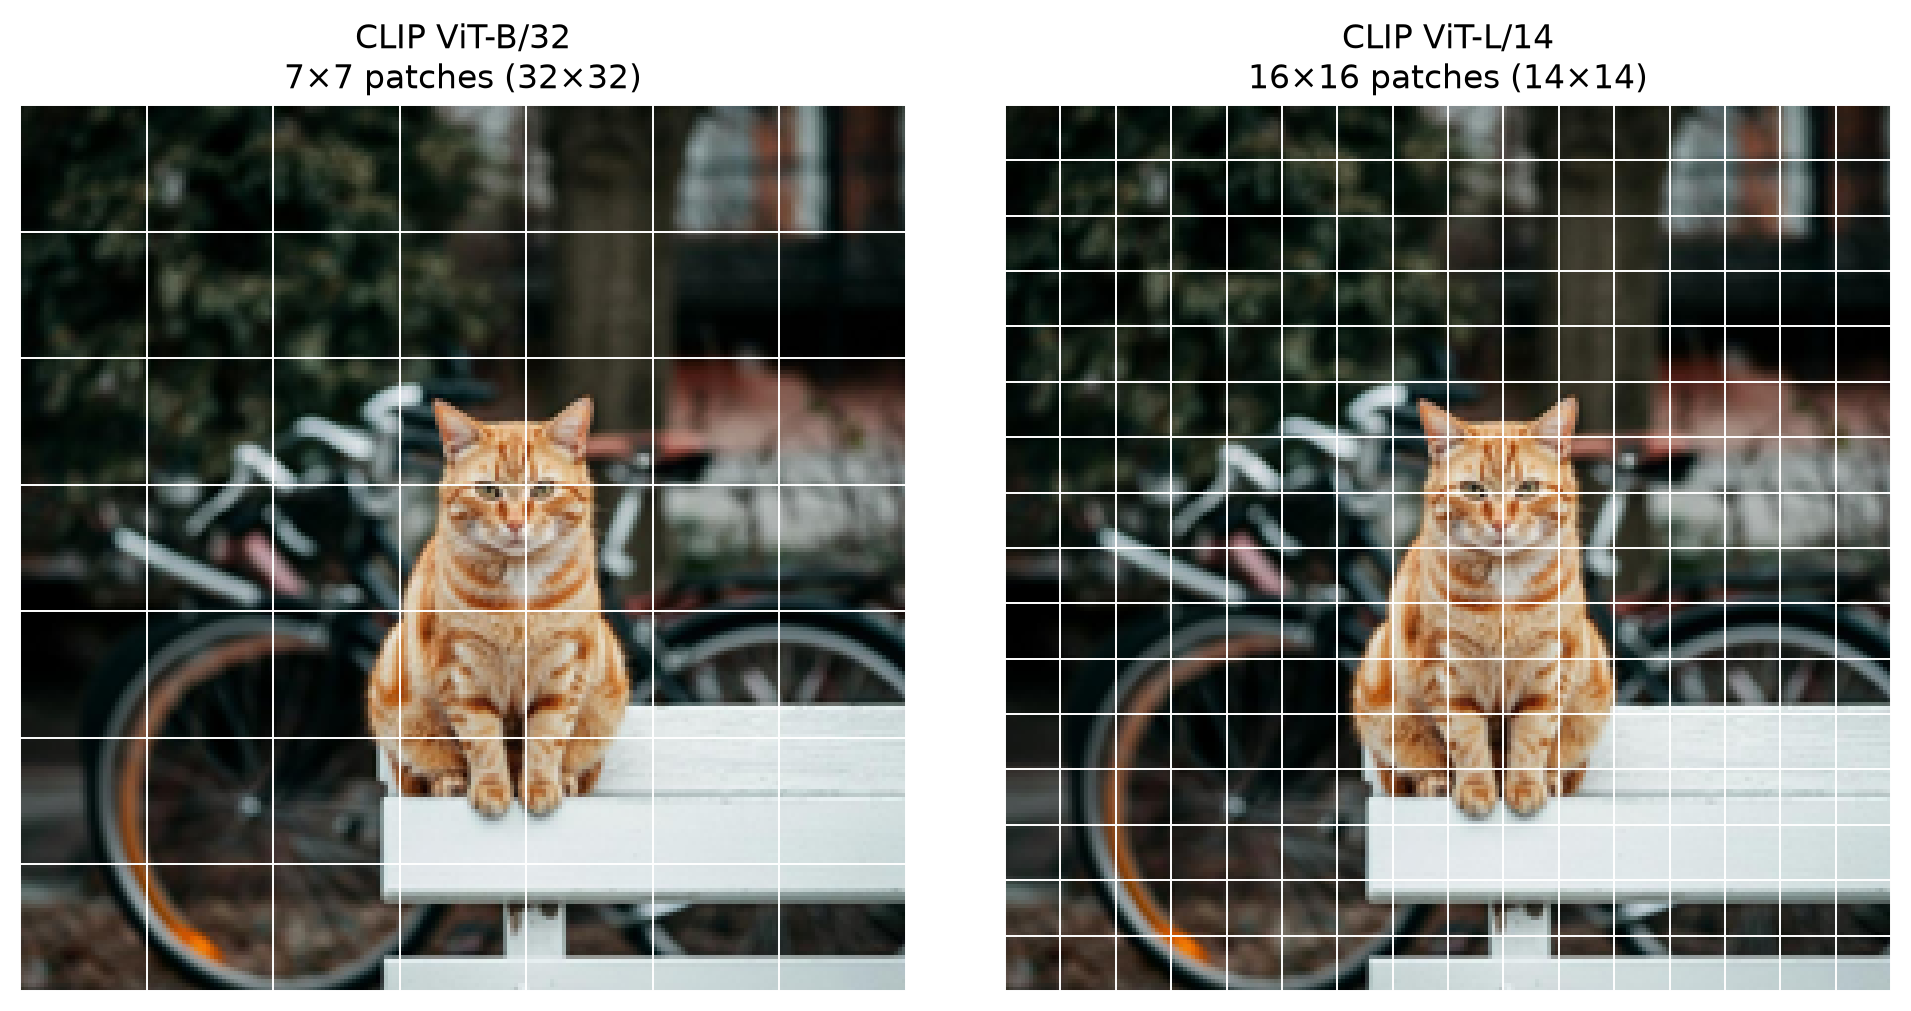

In [32]:
row = train.iloc[7]

# приведем изображение к квадратному входу модели: 
# resize с сохранением пропорций + center crop
image_size = 224
image_raw = decode_image(row['image_1'])
img = ImageOps.fit(image_raw, (image_size, image_size), method=Image.Resampling.BICUBIC)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

draw_patch_grid(axes[0], img, patch_size=32, title="CLIP ViT-B/32")
draw_patch_grid(axes[1], img, patch_size=14, title="CLIP ViT-L/14")

plt.tight_layout()
plt.show()


---

### Encoder setup

In [33]:
CLIP_BASE_MODEL_NAME = 'openai/clip-vit-base-patch32'
CLIP_BASE_NAME = 'clip-vit-base'

In [34]:
clip_base_encoder = CLIPModel.from_pretrained(CLIP_BASE_MODEL_NAME).to(DEVICE)
clip_base_processor = CLIPProcessor.from_pretrained(CLIP_BASE_MODEL_NAME)
clip_base_encoder.eval();

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 42778.18it/s]


In [35]:
# параметры processor и vision encoder

print(f'=== {CLIP_BASE_MODEL_NAME} ===\n')

ip = clip_base_processor.image_processor
vm = clip_base_encoder.vision_model
vp = clip_base_encoder.visual_projection

print(f'image processor type: {ip.to_dict()["image_processor_type"]}')
print(f'size:                 {ip.crop_size["height"]} × {ip.crop_size["width"]}; '
      f'center_crop=({ip.do_center_crop})\n')

print(f'patch embedding:      {vm.embeddings.patch_embedding}')
print(f'ViT tokens:           ({vm.embeddings.position_embedding.num_embeddings - 1} '
      f'patches + 1 CLS token) × {vm.embeddings.position_embedding.embedding_dim}')

layer = vm.encoder.layers[0]
mlp = layer.mlp

print(f'transformer blocks:   {len(vm.encoder.layers)} × '
      f'[{layer.self_attn.num_heads}-head attention | '
      f'MLP {mlp.fc1.in_features} → {mlp.fc1.out_features} → {mlp.fc2.out_features} | '
      f'{type(mlp.activation_fn).__name__}]')

print(f'visual projection:    {vp.__class__.__name__}({vp.in_features} → {vp.out_features})')

=== openai/clip-vit-base-patch32 ===

image processor type: CLIPImageProcessor
size:                 224 × 224; center_crop=(True)

patch embedding:      Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
ViT tokens:           (49 patches + 1 CLS token) × 768
transformer blocks:   12 × [12-head attention | MLP 768 → 3072 → 768 | QuickGELUActivation]
visual projection:    Linear(768 → 512)


<br>

Сначала процессор **CLIP ViT-B/32** разбивает изображение на непересекающиеся патчи 32×32. Для входа 224×224 получается сетка 7×7, то есть 49 patch токенов. Вместе со специальным class token модель получает 50 токенов размерности 768. Затем эти токены проходят через 12 transformer layers. В каждом слое есть self-attention, который смешивает информацию между патчами, и MLP-блок, который отдельно преобразует каждый token. После transformer encoder итоговое представление изображения используется как image embedding.  

---

### Embeddings

In [36]:
# функция получает image embeddings из предобученной CLIP-модели

def extract_clip_embeddings(image_bytes_list, clip_base_encoder, clip_base_processor, batch_size=32):
    embeddings = []

    for start in tqdm(range(0, len(image_bytes_list), batch_size)):
        batch_bytes = image_bytes_list[start:start + batch_size]
        images = [decode_image(image_bytes) for image_bytes in batch_bytes]
        inputs = clip_base_processor(images=images, return_tensors='pt').to(DEVICE)

        with torch.no_grad():
            batch_embeddings = clip_base_encoder.get_image_features(**inputs)
            batch_embeddings = batch_embeddings / batch_embeddings.norm(dim=1, keepdim=True)

        embeddings.append(batch_embeddings.cpu().numpy())

    return np.vstack(embeddings)


In [37]:
# функция расчета CLIP Base embeddings

def extract_clip_base_embeddings(images):
    return extract_clip_embeddings(
        images,
        clip_base_encoder,
        clip_base_processor,
        batch_size=32
    )

In [38]:
# embeddings для train image_1/image_2
clip_base_train_emb = {}

for image_name, suffix in [('image_1', 'emb_1'), ('image_2', 'emb_2')]:
    clip_base_train_emb[image_name] = get_cached_embeddings(
        ARTEFACTS_DIR / f'{CLIP_BASE_NAME}_train_{suffix}.npy',
        train[image_name],
        extract_clip_base_embeddings
    )

# embeddings для test image_1/image_2
clip_base_test_emb = {}

for image_name, suffix in [('image_1', 'emb_1'), ('image_2', 'emb_2')]:
    clip_base_test_emb[image_name] = get_cached_embeddings(
        ARTEFACTS_DIR / f'{CLIP_BASE_NAME}_test_{suffix}.npy',
        test[image_name],
        extract_clip_base_embeddings
    )

loading embeddings: artefacts/clip-vit-base_train_emb_1.npy
embeddings shape: (8710, 512)
loading embeddings: artefacts/clip-vit-base_train_emb_2.npy
embeddings shape: (8710, 512)
loading embeddings: artefacts/clip-vit-base_test_emb_1.npy
embeddings shape: (4290, 512)
loading embeddings: artefacts/clip-vit-base_test_emb_2.npy
embeddings shape: (4290, 512)


---

### Pair features

Ожидаемый размер матриц после добавления pair features:

5 feature blocks * 512 = **2560**

In [39]:
# формируем матрицы для обучения CatBoost

X_clip_base = pair_embedding_features(
    clip_base_train_emb['image_1'],
    clip_base_train_emb['image_2']
)

X_clip_base_test = pair_embedding_features(
    clip_base_test_emb['image_1'],
    clip_base_test_emb['image_2']
)

print(f'X_clip_base shape:      {X_clip_base.shape}')
print(f'X_clip_base_test shape: {X_clip_base_test.shape}')
print(f'\ntarget shape: {target.shape}')


X_clip_base shape:      (8710, 2560)
X_clip_base_test shape: (4290, 2560)

target shape: (8710,)


---

### Тестовое обучение CatBoost по одному сплиту 

In [40]:
# подберем параметры по небольшой сетке на одном сплите
param_grid = [
    {'iterations': 1000, 'depth': 4, 'l2_leaf_reg': 3},
    {'iterations': 1000, 'depth': 5, 'l2_leaf_reg': 3},
    {'iterations': 1000, 'depth': 6, 'l2_leaf_reg': 3},

    {'iterations': 1000, 'depth': 4, 'l2_leaf_reg': 5},
    {'iterations': 1000, 'depth': 5, 'l2_leaf_reg': 5},
    {'iterations': 1000, 'depth': 6, 'l2_leaf_reg': 5},

    {'iterations': 1000, 'depth': 4, 'l2_leaf_reg': 10},
    {'iterations': 1000, 'depth': 5, 'l2_leaf_reg': 10},
    {'iterations': 1000, 'depth': 6, 'l2_leaf_reg': 10},
]

X_base_split_train, X_base_split_valid, target_split_train, target_split_valid = train_test_split(
    X_clip_base,
    target,
    test_size=0.2,
    random_state=SEED,
    stratify=target
)

results = []
best_auc = -np.inf
clip_base_best_split_model = None

for params in param_grid:
    model = CatBoostClassifier(
        **params,
        loss_function='Logloss',
        eval_metric='AUC',
        random_seed=SEED,
        verbose=False
    )

    model.fit(
        X_base_split_train,
        target_split_train,
        eval_set=(X_base_split_valid, target_split_valid),
        use_best_model=True,
        early_stopping_rounds=50
    )

    valid_pred = model.predict_proba(X_base_split_valid)[:, 1]
    auc = roc_auc_score(target_split_valid, valid_pred)

    results.append({
        **params,
        'best_iteration': model.get_best_iteration(),
        'roc_auc': auc
    })

    # сохраняем лучшую модель для get_feature_importance
    if auc > best_auc:
        best_auc = auc
        clip_base_best_split_model = model    

    print(f'Params: {params}, AUC: {auc:.6f}')

print()
results_df = pd.DataFrame(results).sort_values('roc_auc', ascending=False)
results_df


Params: {'iterations': 1000, 'depth': 4, 'l2_leaf_reg': 3}, AUC: 0.647125
Params: {'iterations': 1000, 'depth': 5, 'l2_leaf_reg': 3}, AUC: 0.651304
Params: {'iterations': 1000, 'depth': 6, 'l2_leaf_reg': 3}, AUC: 0.644249
Params: {'iterations': 1000, 'depth': 4, 'l2_leaf_reg': 5}, AUC: 0.637016
Params: {'iterations': 1000, 'depth': 5, 'l2_leaf_reg': 5}, AUC: 0.636896
Params: {'iterations': 1000, 'depth': 6, 'l2_leaf_reg': 5}, AUC: 0.642188
Params: {'iterations': 1000, 'depth': 4, 'l2_leaf_reg': 10}, AUC: 0.649250
Params: {'iterations': 1000, 'depth': 5, 'l2_leaf_reg': 10}, AUC: 0.640861
Params: {'iterations': 1000, 'depth': 6, 'l2_leaf_reg': 10}, AUC: 0.656041



,iterations,depth,l2_leaf_reg,best_iteration,roc_auc
8,1000,6,10,474,0.656041
1,1000,5,3,147,0.651304
6,1000,4,10,304,0.649250
0,1000,4,3,409,0.647125
2,1000,6,3,362,0.644249
5,1000,6,5,229,0.642188
7,1000,5,10,215,0.640861
3,1000,4,5,199,0.637016
4,1000,5,5,116,0.636896


In [41]:
best_params = results_df.iloc[0][['iterations', 'depth', 'l2_leaf_reg']].to_dict()
best_params['iterations'] = int(best_params['iterations'])
best_params['depth'] = int(best_params['depth'])

print(f"Best parameters: {best_params}")


Best parameters: {'iterations': 1000, 'depth': 6, 'l2_leaf_reg': 10.0}


Посмотрим feature importance тестовой модели, обученной на одном split.\
На CV значения могут немного отличаться.

In [42]:
clip_base_importance = pd.DataFrame({
    'feature': X_clip_base.columns,
    'importance': clip_base_best_split_model.get_feature_importance()
}).sort_values('importance', ascending=False)

# важность по группам фич
clip_base_importance['feature_group'] = clip_base_importance['feature'].str.extract(
    r'^(image_1_emb|image_2_emb|diff_emb|abs_diff_emb|mul_emb)'
)

clip_base_group_importance = (
    clip_base_importance
    .groupby('feature_group', as_index=False)['importance']
    .sum()
    .sort_values('importance', ascending=False)
)

clip_base_group_importance.style.background_gradient('Blues', subset='importance')


,feature_group,importance
1,diff_emb,23.532466
3,image_2_emb,22.438505
2,image_1_emb,18.689702
4,mul_emb,17.870148
0,abs_diff_emb,17.469178


Модель больше всего использует признаки различия между картинками:
- diff_emb – в какую сторону отличается первая картинка от второй;
- abs_diff_emb – насколько сильно картинки отличаются по CLIP-координатам, без учета направления;
- image_1_emb и image_2_emb – сами эмбеддинги картинок по отдельности;
- mul_emb – похожесть/взаимодействие координат.

Парные признаки немного полезнее, чем просто эмбеддинги каждой картинки отдельно, но в целом распределение довольно равномерное.

---

### CatBoost Classifier · <small>CLIP ViT Base embeddings</small>

In [43]:
cb_clip_base_params = {
    'iterations': 1000, 
    'depth': 6, 
    'l2_leaf_reg': 10
    } 


In [44]:
print(f'=== CatBoost seed ensemble | {CLIP_BASE_NAME} ===')

clip_base_catboost_oof_path = ARTEFACTS_DIR / f'{CLIP_BASE_NAME}_catboost_oof_pred.npy'
clip_base_catboost_test_path = ARTEFACTS_DIR / f'{CLIP_BASE_NAME}_catboost_test_pred.npy'

# если артефакты существуют и CB_RETRAIN = False: загружаем артефакты
if clip_base_catboost_oof_path.exists() and clip_base_catboost_test_path.exists() and not CB_RETRAIN:
    clip_base_oof_pred = np.load(clip_base_catboost_oof_path)
    clip_base_test_pred = np.load(clip_base_catboost_test_path)

    print()
    print(f'oof loaded:  {clip_base_catboost_oof_path}; shape={clip_base_oof_pred.shape}')
    print(f'test loaded: {clip_base_catboost_test_path}; shape={clip_base_test_pred.shape}')

# иначе - переобучение CatBoost seed ensemble
else:
    print()
    print(f'params={cb_clip_base_params}')
    print(f'split seed: {SEED}; model seeds={seeds_11}\n')

    clip_base_catboost_seed_oof_preds = []
    clip_base_catboost_seed_test_preds = []

    # cv обучение для каждого сида
    for model_seed in seeds_11:
        print(f'seed={model_seed}')

        seed_oof_pred, seed_test_pred, seed_cv_auc = run_catboost_cv(
            X_clip_base,
            X_clip_base_test,
            target,
            params=cb_clip_base_params,
            seed=model_seed,
            split_seed=SEED,
            early_stopping_rounds=100
        )

        print(f'CV ROC AUC: {seed_cv_auc:.6f}\n')

        clip_base_catboost_seed_oof_preds.append(seed_oof_pred)
        clip_base_catboost_seed_test_preds.append(seed_test_pred)

    # усредняем предсказания по seeds
    clip_base_oof_pred = np.mean(clip_base_catboost_seed_oof_preds, axis=0)
    clip_base_test_pred = np.mean(clip_base_catboost_seed_test_preds, axis=0)

    # сохранение артефактов
    np.save(clip_base_catboost_oof_path, clip_base_oof_pred)
    np.save(clip_base_catboost_test_path, clip_base_test_pred)

    print(f'saved oof predictions:  {clip_base_catboost_oof_path}; shape={clip_base_oof_pred.shape}')
    print(f'saved test predictions: {clip_base_catboost_test_path}; shape={clip_base_test_pred.shape}')

clip_base_cv_auc = roc_auc_score(target, clip_base_oof_pred)

print(f'CV ROC AUC: {clip_base_cv_auc:.6f}')


=== CatBoost seed ensemble | clip-vit-base ===

oof loaded:  artefacts/clip-vit-base_catboost_oof_pred.npy; shape=(8710,)
test loaded: artefacts/clip-vit-base_catboost_test_pred.npy; shape=(4290,)
CV ROC AUC: 0.658693


<div style="font-size:14px; font-weight:700; margin:0 0 6px 0;">Model training log</div>

<pre style="
  background:#fcfcfc; border:1px solid #d1d5db; border-radius:6px; padding:12px 14px;
  font-size:11px; line-height:1.45; overflow-x:auto; white-space:pre; text-align:left;
  display:block; width:99%; max-width:100%; box-sizing:border-box; margin:0 0 16px 0;
">=== CatBoost seed ensemble | clip-vit-base ===

params={'iterations': 1000, 'depth': 6, 'l2_leaf_reg': 10}
split seed: 42; model seeds=[42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52]

seed=42 | folds=[0.646029 0.659363 0.647454 0.657445 0.641993] | best_iter=[316 331 365 334 311] | CV AUC=0.650220
seed=43 | folds=[0.646157 0.654047 0.649567 0.634390 0.651659] | best_iter=[345 556 993 110 380] | CV AUC=0.644270
seed=44 | folds=[0.633288 0.654120 0.639213 0.653838 0.652882] | best_iter=[058 331 172 586 626] | CV AUC=0.638744
seed=45 | folds=[0.645544 0.652654 0.654350 0.643621 0.647380] | best_iter=[153 311 510 137 700] | CV AUC=0.645587
seed=46 | folds=[0.644257 0.659913 0.651781 0.647024 0.652044] | best_iter=[147 361 345 445 486] | CV AUC=0.648468
seed=47 | folds=[0.646873 0.648081 0.641801 0.651058 0.651713] | best_iter=[139 354 199 460 518] | CV AUC=0.644891
seed=48 | folds=[0.648101 0.659244 0.645378 0.663887 0.653741] | best_iter=[427 502 567 755 401] | CV AUC=0.653713
seed=49 | folds=[0.649165 0.654617 0.643776 0.636109 0.648842] | best_iter=[469 388 242 147 743] | CV AUC=0.644342
seed=50 | folds=[0.640745 0.653412 0.640833 0.651601 0.642546] | best_iter=[119 236 399 192 282] | CV AUC=0.643793
seed=51 | folds=[0.646272 0.644835 0.644799 0.659106 0.651263] | best_iter=[405 123 818 335 431] | CV AUC=0.644242
seed=52 | folds=[0.646179 0.649084 0.646830 0.651125 0.656842] | best_iter=[392 202 357 337 506] | CV AUC=0.648695

seed ensemble OOF ROC AUC=0.658693</pre>

In [45]:
# добавляем метрики в датафрейм

model_scores_df = update_model_score(
    model_scores_df,
    encoder='CLIP ViT Base',
    model='CatBoost',
    n_seeds=len(seeds_11),
    oof_roc_auc=clip_base_cv_auc
)
model_scores_df


,encoder,model,n_seeds,oof_roc_auc
0,CLIP ViT Base,CatBoost,11,0.658693


---

### Siamese comparator · <small>CLIP ViT Base embeddings</small>

Siamese-модель получает два image embedding. Сначала оба эмбеддинга проходят через одну и ту же общую tower-ветку, затем объединяются в единый вектор признаков пары и передаются в MLP head, которая вычисляет вероятность победы image_1.

<table style="width:auto; table-layout:auto; border-collapse:collapse; font-size:13px; line-height:1.45; margin:12px auto 18px 0;">
  <thead>
    <tr>
      <th style="background:#f3f4f6; color:#111827; text-align:left; font-weight:600; border:1px solid #e0e0e0; padding:8px 10px;">1 | Shared tower</th>
      <th style="background:#f3f4f6; color:#111827; text-align:left; font-weight:600; border:1px solid #e0e0e0; padding:8px 10px;">2 | Pair features</th>
      <th style="background:#f3f4f6; color:#111827; text-align:left; font-weight:600; border:1px solid #e0e0e0; padding:8px 10px;">3 | MLP head</th>
      <th style="background:#f3f4f6; color:#111827; text-align:left; font-weight:600; border:1px solid #e0e0e0; padding:8px 10px;">4 | Inference</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="border:1px solid #e0e0e0; padding:0 10px; vertical-align:top;">
        <p style="margin:12px 0;">Input:<br>
          <span style="display:inline-flex; align-items:stretch; background:#ffffff; color:#374151; border-radius:4px; font-size:13px; border:1px solid #365489; margin:2px 3px; overflow:hidden;"><span style="padding:1px 6px;">emb_1</span><span style="padding:1px 5px; border-left:1px solid #365489; background:#f3f6fb; color:#365489; font-weight:600;">512</span></span>
          <span style="display:inline-flex; align-items:stretch; background:#ffffff; color:#374151; border-radius:4px; font-size:13px; border:1px solid #365489; margin:2px 3px; overflow:hidden;"><span style="padding:1px 6px;">emb_2</span><span style="padding:1px 5px; border-left:1px solid #365489; background:#f3f6fb; color:#365489; font-weight:600;">512</span></span>
        </p>
        <p style="font-size:12px; color:#6b7280; line-height:1.3em; margin:8px 0;">
          same self.tower:<br>
          Linear 512 → 256<br>
          ReLU | Dropout(0.25)
        </p>
        <p style="margin:12px 0;">Output:<br>
          z1=<span style="display:inline-flex; align-items:stretch; background:#ffffff; color:#374151; border-radius:4px; font-size:13px; border:1px solid #365489; margin:2px 3px; overflow:hidden;"><span style="padding:1px 6px;">tower(emb_1)</span><span style="padding:1px 5px; border-left:1px solid #365489; background:#f3f6fb; color:#365489; font-weight:600;">256</span></span><br>
          z2=<span style="display:inline-flex; align-items:stretch; background:#ffffff; color:#374151; border-radius:4px; font-size:13px; border:1px solid #365489; margin:2px 3px; overflow:hidden;"><span style="padding:1px 6px;">tower(emb_2)</span><span style="padding:1px 5px; border-left:1px solid #365489; background:#f3f6fb; color:#365489; font-weight:600;">256</span></span>
        </p>
      </td>
      <td style="border:1px solid #e0e0e0; padding:0 10px; vertical-align:top;">
        <p style="margin:12px 0;">Input:<br>
          <span style="display:inline-flex; align-items:stretch; background:#ffffff; color:#374151; border-radius:4px; font-size:13px; border:1px solid #365489; margin:2px 3px; overflow:hidden;"><span style="padding:1px 6px;">z1</span><span style="padding:1px 5px; border-left:1px solid #365489; background:#f3f6fb; color:#365489; font-weight:600;">256</span></span>
          <span style="display:inline-flex; align-items:stretch; background:#ffffff; color:#374151; border-radius:4px; font-size:13px; border:1px solid #365489; margin:2px 3px; overflow:hidden;"><span style="padding:1px 6px;">z2</span><span style="padding:1px 5px; border-left:1px solid #365489; background:#f3f6fb; color:#365489; font-weight:600;">256</span></span>
        </p>
        <p style="font-size:12px; color:#6b7280; line-height:1.3em; margin:8px 0;">
          torch.cat:<br>
          <b>256</b>: z1<br>
          <b>256</b>: z2<br>
          <b>256</b>: z1 - z2<br>
          <b>256</b>: |z1 - z2|
        </p>
        <p style="margin:12px 0;">Output:<br>
          <span style="display:inline-flex; align-items:stretch; background:#ffffff; color:#374151; border-radius:4px; font-size:13px; border:1px solid #365489; margin:2px 3px; overflow:hidden;"><span style="padding:1px 6px;">pair vector</span><span style="padding:1px 5px; border-left:1px solid #365489; background:#f3f6fb; color:#365489; font-weight:600;">1024</span></span>
        </p>
      </td>
      <td style="border:1px solid #e0e0e0; padding:0 10px; vertical-align:top;">
        <p style="margin:12px 0;">Input:<br>
          <span style="display:inline-flex; align-items:stretch; background:#ffffff; color:#374151; border-radius:4px; font-size:13px; border:1px solid #365489; margin:2px 3px; overflow:hidden;"><span style="padding:1px 6px;">pair vector</span><span style="padding:1px 5px; border-left:1px solid #365489; background:#f3f6fb; color:#365489; font-weight:600;">1024</span></span>
        </p>
        <p style="font-size:12px; color:#6b7280; line-height:1.3em; margin:8px 0;"><span style="display:inline-flex; background:#f0f1f4; padding:1px 5px; border-radius:4px;">1</span> Linear 1024 → 256<br>ReLU | Dropout(0.25)</p>
        <p style="font-size:12px; color:#6b7280; line-height:1.3em; margin:8px 0;"><span style="display:inline-flex; background:#f0f1f4; padding:1px 5px; border-radius:4px;">2</span> Linear 256 → 64<br>ReLU | Dropout(0.25)</p>
        <p style="font-size:12px; color:#6b7280; line-height:1.3em; margin:8px 0;"><span style="display:inline-flex; background:#f0f1f4; padding:1px 5px; border-radius:4px;">3</span> Linear 64 → 1</p>
        <p style="margin:12px 0;">Output:
          <span style="display:inline-flex; align-items:stretch; background:#ffffff; color:#374151; border-radius:4px; font-size:13px; border:1px solid #365489; margin:2px 3px; overflow:hidden;"><span style="padding:1px 6px;">logit</span><span style="padding:1px 5px; border-left:1px solid #365489; background:#f3f6fb; color:#365489; font-weight:600;">1</span></span>
        </p>
      </td>
      <td style="border:1px solid #e0e0e0; padding:0 10px; vertical-align:top;">
        <p style="margin:12px 0;">Input:<br>
          <span style="display:inline-flex; align-items:stretch; background:#ffffff; color:#374151; border-radius:4px; font-size:13px; border:1px solid #365489; margin:2px 3px; overflow:hidden;"><span style="padding:1px 6px;">logit</span><span style="padding:1px 5px; border-left:1px solid #365489; background:#f3f6fb; color:#365489; font-weight:600;">1</span></span>
        </p>
        <p style="font-size:12px; color:#6b7280; line-height:1.3em; margin:8px 0;">sigmoid(logit)</p>
        <p style="margin:12px 0;">Output:<br>
          <span style="display:inline-flex; align-items:stretch; background:#ffffff; color:#374151; border-radius:4px; font-size:13px; border:1px solid #365489; margin:2px 3px; overflow:hidden;"><span style="padding:1px 6px;">score image_1</span><span style="padding:1px 5px; border-left:1px solid #365489; background:#f3f6fb; color:#365489; font-weight:600;">1</span></span>
        </p>
      </td>
    </tr>
  </tbody>
</table>

In [46]:
# параметры siamese comparator

clip_base_siamese_model_params = {
    'tower_dims': (256,),
    'head_dims': (256, 64),
    'dropout': 0.25,
}

clip_base_siamese_train_params = {
    'augment_swap': False,
    'lr': 7e-4,
    'weight_decay': 1e-4,
    'batch_size': 256,
    'epochs': 25,
    'patience': 5,
}

In [47]:
SIAMESE_RETRAIN = True

print(f'=== Siamese | {CLIP_BASE_NAME} ===')

clip_base_siamese_oof_path = ARTEFACTS_DIR / f'{CLIP_BASE_NAME}_siamese_oof_pred.npy'
clip_base_siamese_test_path = ARTEFACTS_DIR / f'{CLIP_BASE_NAME}_siamese_test_pred.npy'

# если артефакты существуют и SIAMESE_RETRAIN = False: загружаем артефакты
if clip_base_siamese_oof_path.exists() and clip_base_siamese_test_path.exists() and not SIAMESE_RETRAIN:
    clip_base_siamese_oof_pred = np.load(clip_base_siamese_oof_path)
    clip_base_siamese_test_pred = np.load(clip_base_siamese_test_path)
    print()
    print(f'oof loaded:  {clip_base_siamese_oof_path};  shape={clip_base_siamese_oof_pred.shape}')
    print(f'test loaded: {clip_base_siamese_test_path}; shape={clip_base_siamese_test_pred.shape}')

# иначе - переобучение Siamese seed ensemble
else:
    print(f'model params={clip_base_siamese_model_params}')
    print(f'train params={clip_base_siamese_train_params}')
    print(f'model seeds={seeds_11}; split seed: {SEED}\n')

    clip_base_siamese_seed_oof_preds = []
    clip_base_siamese_seed_test_preds = []
    verbose = True

    # cv обучение для каждого сида
    for model_seed in seeds_11:
        seed_oof_pred, seed_test_pred, seed_fold_scores, seed_best_epochs, seed_cv_auc = run_siamese_cv(
            train_emb=clip_base_train_emb,
            test_emb=clip_base_test_emb,
            target=target,
            params={
                **clip_base_siamese_model_params,
                **clip_base_siamese_train_params,
            },
            split_seed=SEED,
            verbose=verbose,
            model_seed=model_seed
        )

        if not verbose:
            print(
                f'seed={model_seed} | '
                f'fold scores=[{" ".join(f"{score:.6f}" for score in seed_fold_scores)}] | '
                f'best epochs=[{" ".join(f"{epoch:02d}" for epoch in seed_best_epochs)}] | '
                f'CV ROC AUC: {seed_cv_auc:.6f}'
            )

        clip_base_siamese_seed_oof_preds.append(seed_oof_pred)
        clip_base_siamese_seed_test_preds.append(seed_test_pred)

    clip_base_siamese_oof_pred = np.mean(clip_base_siamese_seed_oof_preds, axis=0)
    clip_base_siamese_test_pred = np.mean(clip_base_siamese_seed_test_preds, axis=0)

    np.save(clip_base_siamese_oof_path, clip_base_siamese_oof_pred)
    np.save(clip_base_siamese_test_path, clip_base_siamese_test_pred)

    print(f'\nsaved oof predictions:  {clip_base_siamese_oof_path}; shape={clip_base_siamese_oof_pred.shape}')
    print(f'saved test predictions: {clip_base_siamese_test_path}; shape={clip_base_siamese_test_pred.shape}')

clip_base_siamese_cv_auc = roc_auc_score(target, clip_base_siamese_oof_pred)
print(f'seed ensemble OOF ROC AUC: {clip_base_siamese_cv_auc:.6f}')

SIAMESE_RETRAIN = False

=== Siamese | clip-vit-base ===
model params={'tower_dims': (256,), 'head_dims': (256, 64), 'dropout': 0.25}
train params={'augment_swap': False, 'lr': 0.0007, 'weight_decay': 0.0001, 'batch_size': 256, 'epochs': 25, 'patience': 5}
model seeds=[42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52]; split seed: 42

seed=42 | folds=[0.652634 0.653521 0.645209 0.668967 0.654989] epochs=[09 06 12 08 07] CV AUC=0.650378
seed=43 | folds=[0.655501 0.648011 0.637941 0.668372 0.661767] epochs=[06 05 09 08 08] CV AUC=0.651962
seed=44 | folds=[0.653057 0.650587 0.640567 0.666303 0.651775] epochs=[07 08 08 08 06] CV AUC=0.648855
seed=45 | folds=[0.655278 0.650184 0.644080 0.668374 0.654983] epochs=[09 06 08 07 08] CV AUC=0.651241
seed=46 | folds=[0.654714 0.642423 0.645416 0.671388 0.651585] epochs=[07 05 12 07 08] CV AUC=0.648421
seed=47 | folds=[0.650702 0.650034 0.646999 0.668109 0.656524] epochs=[06 06 08 08 08] CV AUC=0.652581
seed=48 | folds=[0.653964 0.650149 0.642259 0.670162 0.656675] epochs=[07 06

In [48]:
model_scores_df = update_model_score(
    model_scores_df,
    encoder='CLIP ViT Base',
    model='Siamese',
    n_seeds=len(seeds_11),
    oof_roc_auc=clip_base_siamese_cv_auc
)
model_scores_df


,encoder,model,n_seeds,oof_roc_auc
0,CLIP ViT Base,CatBoost,11,0.658693
1,CLIP ViT Base,Siamese,11,0.65845


**Augment swap check**:

<pre style="
  background:transparent;
  border:0;
  padding:0;
  margin:0 0 16px;
  font-size:12px;
  line-height:1.45;
">
<b>
model                           | augment_swap | CV ROC AUC</b>
CLIP Base Siamese seed ensemble | True         | 0.655096
CLIP Base Siamese seed ensemble | False        | 0.658450</pre>

  <code>augment_swap=False</code> оказался лучше, поэтому дальше Siamese-модели обучаются без зеркальных пар.

---

### CatBoost + Siamese blend

Проверяем, дополняет ли Siamese comparator CatBoost на тех же CLIP-эмбеддингах. Вес подбирается по OOF-предсказаниям.


In [49]:
# подбираем веса catboost/siamese blend по oof
catboost_oof_pred = np.load(ARTEFACTS_DIR / f'{CLIP_BASE_NAME}_catboost_oof_pred.npy')
catboost_test_pred = np.load(ARTEFACTS_DIR / f'{CLIP_BASE_NAME}_catboost_test_pred.npy')

clip_base_siamese_oof_pred = np.load(ARTEFACTS_DIR / f'{CLIP_BASE_NAME}_siamese_oof_pred.npy')
clip_base_siamese_test_pred = np.load(ARTEFACTS_DIR / f'{CLIP_BASE_NAME}_siamese_test_pred.npy')

blend_results = []

for catboost_weight in np.arange(0, 1.01, 0.01):
    siamese_weight = 1 - catboost_weight
    blend_oof_pred = catboost_weight * catboost_oof_pred + siamese_weight * clip_base_siamese_oof_pred
    blend_auc = roc_auc_score(target, blend_oof_pred)

    blend_results.append({
        'catboost_weight': catboost_weight,
        'siamese_weight': siamese_weight,
        'roc_auc': blend_auc
    })

blend_results = pd.DataFrame(blend_results).sort_values('roc_auc', ascending=False)
blend_results.head(10).style.background_gradient('Blues', subset='roc_auc')


,catboost_weight,siamese_weight,roc_auc
68,0.680000,0.320000,0.665062
67,0.670000,0.330000,0.665048
69,0.690000,0.310000,0.665041
70,0.700000,0.300000,0.665040
71,0.710000,0.290000,0.665036
66,0.660000,0.340000,0.665018
72,0.720000,0.280000,0.665013
65,0.650000,0.350000,0.664985
73,0.730000,0.270000,0.664980
64,0.640000,0.360000,0.664951


In [50]:
best_blend = blend_results.iloc[0]

catboost_weight = best_blend['catboost_weight']
siamese_weight = best_blend['siamese_weight']

blend_oof_pred = catboost_weight * catboost_oof_pred + siamese_weight * clip_base_siamese_oof_pred
blend_test_pred = catboost_weight * catboost_test_pred + siamese_weight * clip_base_siamese_test_pred

print(f'CLIP ViT-B/32 CatBoost ROC AUC: {roc_auc_score(target, catboost_oof_pred):.6f}; '
      f'weight: {catboost_weight:.2f}; ')
print(f'CLIP ViT-B/32 Siamese  ROC AUC: {roc_auc_score(target, clip_base_siamese_oof_pred):.6f}; '
      f'weight: {siamese_weight:.2f}; ')
print(f'Blend OOF preds        ROC AUC: {roc_auc_score(target, blend_oof_pred):.6f}')


CLIP ViT-B/32 CatBoost ROC AUC: 0.658693; weight: 0.68; 
CLIP ViT-B/32 Siamese  ROC AUC: 0.658450; weight: 0.32; 
Blend OOF preds        ROC AUC: 0.665062


Итоговый blend по ROC AUC заметно выше обеих отдельных моделей, CatBoost и Siamese хорошо дополняют друг друга. Лучший бленд дал больший вес предсказаниям CatBoost (68%).

<div style="
    background: #f3f4f6;
    border-radius: 6px;
    margin-top:20px;
    height: 30px;
"></div>

## CLIP ViT Large

**Encoder:** `openai/clip-vit-large-patch14`  
**Source:** Hugging Face / transformers  
**Backbone:** ViT-L/14  
**Input size:** 224×224  
**Patch size:** 14×14  
**Models:** CatBoost, Siamese comparator

Вторая CLIP-ветка использует более крупный encoder и более мелкие патчи: 14×14 вместо 32×32, поэтому при входном разрешении 224×224 модель получает 256 визуальных токенов вместо 49. Это помогает сохранить больше информации о мелких деталях и артефактах, которые могут отличать изображения с похожим содержанием.

### Encoder setup


In [51]:
CLIP_LARGE_MODEL_NAME = 'openai/clip-vit-large-patch14'
CLIP_LARGE_NAME = 'clip-vit-large'

In [52]:
clip_large_encoder = CLIPModel.from_pretrained(CLIP_LARGE_MODEL_NAME).to(DEVICE)
clip_large_processor = CLIPProcessor.from_pretrained(CLIP_LARGE_MODEL_NAME)
clip_large_encoder.eval();

Loading weights: 100%|██████████| 590/590 [00:00<00:00, 6520.15it/s]


In [53]:
# параметры processor и vision encoder

print(f'\n=== {CLIP_LARGE_MODEL_NAME} ===\n')

ip = clip_large_processor.image_processor
vm = clip_large_encoder.vision_model
vp = clip_large_encoder.visual_projection

print(f'image processor type: {ip.to_dict()["image_processor_type"]}')
print(f'size:                 {ip.crop_size["height"]} × {ip.crop_size["width"]}; '
      f'center_crop=({ip.do_center_crop})\n')

print(f'patch embedding:      {vm.embeddings.patch_embedding}')
print(f'ViT tokens:           ({vm.embeddings.position_embedding.num_embeddings - 1} '
      f'patches + 1 CLS token) × {vm.embeddings.position_embedding.embedding_dim}')

layer = vm.encoder.layers[0]
mlp = layer.mlp

print(f'transformer blocks:   {len(vm.encoder.layers)} × '
      f'[{layer.self_attn.num_heads}-head attention | '
      f'MLP {mlp.fc1.in_features} → {mlp.fc1.out_features} → {mlp.fc2.out_features} | '
      f'{type(mlp.activation_fn).__name__}]')

print(f'visual projection:    {vp.__class__.__name__}({vp.in_features} → {vp.out_features})')


=== openai/clip-vit-large-patch14 ===

image processor type: CLIPImageProcessor
size:                 224 × 224; center_crop=(True)

patch embedding:      Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14), bias=False)
ViT tokens:           (256 patches + 1 CLS token) × 1024
transformer blocks:   24 × [16-head attention | MLP 1024 → 4096 → 1024 | QuickGELUActivation]
visual projection:    Linear(1024 → 768)


---

### Embeddings

In [54]:
# функция расчета CLIP Large embeddings

def extract_clip_large_embeddings(images):
    return extract_clip_embeddings(
        images,
        clip_large_encoder,
        clip_large_processor,
        batch_size=16
    )

In [55]:
# embeddings для train image_1/image_2
clip_large_train_emb = {}

for image_name, suffix in [('image_1', 'emb_1'), ('image_2', 'emb_2')]:
    clip_large_train_emb[image_name] = get_cached_embeddings(
        ARTEFACTS_DIR / f'{CLIP_LARGE_NAME}_train_{suffix}.npy',
        train[image_name],
        extract_clip_large_embeddings
    )

# embeddings для test image_1/image_2
clip_large_test_emb = {}

for image_name, suffix in [('image_1', 'emb_1'), ('image_2', 'emb_2')]:
    clip_large_test_emb[image_name] = get_cached_embeddings(
        ARTEFACTS_DIR / f'{CLIP_LARGE_NAME}_test_{suffix}.npy',
        test[image_name],
        extract_clip_large_embeddings
    )

loading embeddings: artefacts/clip-vit-large_train_emb_1.npy
embeddings shape: (8710, 768)
loading embeddings: artefacts/clip-vit-large_train_emb_2.npy
embeddings shape: (8710, 768)
loading embeddings: artefacts/clip-vit-large_test_emb_1.npy
embeddings shape: (4290, 768)
loading embeddings: artefacts/clip-vit-large_test_emb_2.npy
embeddings shape: (4290, 768)


---

### Pair features


Ожидаемый размер матриц после добавления pair features:

5 feature blocks * 768 = **3840**

In [56]:
# матрицы pair features для CLIP Large CatBoost

X_clip_large = pair_embedding_features(
    clip_large_train_emb['image_1'],
    clip_large_train_emb['image_2']
)

X_clip_large_test = pair_embedding_features(
    clip_large_test_emb['image_1'],
    clip_large_test_emb['image_2']
)

print(f'X_clip_large shape:      {X_clip_large.shape}')
print(f'X_clip_large_test shape: {X_clip_large_test.shape}')

print(f'\ntarget shape: {target.shape}')


X_clip_large shape:      (8710, 3840)
X_clip_large_test shape: (4290, 3840)

target shape: (8710,)


---

### CatBoost Classifier · <small>CLIP ViT Large embeddings</small>

In [57]:
cb_clip_large_params = {
    'iterations': 1000,
    'depth': 5,
    'l2_leaf_reg': 5,
    'thread_count': 1,
}

In [58]:
print(f'=== CatBoost seed ensemble | {CLIP_LARGE_NAME} ===')

clip_large_catboost_oof_path = ARTEFACTS_DIR / f'{CLIP_LARGE_NAME}_catboost_oof_pred.npy'
clip_large_catboost_test_path = ARTEFACTS_DIR / f'{CLIP_LARGE_NAME}_catboost_test_pred.npy'

# если артефакты существуют и CB_RETRAIN = False: загружаем артефакты
if clip_large_catboost_oof_path.exists() and clip_large_catboost_test_path.exists() and not CB_RETRAIN:
    clip_large_oof_pred = np.load(clip_large_catboost_oof_path)
    clip_large_test_pred = np.load(clip_large_catboost_test_path)

    print()
    print(f'oof loaded:  {clip_large_catboost_oof_path}; shape={clip_large_oof_pred.shape}')
    print(f'test loaded: {clip_large_catboost_test_path}; shape={clip_large_test_pred.shape}')

# иначе - переобучение CatBoost seed ensemble
else:
    print()
    print(f'params={cb_clip_large_params}')
    print(f'split seed: {SEED}; model seeds={seeds_11}\n')

    clip_large_catboost_seed_oof_preds = []
    clip_large_catboost_seed_test_preds = []

    # cv обучение для каждого сида
    for model_seed in seeds_11:
        print(f'seed={model_seed}')

        seed_oof_pred, seed_test_pred, seed_cv_auc = run_catboost_cv(
            X_clip_large,
            X_clip_large_test,
            target,
            cb_clip_large_params,
            seed=model_seed,
            split_seed=SEED
        )

        print(f'CV ROC AUC: {seed_cv_auc:.6f}\n')

        clip_large_catboost_seed_oof_preds.append(seed_oof_pred)
        clip_large_catboost_seed_test_preds.append(seed_test_pred)

    # усредняем предсказания по seeds
    clip_large_oof_pred = np.mean(clip_large_catboost_seed_oof_preds, axis=0)
    clip_large_test_pred = np.mean(clip_large_catboost_seed_test_preds, axis=0)

    # сохранение артефактов
    np.save(clip_large_catboost_oof_path, clip_large_oof_pred)
    np.save(clip_large_catboost_test_path, clip_large_test_pred)

    print(f'saved oof predictions:  {clip_large_catboost_oof_path}; shape={clip_large_oof_pred.shape}')
    print(f'saved test predictions: {clip_large_catboost_test_path}; shape={clip_large_test_pred.shape}')

clip_large_cv_auc = roc_auc_score(target, clip_large_oof_pred)

print(f'CV ROC AUC: {clip_large_cv_auc:.6f}')


=== CatBoost seed ensemble | clip-vit-large ===

oof loaded:  artefacts/clip-vit-large_catboost_oof_pred.npy; shape=(8710,)
test loaded: artefacts/clip-vit-large_catboost_test_pred.npy; shape=(4290,)
CV ROC AUC: 0.657851


<div style="font-size:14px; font-weight:700; margin-bottom:6px;">Model training log</div>

<pre style="
  background:#fcfcfc; border:1px solid #d1d5db; border-radius:6px; padding:12px 14px;
  font-size:11px; line-height:1.45; overflow-x:auto; white-space:pre; text-align:left;
  display:block; width:99%; max-width:100%; box-sizing:border-box; margin:0 0 16px 0;
">=== CatBoost seed ensemble | clip-vit-large ===

params={'iterations': 1000, 'depth': 5, 'l2_leaf_reg': 5, 'thread_count': 1}
split seed: 42; model seeds=[42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52]

seed=42 | folds=[0.647844 0.652407 0.651078 0.654264 0.654525] best_iter=[712 258 730 736 366] CV AUC=0.649731
seed=43 | folds=[0.650895 0.651776 0.639036 0.661168 0.652514] best_iter=[770 368 494 432 425] CV AUC=0.650443
seed=44 | folds=[0.647031 0.650395 0.647940 0.656604 0.654660] best_iter=[806 743 980 730 583] CV AUC=0.650939
seed=45 | folds=[0.651639 0.650561 0.641358 0.651106 0.656522] best_iter=[835 290 986 556 914] CV AUC=0.647938
seed=46 | folds=[0.637037 0.659955 0.642621 0.658590 0.652356] best_iter=[999 311 559 398 789] CV AUC=0.647453
seed=47 | folds=[0.642952 0.651615 0.641239 0.655261 0.650140] best_iter=[532 430 976 644 608] CV AUC=0.647351
seed=48 | folds=[0.643845 0.659766 0.637980 0.660043 0.644882] best_iter=[405 292 553 722 691] CV AUC=0.646960
seed=49 | folds=[0.652359 0.652785 0.638345 0.659154 0.650770] best_iter=[664 604 787 464 287] CV AUC=0.649142
seed=50 | folds=[0.655361 0.659366 0.635348 0.650524 0.652376] best_iter=[833 532 297 437 488] CV AUC=0.650190
seed=51 | folds=[0.650042 0.654277 0.651775 0.667607 0.650550] best_iter=[844 267 884 737 763] CV AUC=0.652576
seed=52 | folds=[0.645670 0.662486 0.644709 0.646120 0.651278] best_iter=[880 249 692 529 999] CV AUC=0.646181

saved oof predictions:  artefacts/clip-vit-large_catboost_oof_pred.npy; shape=(8710,)
saved test predictions: artefacts/clip-vit-large_catboost_test_pred.npy; shape=(4290,)

seed ensemble OOF ROC AUC: 0.657851</pre>

In [59]:
model_scores_df = update_model_score(
    model_scores_df,
    encoder='CLIP ViT Large',
    model='CatBoost',
    n_seeds=len(seeds_11),
    oof_roc_auc=clip_large_cv_auc
)
model_scores_df


,encoder,model,n_seeds,oof_roc_auc
0,CLIP ViT Base,CatBoost,11,0.658693
1,CLIP ViT Base,Siamese,11,0.65845
2,CLIP ViT Large,CatBoost,11,0.657851


---

### Siamese comparator · <small>CLIP ViT Large embeddings</small>


<table style="width:auto; table-layout:auto; border-collapse:collapse; font-size:13px; line-height:1.45; margin:12px auto 18px 0;">
  <thead>
    <tr>
      <th style="background:#f3f4f6; color:#111827; text-align:left; font-weight:600; border:1px solid #e0e0e0; padding:8px 10px;">1 | Shared tower</th>
      <th style="background:#f3f4f6; color:#111827; text-align:left; font-weight:600; border:1px solid #e0e0e0; padding:8px 10px;">2 | Pair features</th>
      <th style="background:#f3f4f6; color:#111827; text-align:left; font-weight:600; border:1px solid #e0e0e0; padding:8px 10px;">3 | MLP head</th>
      <th style="background:#f3f4f6; color:#111827; text-align:left; font-weight:600; border:1px solid #e0e0e0; padding:8px 10px;">4 | Inference</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="border:1px solid #e0e0e0; padding:0 10px; vertical-align:top;">
        <p style="margin:12px 0;">Input:<br>
          <span style="display:inline-flex; align-items:stretch; background:#ffffff; color:#374151; border-radius:4px; font-size:13px; border:1px solid #365489; margin:2px 3px; overflow:hidden;"><span style="padding:1px 6px;">emb_1</span><span style="padding:1px 5px; border-left:1px solid #365489; background:#f3f6fb; color:#365489; font-weight:600;">768</span></span>
          <span style="display:inline-flex; align-items:stretch; background:#ffffff; color:#374151; border-radius:4px; font-size:13px; border:1px solid #365489; margin:2px 3px; overflow:hidden;"><span style="padding:1px 6px;">emb_2</span><span style="padding:1px 5px; border-left:1px solid #365489; background:#f3f6fb; color:#365489; font-weight:600;">768</span></span>
        </p>
        <p style="font-size:12px; color:#6b7280; line-height:1.3em; margin:8px 0;">
          same self.tower:<br>
          Linear 768 → 256<br>
          ReLU | Dropout(0.25)
        </p>
        <p style="margin:12px 0;">Output:<br>
          z1=<span style="display:inline-flex; align-items:stretch; background:#ffffff; color:#374151; border-radius:4px; font-size:13px; border:1px solid #365489; margin:2px 3px; overflow:hidden;"><span style="padding:1px 6px;">tower(emb_1)</span><span style="padding:1px 5px; border-left:1px solid #365489; background:#f3f6fb; color:#365489; font-weight:600;">256</span></span><br>
          z2=<span style="display:inline-flex; align-items:stretch; background:#ffffff; color:#374151; border-radius:4px; font-size:13px; border:1px solid #365489; margin:2px 3px; overflow:hidden;"><span style="padding:1px 6px;">tower(emb_2)</span><span style="padding:1px 5px; border-left:1px solid #365489; background:#f3f6fb; color:#365489; font-weight:600;">256</span></span>
        </p>
      </td>
      <td style="border:1px solid #e0e0e0; padding:0 10px; vertical-align:top;">
        <p style="margin:12px 0;">Input:<br>
          <span style="display:inline-flex; align-items:stretch; background:#ffffff; color:#374151; border-radius:4px; font-size:13px; border:1px solid #365489; margin:2px 3px; overflow:hidden;"><span style="padding:1px 6px;">z1</span><span style="padding:1px 5px; border-left:1px solid #365489; background:#f3f6fb; color:#365489; font-weight:600;">256</span></span>
          <span style="display:inline-flex; align-items:stretch; background:#ffffff; color:#374151; border-radius:4px; font-size:13px; border:1px solid #365489; margin:2px 3px; overflow:hidden;"><span style="padding:1px 6px;">z2</span><span style="padding:1px 5px; border-left:1px solid #365489; background:#f3f6fb; color:#365489; font-weight:600;">256</span></span>
        </p>
        <p style="font-size:12px; color:#6b7280; line-height:1.3em; margin:8px 0;">
          torch.cat:<br>
          <b>256</b>: z1<br>
          <b>256</b>: z2<br>
          <b>256</b>: z1 - z2<br>
          <b>256</b>: |z1 - z2|
        </p>
        <p style="margin:12px 0;">Output:<br>
          <span style="display:inline-flex; align-items:stretch; background:#ffffff; color:#374151; border-radius:4px; font-size:13px; border:1px solid #365489; margin:2px 3px; overflow:hidden;"><span style="padding:1px 6px;">pair vector</span><span style="padding:1px 5px; border-left:1px solid #365489; background:#f3f6fb; color:#365489; font-weight:600;">1024</span></span>
        </p>
      </td>
      <td style="border:1px solid #e0e0e0; padding:0 10px; vertical-align:top;">
        <p style="margin:12px 0;">Input:<br>
          <span style="display:inline-flex; align-items:stretch; background:#ffffff; color:#374151; border-radius:4px; font-size:13px; border:1px solid #365489; margin:2px 3px; overflow:hidden;"><span style="padding:1px 6px;">pair vector</span><span style="padding:1px 5px; border-left:1px solid #365489; background:#f3f6fb; color:#365489; font-weight:600;">1024</span></span>
        </p>
        <p style="font-size:12px; color:#6b7280; line-height:1.3em; margin:8px 0;"><span style="display:inline-flex; background:#f0f1f4; padding:1px 5px; border-radius:4px;">1</span> Linear 1024 → 256<br>ReLU | Dropout(0.25)</p>
        <p style="font-size:12px; color:#6b7280; line-height:1.3em; margin:8px 0;"><span style="display:inline-flex; background:#f0f1f4; padding:1px 5px; border-radius:4px;">2</span> Linear 256 → 64<br>ReLU | Dropout(0.25)</p>
        <p style="font-size:12px; color:#6b7280; line-height:1.3em; margin:8px 0;"><span style="display:inline-flex; background:#f0f1f4; padding:1px 5px; border-radius:4px;">3</span> Linear 64 → 1</p>
        <p style="margin:12px 0;">Output:
          <span style="display:inline-flex; align-items:stretch; background:#ffffff; color:#374151; border-radius:4px; font-size:13px; border:1px solid #365489; margin:2px 3px; overflow:hidden;"><span style="padding:1px 6px;">logit</span><span style="padding:1px 5px; border-left:1px solid #365489; background:#f3f6fb; color:#365489; font-weight:600;">1</span></span>
        </p>
      </td>
      <td style="border:1px solid #e0e0e0; padding:0 10px; vertical-align:top;">
        <p style="margin:12px 0;">Input:<br>
          <span style="display:inline-flex; align-items:stretch; background:#ffffff; color:#374151; border-radius:4px; font-size:13px; border:1px solid #365489; margin:2px 3px; overflow:hidden;"><span style="padding:1px 6px;">logit</span><span style="padding:1px 5px; border-left:1px solid #365489; background:#f3f6fb; color:#365489; font-weight:600;">1</span></span>
        </p>
        <p style="font-size:12px; color:#6b7280; line-height:1.3em; margin:8px 0;">sigmoid(logit)</p>
        <p style="margin:12px 0;">Output:<br>
          <span style="display:inline-flex; align-items:stretch; background:#ffffff; color:#374151; border-radius:4px; font-size:13px; border:1px solid #365489; margin:2px 3px; overflow:hidden;"><span style="padding:1px 6px;">score image_1</span><span style="padding:1px 5px; border-left:1px solid #365489; background:#f3f6fb; color:#365489; font-weight:600;">1</span></span>
        </p>
      </td>
    </tr>
  </tbody>
</table>

In [60]:
clip_large_siamese_model_params = {
    'tower_dims': (256,),
    'head_dims': (256, 64),
    'dropout': 0.25,
}

clip_large_siamese_train_params = {
    'augment_swap': False,
    'lr': 7e-4,
    'weight_decay': 1e-4,
    'batch_size': 256,
    'epochs': 25,
    'patience': 5,
}


In [61]:
print(f'=== Siamese | {CLIP_LARGE_NAME} ===')

clip_large_siamese_oof_path = ARTEFACTS_DIR / f'{CLIP_LARGE_NAME}_siamese_oof_pred.npy'
clip_large_siamese_test_path = ARTEFACTS_DIR / f'{CLIP_LARGE_NAME}_siamese_test_pred.npy'

# если артефакты существуют и SIAMESE_RETRAIN = False: загружаем артефакты
if clip_large_siamese_oof_path.exists() and clip_large_siamese_test_path.exists() and not SIAMESE_RETRAIN:
    clip_large_siamese_oof_pred = np.load(clip_large_siamese_oof_path)
    clip_large_siamese_test_pred = np.load(clip_large_siamese_test_path)
    print()
    print(f'oof loaded:  {clip_large_siamese_oof_path};  shape={clip_large_siamese_oof_pred.shape}')
    print(f'test loaded: {clip_large_siamese_test_path}; shape={clip_large_siamese_test_pred.shape}')

# иначе - переобучение Siamese seed ensemble
else:
    print(f'model params={clip_large_siamese_model_params}')
    print(f'train params={clip_large_siamese_train_params}')
    print(f'split seed: {SEED}; model seeds={seeds_11}\n')

    clip_large_siamese_seed_oof_preds = []
    clip_large_siamese_seed_test_preds = []
    verbose = True

    # cv обучение для каждого сида
    for model_seed in seeds_11:
        seed_oof_pred, seed_test_pred, seed_fold_scores, seed_best_epochs, seed_cv_auc = run_siamese_cv(
            train_emb=clip_large_train_emb,
            test_emb=clip_large_test_emb,
            target=target,
            params={
                **clip_large_siamese_model_params,
                **clip_large_siamese_train_params,
            },
            split_seed=SEED,
            verbose=verbose,
            model_seed=model_seed
        )

        if not verbose:
            print(
                f'seed={model_seed} | '
                f'fold scores=[{" ".join(f"{score:.6f}" for score in seed_fold_scores)}] | '
                f'best epochs=[{" ".join(f"{epoch:02d}" for epoch in seed_best_epochs)}] | '
                f'CV ROC AUC: {seed_cv_auc:.6f}'
            )

        clip_large_siamese_seed_oof_preds.append(seed_oof_pred)
        clip_large_siamese_seed_test_preds.append(seed_test_pred)

    clip_large_siamese_oof_pred = np.mean(clip_large_siamese_seed_oof_preds, axis=0)
    clip_large_siamese_test_pred = np.mean(clip_large_siamese_seed_test_preds, axis=0)

    np.save(clip_large_siamese_oof_path, clip_large_siamese_oof_pred)
    np.save(clip_large_siamese_test_path, clip_large_siamese_test_pred)

    print(f'\nsaved oof predictions:  {clip_large_siamese_oof_path};  '
          f'shape={clip_large_siamese_oof_pred.shape}')
    print(f'saved test predictions: {clip_large_siamese_test_path}; '
          f'shape={clip_large_siamese_test_pred.shape}')

clip_large_siamese_cv_auc = roc_auc_score(target, clip_large_siamese_oof_pred)
print(f'seed ensemble OOF ROC AUC: {clip_large_siamese_cv_auc:.6f}')

=== Siamese | clip-vit-large ===

oof loaded:  artefacts/clip-vit-large_siamese_oof_pred.npy;  shape=(8710,)
test loaded: artefacts/clip-vit-large_siamese_test_pred.npy; shape=(4290,)
seed ensemble OOF ROC AUC: 0.654819


<div style="font-size:14px; font-weight:700; margin-bottom:6px;">Model training log</div>

<pre style="
  background:#fcfcfc; border:1px solid #d1d5db; border-radius:6px; padding:12px 14px;
  font-size:11px; line-height:1.45; overflow-x:auto; white-space:pre; text-align:left;
  display:block; width:99%; max-width:100%; box-sizing:border-box; margin:0 0 16px 0;
">=== Siamese | clip-vit-large ===

model params={'tower_dims': (256,), 'head_dims': (256, 64), 'dropout': 0.25}
train params={'augment_swap': False, 'lr': 0.0007, 'weight_decay': 0.0001, 'batch_size': 256, 'epochs': 25, 'patience': 5}
split seed: 42; model seeds=[42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52]

seed=42 | folds=[0.648331 0.657376 0.638559 0.668075 0.658436] | epochs=[10 04 06 07 05] | CV AUC=0.648493
seed=43 | folds=[0.645846 0.657449 0.643851 0.662691 0.664550] | epochs=[08 04 11 05 06] | CV AUC=0.644760
seed=44 | folds=[0.643142 0.665837 0.636869 0.666238 0.658364] | epochs=[08 05 05 07 07] | CV AUC=0.646065
seed=45 | folds=[0.638941 0.658935 0.639664 0.661830 0.657237] | epochs=[09 04 08 08 07] | CV AUC=0.645065
seed=46 | folds=[0.644932 0.661240 0.639413 0.662889 0.662061] | epochs=[08 05 08 05 07] | CV AUC=0.646051
seed=47 | folds=[0.649549 0.659923 0.637817 0.662323 0.659231] | epochs=[08 04 08 07 07] | CV AUC=0.647680
seed=48 | folds=[0.644298 0.662185 0.643321 0.665153 0.660040] | epochs=[08 04 12 07 05] | CV AUC=0.645424
seed=49 | folds=[0.646442 0.659935 0.639870 0.664382 0.659013] | epochs=[07 05 09 07 06] | CV AUC=0.646168
seed=50 | folds=[0.642232 0.661403 0.635970 0.665012 0.667693] | epochs=[09 04 06 07 06] | CV AUC=0.647312
seed=51 | folds=[0.644935 0.660305 0.642384 0.662156 0.656111] | epochs=[08 06 08 06 05] | CV AUC=0.646373
seed=52 | folds=[0.640247 0.662348 0.643955 0.662272 0.663810] | epochs=[08 05 06 08 07] | CV AUC=0.649843

seed ensemble OOF ROC AUC=0.654819</pre>

In [62]:
model_scores_df = update_model_score(
    model_scores_df,
    encoder='CLIP ViT Large',
    model='Siamese',
    n_seeds=len(seeds_11),
    oof_roc_auc=clip_large_siamese_cv_auc
)

model_scores_df.style.background_gradient('Blues', subset='oof_roc_auc')

,encoder,model,n_seeds,oof_roc_auc
0,CLIP ViT Base,CatBoost,11,0.658693
1,CLIP ViT Base,Siamese,11,0.658450
2,CLIP ViT Large,CatBoost,11,0.657851
3,CLIP ViT Large,Siamese,11,0.654819


<div style="
    background: #f3f4f6;
    border-radius: 6px;
    margin-top:20px;
    height: 30px;
"></div>

## SigLIP 256

**Encoder:** `google/siglip-large-patch16-256`  
**Source:** Hugging Face / transformers  
**Backbone:** ViT-L/16  
**Input size:** 256×256  
**Patch size:** 16×16  
**Models:** CatBoost, Siamese comparator


Несмотря на то что SigLIP тоже построен на ViT, он отличается от CLIP не только архитектурой, но и способом предобучения на парах "изображение/текст". CLIP учился выбирать правильное описание изображения среди всех текстов в батче, а SigLIP для каждой пары отдельно определял, соответствуют ли друг другу изображение и текст. Поэтому их визуальные эмбеддинги могут содержать немного разный сигнал.    
В ансамбле добавление SigLIP дало прирост, сравнимый с добавлением CLIP Large.

| Модель | Размер входа | Patch | Сетка | Число патчей |
|---|---:|---:|---:|---:|
| CLIP ViT-L/14 | 224 | 14 | 16×16 | 256 |
| SigLIP-L/16-256 | 256 | 16 | 16×16 | 256 |
| SigLIP-L/16-384 | 384 | 16 | 24×24 | 576 |

SigLIP-L/16-384 использует тот же размер патча (16×16), но большее входное изображение (384×384), поэтому получает более плотную сетку 24×24 и 576 визуальных токенов.

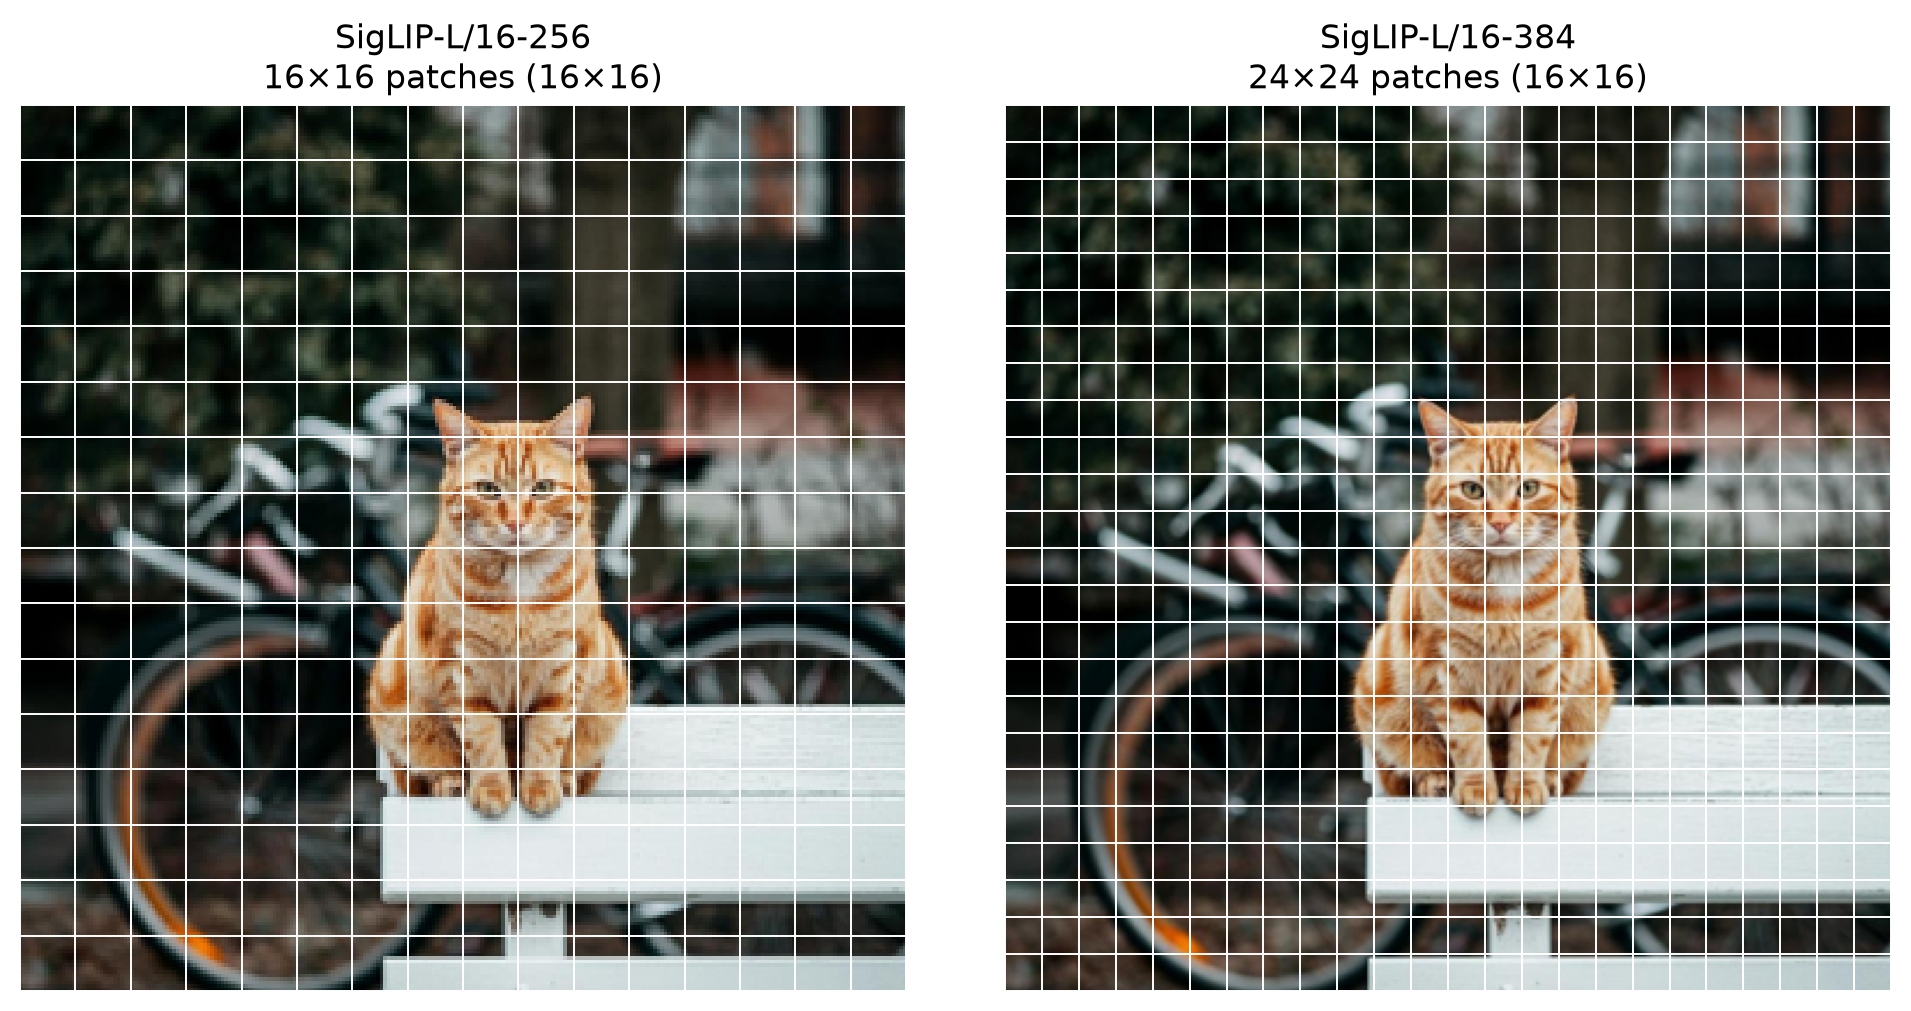

In [63]:
# график
row = train.iloc[7]

# resize без center_crop
img_256 = decode_image(row['image_1']).resize((256, 256))
img_384 = decode_image(row['image_1']).resize((384, 384))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

draw_patch_grid(axes[0], img_256, patch_size=16, title='SigLIP-L/16-256')
draw_patch_grid(axes[1], img_384, patch_size=16, title='SigLIP-L/16-384')

plt.tight_layout()
plt.show()


---

### Encoder setup


In [64]:
SIGLIP_256_MODEL_NAME = 'google/siglip-large-patch16-256'
SIGLIP_256_NAME = 'siglip-large-256'

In [65]:
siglip_256_processor = AutoProcessor.from_pretrained(SIGLIP_256_MODEL_NAME)
siglip_256_encoder = AutoModel.from_pretrained(SIGLIP_256_MODEL_NAME).to(DEVICE)
siglip_256_encoder.eval();

[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.
Loading weights: 100%|██████████| 792/792 [00:00<00:00, 8587.71it/s]


In [66]:
# параметры processor и vision encoder

print(f'\n=== {SIGLIP_256_MODEL_NAME} ===\n')

ip = siglip_256_processor.image_processor
vm = siglip_256_encoder.vision_model

print(f'image processor type: {ip.to_dict()["image_processor_type"]}\n'
      f'resize size:          {ip.size["height"]} × {ip.size["width"]}\n')

print(f'patch embedding:      {vm.embeddings.patch_embedding}')
print(f'ViT tokens:           {vm.embeddings.position_embedding.num_embeddings} '
      f'patch tokens × {vm.embeddings.position_embedding.embedding_dim}')

layer = vm.encoder.layers[0]
mlp = layer.mlp

print(f'transformer blocks:   {len(vm.encoder.layers)} × '
      f'[{layer.self_attn.num_heads}-head attention | '
      f'MLP {mlp.fc1.in_features} → {mlp.fc1.out_features} → {mlp.fc2.out_features} | '
      f'{type(mlp.activation_fn).__name__}]')

head_mlp = vm.head.mlp

print(f'pooling head:         {vm.head.__class__.__name__}')
print(f'head MLP:             {head_mlp.fc1.in_features} → '
      f'{head_mlp.fc1.out_features} → {head_mlp.fc2.out_features}')


=== google/siglip-large-patch16-256 ===

image processor type: SiglipImageProcessor
resize size:          256 × 256

patch embedding:      Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16), padding=valid)
ViT tokens:           256 patch tokens × 1024
transformer blocks:   24 × [16-head attention | MLP 1024 → 4096 → 1024 | GELUTanh]
pooling head:         SiglipMultiheadAttentionPoolingHead
head MLP:             1024 → 4096 → 1024


**SigLIP-L/16-256**  и CLIP ViT-L/14 делят изображение на одинаковое количество патчей = 256. Но SigLIP масштабирует изображение до 256×256 без учета пропорций. CLIP меняет размер с сохранением пропорций, а затем вырезает квадрат 224×224 из центра.

SigLIP содержит 24 трансформер-блока с attention и внутренней MLP 1024 → 4096 → 1024. Вместо QuickGELU, как в CLIP, используется GELUTanh. Это две немного разные приближенные версии GELU: GELUTanh использует формулу с tanh, а QuickGELU более простую формулу с sigmoid. На практике разница между ними обычно небольшая.

После трансформер-блоков в SigLIP стоит SiglipMultiheadAttentionPoolingHead. В CLIP итоговое представление берется из CLS-токена и проходит через линейную проекцию. В SigLIP CLS-токена нет: pooling head через attention собирает информацию из всех патчей, а затем пропускает результат через небольшую MLP.


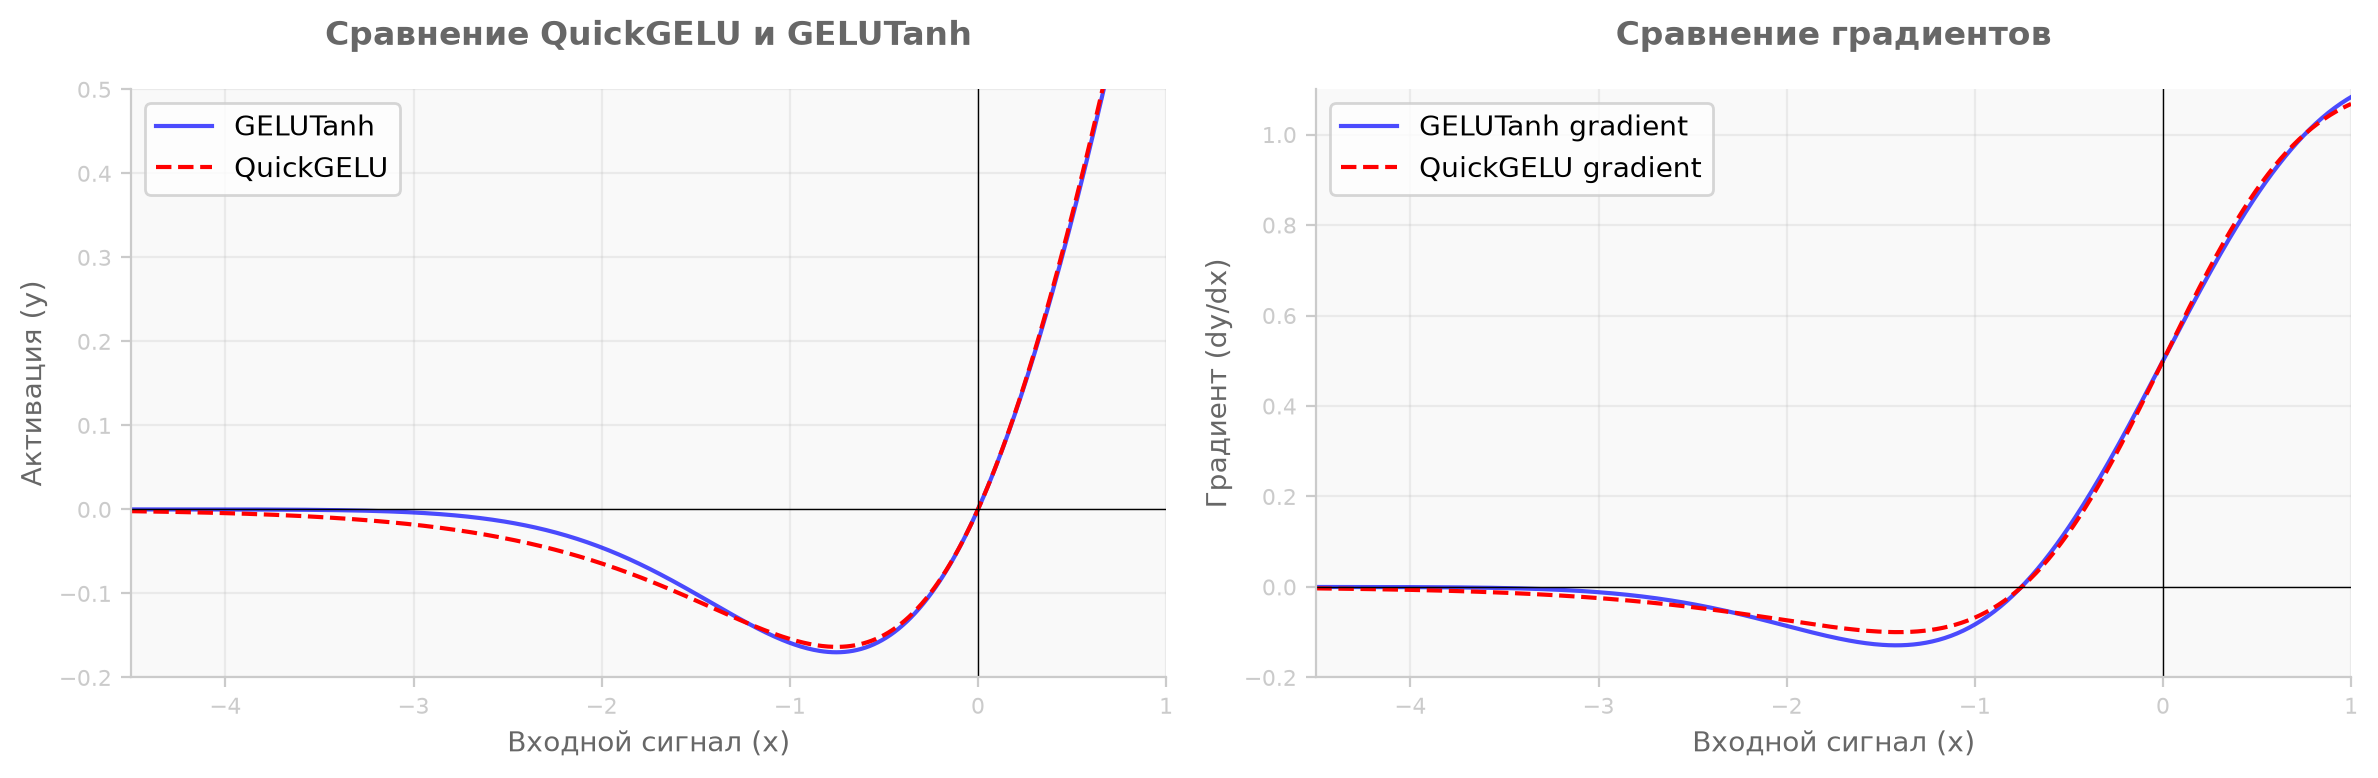

In [67]:
# сравнение QuickGELU и GELUTanh

quick_gelu = lambda x: x / (1 + np.exp(-1.702 * x))
gelu_tanh = lambda x: F.gelu(torch.tensor(x, dtype=torch.float32), approximate='tanh').numpy()

x = np.linspace(-4.5, 1, 500)

x_torch1 = torch.tensor(x, dtype=torch.float32, requires_grad=True)
x_torch2 = torch.tensor(x, dtype=torch.float32, requires_grad=True)

y_quick_grad = x_torch1 * torch.sigmoid(1.702 * x_torch1)
y_tanh_grad = F.gelu(x_torch2, approximate='tanh')

y_quick_grad.sum().backward()
y_tanh_grad.sum().backward()

grad_quick = x_torch1.grad.numpy()
grad_tanh = x_torch2.grad.numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x, gelu_tanh(x), 'b-', alpha=0.7, label='GELUTanh')
axes[0].plot(x, quick_gelu(x), 'r--', label='QuickGELU')
axes[0].set_title('Сравнение QuickGELU и GELUTanh', color='#676767', fontsize=12, fontweight='bold', pad=16)
axes[0].set_ylabel('Активация (y)', color='#676767')
axes[0].set_ylim([-0.2, 0.5])

axes[1].plot(x, grad_tanh, 'b-', alpha=0.7, label='GELUTanh gradient')
axes[1].plot(x, grad_quick, 'r--', label='QuickGELU gradient')
axes[1].set_title('Сравнение градиентов', color='#676767', fontsize=12, fontweight='bold', pad=16)
axes[1].set_ylabel('Градиент (dy/dx)', color='#676767')
axes[1].set_ylim([-0.2, 1.1])

for ax in axes:
    ax.set_xlabel('Входной сигнал (x)', color='#676767')
    ax.set_xlim([-4.5, 1])
    ax.set_facecolor("#f9f9f9")
    ax.grid(True, alpha=0.2)
    ax.axhline(0, color='k', lw=0.5)
    ax.axvline(0, color='k', lw=0.5)
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#CBCBCB')
    ax.tick_params(axis='both', colors='#CBCBCB', labelsize=8)

plt.tight_layout()
plt.show()

---

### Embeddings


In [68]:
# достаем tensor с image embeddings из выхода SigLIP

def get_siglip_embedding_tensor(outputs):
    if isinstance(outputs, torch.Tensor):
        return outputs

    if hasattr(outputs, 'image_embeds') and outputs.image_embeds is not None:
        return outputs.image_embeds

    if hasattr(outputs, 'pooler_output') and outputs.pooler_output is not None:
        return outputs.pooler_output

    if hasattr(outputs, 'last_hidden_state') and outputs.last_hidden_state is not None:
        return outputs.last_hidden_state[:, 0]

    raise ValueError(f'cannot extract embeddings from output type: {type(outputs)}')


In [69]:
# функция расчета SigLIP 256 embeddings

def extract_siglip_256_embeddings(images, batch_size=8):
    embeddings = []

    for start in tqdm(range(0, len(images), batch_size)):
        batch_bytes = images[start:start + batch_size]
        batch_images = [decode_image(image_bytes) for image_bytes in batch_bytes]
        inputs = siglip_256_processor(images=batch_images, return_tensors='pt').to(DEVICE)

        with torch.no_grad():
            if hasattr(siglip_256_encoder, 'get_image_features'):
                outputs = siglip_256_encoder.get_image_features(**inputs)
            elif hasattr(siglip_256_encoder, 'vision_model'):
                outputs = siglip_256_encoder.vision_model(pixel_values=inputs['pixel_values'])
            else:
                outputs = siglip_256_encoder(**inputs)

            batch_embeddings = get_siglip_embedding_tensor(outputs)
            batch_embeddings = batch_embeddings / batch_embeddings.norm(dim=1, keepdim=True)

        embeddings.append(batch_embeddings.cpu().numpy().astype('float32'))

    return np.vstack(embeddings)

In [70]:
# embeddings для train image_1/image_2
siglip_256_train_emb = {}

for image_name, suffix in [('image_1', 'emb_1'), ('image_2', 'emb_2')]:
    siglip_256_train_emb[image_name] = get_cached_embeddings(
        ARTEFACTS_DIR / f'{SIGLIP_256_NAME}_train_{suffix}.npy',
        train[image_name],
        extract_siglip_256_embeddings
    )

# embeddings для test image_1/image_2
siglip_256_test_emb = {}

for image_name, suffix in [('image_1', 'emb_1'), ('image_2', 'emb_2')]:
    siglip_256_test_emb[image_name] = get_cached_embeddings(
        ARTEFACTS_DIR / f'{SIGLIP_256_NAME}_test_{suffix}.npy',
        test[image_name],
        extract_siglip_256_embeddings
    )

loading embeddings: artefacts/siglip-large-256_train_emb_1.npy
embeddings shape: (8710, 1024)
loading embeddings: artefacts/siglip-large-256_train_emb_2.npy
embeddings shape: (8710, 1024)
loading embeddings: artefacts/siglip-large-256_test_emb_1.npy
embeddings shape: (4290, 1024)
loading embeddings: artefacts/siglip-large-256_test_emb_2.npy
embeddings shape: (4290, 1024)


---

### Pair features


Ожидаемый размер матриц после добавления pair features:

5 feature blocks * 1024 = **5120**

In [71]:
# матрицы pair features для Siglip 256 CatBoost

X_siglip_256 = pair_embedding_features(
    siglip_256_train_emb['image_1'],
    siglip_256_train_emb['image_2']
)

X_siglip_256_test = pair_embedding_features(
    siglip_256_test_emb['image_1'],
    siglip_256_test_emb['image_2']
)

print(f'X_siglip_256 shape:      {X_siglip_256.shape}')
print(f'X_siglip_256_test shape: {X_siglip_256_test.shape}')


X_siglip_256 shape:      (8710, 5120)
X_siglip_256_test shape: (4290, 5120)


---

### CatBoost Classifier · <small>SigLIP 256 embeddings</small>


In [72]:
cb_siglip_256_params = {
    'iterations': 700,
    'depth': 5,
    'l2_leaf_reg': 5,
}


In [73]:
print(f'=== CatBoost seed ensemble | {SIGLIP_256_NAME} ===')

siglip_256_catboost_oof_path = ARTEFACTS_DIR / f'{SIGLIP_256_NAME}_catboost_oof_pred.npy'
siglip_256_catboost_test_path = ARTEFACTS_DIR / f'{SIGLIP_256_NAME}_catboost_test_pred.npy'

# если артефакты существуют и CB_RETRAIN = False: загружаем артефакты
if siglip_256_catboost_oof_path.exists() and siglip_256_catboost_test_path.exists() and not CB_RETRAIN:
    siglip_256_catboost_oof_pred = np.load(siglip_256_catboost_oof_path)
    siglip_256_catboost_test_pred = np.load(siglip_256_catboost_test_path)
    print()
    print(f'oof loaded: {siglip_256_catboost_oof_path}; shape={siglip_256_catboost_oof_pred.shape}')
    print(f'test loaded: {siglip_256_catboost_test_path}; shape={siglip_256_catboost_test_pred.shape}')

# иначе - переобучение CatBoost Classifier seed ensemble
else:
    print(f'params={cb_siglip_256_params}')
    print(f'split seed: {SEED}; model seeds={seeds_11}\n')

    siglip_256_catboost_seed_oof_preds = []
    siglip_256_catboost_seed_test_preds = []

    # запускаем функцию обучения run_catboost_cv 
    for model_seed in seeds_11:
        print(f'seed={model_seed}')
        seed_oof_pred, seed_test_pred, seed_cv_auc = run_catboost_cv(
            X_siglip_256,
            X_siglip_256_test,
            target,
            cb_siglip_256_params,
            seed=model_seed,
            split_seed=SEED
        )
        print(f'CV ROC AUC: {seed_cv_auc:.6f}\n')

        siglip_256_catboost_seed_oof_preds.append(seed_oof_pred)
        siglip_256_catboost_seed_test_preds.append(seed_test_pred)

    # усредняем предсказания по seeds
    siglip_256_catboost_oof_pred = np.mean(siglip_256_catboost_seed_oof_preds, axis=0)
    siglip_256_catboost_test_pred = np.mean(siglip_256_catboost_seed_test_preds, axis=0)

    # сохранение артефактов модели
    np.save(siglip_256_catboost_oof_path, siglip_256_catboost_oof_pred)
    np.save(siglip_256_catboost_test_path, siglip_256_catboost_test_pred)

    print(f'saved oof predictions: {siglip_256_catboost_oof_path}; '
          f'shape={siglip_256_catboost_oof_pred.shape}')
    print(f'saved test predictions: {siglip_256_catboost_test_path}; '
          f'shape={siglip_256_catboost_test_pred.shape}')

siglip_256_catboost_cv_auc = roc_auc_score(target, siglip_256_catboost_oof_pred)

print(f'CV ROC AUC: {siglip_256_catboost_cv_auc:.6f}')

=== CatBoost seed ensemble | siglip-large-256 ===

oof loaded: artefacts/siglip-large-256_catboost_oof_pred.npy; shape=(8710,)
test loaded: artefacts/siglip-large-256_catboost_test_pred.npy; shape=(4290,)
CV ROC AUC: 0.667187


<div style="font-size:14px; font-weight:700; margin-bottom:6px;">Model training log</div>

<pre style="
  background:#fcfcfc; border:1px solid #d1d5db; border-radius:6px; padding:12px 14px;
  font-size:11px; line-height:1.45; overflow-x:auto; white-space:pre; text-align:left;
  display:block; width:99%; max-width:100%; box-sizing:border-box; margin:0 0 16px 0;
">=== CatBoost seed ensemble | siglip-large-256 ===

seed=42 | folds=[0.657829 0.668763 0.653552 0.663939 0.655539] | best_iter=[569 592 428 512 618] | CV AUC=0.659526
seed=43 | folds=[0.652560 0.665293 0.663465 0.668954 0.660392] | best_iter=[226 192 311 642 468] | CV AUC=0.659495
seed=44 | folds=[0.650934 0.663500 0.654136 0.668665 0.659438] | best_iter=[303 378 352 399 633] | CV AUC=0.658583
seed=45 | folds=[0.650112 0.673652 0.648032 0.665828 0.658628] | best_iter=[387 436 471 315 451] | CV AUC=0.658447
seed=46 | folds=[0.652349 0.668892 0.652379 0.665220 0.663759] | best_iter=[355 382 328 694 445] | CV AUC=0.659175
seed=47 | folds=[0.652528 0.663684 0.655718 0.664038 0.654999] | best_iter=[547 490 687 505 393] | CV AUC=0.657573
seed=48 | folds=[0.657031 0.666680 0.654285 0.658661 0.658312] | best_iter=[373 518 403 694 510] | CV AUC=0.658555
seed=49 | folds=[0.655519 0.664992 0.658638 0.668302 0.655156] | best_iter=[226 329 199 590 539] | CV AUC=0.658264
seed=50 | folds=[0.655732 0.667840 0.653374 0.668320 0.658534] | best_iter=[150 382 615 653 516] | CV AUC=0.657271
seed=51 | folds=[0.652470 0.666861 0.658796 0.664824 0.658805] | best_iter=[534 245 694 420 495] | CV AUC=0.657652
seed=52 | folds=[0.654356 0.664864 0.658680 0.668267 0.663247] | best_iter=[523 319 667 664 372] | CV AUC=0.660575

seed ensemble OOF ROC AUC=0.667187</pre>

In [74]:
model_scores_df = update_model_score(
    model_scores_df,
    encoder='SigLIP 256',
    model='CatBoost',
    n_seeds=len(seeds_11),
    oof_roc_auc=siglip_256_catboost_cv_auc
)

model_scores_df.style.background_gradient(cmap='Blues', subset='oof_roc_auc')

,encoder,model,n_seeds,oof_roc_auc
0,CLIP ViT Base,CatBoost,11,0.658693
1,CLIP ViT Base,Siamese,11,0.658450
2,CLIP ViT Large,CatBoost,11,0.657851
3,CLIP ViT Large,Siamese,11,0.654819
4,SigLIP 256,CatBoost,11,0.667187


---

### Siamese comparator · <small>SigLIP 256 embeddings</small>


<table style="width:auto; table-layout:auto; border-collapse:collapse; font-size:13px; line-height:1.45; margin:12px auto 18px 0;">
  <thead>
    <tr>
      <th style="background:#f3f4f6; color:#111827; text-align:left; font-weight:600; border:1px solid #e0e0e0; padding:8px 10px;">1 | Shared tower</th>
      <th style="background:#f3f4f6; color:#111827; text-align:left; font-weight:600; border:1px solid #e0e0e0; padding:8px 10px;">2 | Pair features</th>
      <th style="background:#f3f4f6; color:#111827; text-align:left; font-weight:600; border:1px solid #e0e0e0; padding:8px 10px;">3 | MLP head</th>
      <th style="background:#f3f4f6; color:#111827; text-align:left; font-weight:600; border:1px solid #e0e0e0; padding:8px 10px;">4 | Inference</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="border:1px solid #e0e0e0; padding:0 10px; vertical-align:top;">
        <p style="margin:12px 0;">Input:<br>
          <span style="display:inline-flex; align-items:stretch; background:#ffffff; color:#374151; border-radius:4px; font-size:13px; border:1px solid #365489; margin:2px 3px; overflow:hidden;"><span style="padding:1px 6px;">emb_1</span><span style="padding:1px 5px; border-left:1px solid #365489; background:#f3f6fb; color:#365489; font-weight:600;">1024</span></span>
          <span style="display:inline-flex; align-items:stretch; background:#ffffff; color:#374151; border-radius:4px; font-size:13px; border:1px solid #365489; margin:2px 3px; overflow:hidden;"><span style="padding:1px 6px;">emb_2</span><span style="padding:1px 5px; border-left:1px solid #365489; background:#f3f6fb; color:#365489; font-weight:600;">1024</span></span>
        </p>
        <p style="font-size:12px; color:#6b7280; line-height:1.3em; margin:8px 0;">
          same self.tower:<br>
          <span style="display:inline-flex; background:#f0f1f4; padding:1px 5px; border-radius:4px;">1</span> Linear 1024 → 512<br>
          ReLU | Dropout(0.20)<br>
          <span style="display:inline-flex; background:#f0f1f4; padding:1px 5px; border-radius:4px;">2</span> Linear 512 → 256<br>
          ReLU | Dropout(0.20)
        </p>
        <p style="margin:12px 0;">Output:<br>
          z1=<span style="display:inline-flex; align-items:stretch; background:#ffffff; color:#374151; border-radius:4px; font-size:13px; border:1px solid #365489; margin:2px 3px; overflow:hidden;"><span style="padding:1px 6px;">tower(emb_1)</span><span style="padding:1px 5px; border-left:1px solid #365489; background:#f3f6fb; color:#365489; font-weight:600;">256</span></span><br>
          z2=<span style="display:inline-flex; align-items:stretch; background:#ffffff; color:#374151; border-radius:4px; font-size:13px; border:1px solid #365489; margin:2px 3px; overflow:hidden;"><span style="padding:1px 6px;">tower(emb_2)</span><span style="padding:1px 5px; border-left:1px solid #365489; background:#f3f6fb; color:#365489; font-weight:600;">256</span></span>
        </p>
      </td>
      <td style="border:1px solid #e0e0e0; padding:0 10px; vertical-align:top;">
        <p style="margin:12px 0;">Input:<br>
          <span style="display:inline-flex; align-items:stretch; background:#ffffff; color:#374151; border-radius:4px; font-size:13px; border:1px solid #365489; margin:2px 3px; overflow:hidden;"><span style="padding:1px 6px;">z1</span><span style="padding:1px 5px; border-left:1px solid #365489; background:#f3f6fb; color:#365489; font-weight:600;">256</span></span>
          <span style="display:inline-flex; align-items:stretch; background:#ffffff; color:#374151; border-radius:4px; font-size:13px; border:1px solid #365489; margin:2px 3px; overflow:hidden;"><span style="padding:1px 6px;">z2</span><span style="padding:1px 5px; border-left:1px solid #365489; background:#f3f6fb; color:#365489; font-weight:600;">256</span></span>
        </p>
        <p style="font-size:12px; color:#6b7280; line-height:1.3em; margin:8px 0;">
          torch.cat:<br>
          <b>256</b>: z1<br>
          <b>256</b>: z2<br>
          <b>256</b>: z1 - z2<br>
          <b>256</b>: |z1 - z2|
        </p>
        <p style="margin:12px 0;">Output:<br>
          <span style="display:inline-flex; align-items:stretch; background:#ffffff; color:#374151; border-radius:4px; font-size:13px; border:1px solid #365489; margin:2px 3px; overflow:hidden;"><span style="padding:1px 6px;">pair vector</span><span style="padding:1px 5px; border-left:1px solid #365489; background:#f3f6fb; color:#365489; font-weight:600;">1024</span></span>
        </p>
      </td>
      <td style="border:1px solid #e0e0e0; padding:0 10px; vertical-align:top;">
        <p style="margin:12px 0;">Input:<br>
          <span style="display:inline-flex; align-items:stretch; background:#ffffff; color:#374151; border-radius:4px; font-size:13px; border:1px solid #365489; margin:2px 3px; overflow:hidden;"><span style="padding:1px 6px;">pair vector</span><span style="padding:1px 5px; border-left:1px solid #365489; background:#f3f6fb; color:#365489; font-weight:600;">1024</span></span>
        </p>
        <p style="font-size:12px; color:#6b7280; line-height:1.3em; margin:8px 0;"><span style="display:inline-flex; background:#f0f1f4; padding:1px 5px; border-radius:4px;">1</span> Linear 1024 → 512<br>ReLU | Dropout(0.20)</p>
        <p style="font-size:12px; color:#6b7280; line-height:1.3em; margin:8px 0;"><span style="display:inline-flex; background:#f0f1f4; padding:1px 5px; border-radius:4px;">2</span> Linear 512 → 128<br>ReLU | Dropout(0.20)</p>
        <p style="font-size:12px; color:#6b7280; line-height:1.3em; margin:8px 0;"><span style="display:inline-flex; background:#f0f1f4; padding:1px 5px; border-radius:4px;">3</span> Linear 128 → 1</p>
        <p style="margin:12px 0;">Output:
          <span style="display:inline-flex; align-items:stretch; background:#ffffff; color:#374151; border-radius:4px; font-size:13px; border:1px solid #365489; margin:2px 3px; overflow:hidden;"><span style="padding:1px 6px;">logit</span><span style="padding:1px 5px; border-left:1px solid #365489; background:#f3f6fb; color:#365489; font-weight:600;">1</span></span>
        </p>
      </td>
      <td style="border:1px solid #e0e0e0; padding:0 10px; vertical-align:top;">
        <p style="margin:12px 0;">Input:<br>
          <span style="display:inline-flex; align-items:stretch; background:#ffffff; color:#374151; border-radius:4px; font-size:13px; border:1px solid #365489; margin:2px 3px; overflow:hidden;"><span style="padding:1px 6px;">logit</span><span style="padding:1px 5px; border-left:1px solid #365489; background:#f3f6fb; color:#365489; font-weight:600;">1</span></span>
        </p>
        <p style="font-size:12px; color:#6b7280; line-height:1.3em; margin:8px 0;">sigmoid(logit)</p>
        <p style="margin:12px 0;">Output:<br>
          <span style="display:inline-flex; align-items:stretch; background:#ffffff; color:#374151; border-radius:4px; font-size:13px; border:1px solid #365489; margin:2px 3px; overflow:hidden;"><span style="padding:1px 6px;">score image_1</span><span style="padding:1px 5px; border-left:1px solid #365489; background:#f3f6fb; color:#365489; font-weight:600;">1</span></span>
        </p>
      </td>
    </tr>
  </tbody>
</table>

In [75]:
siglip_256_siamese_model_params = {
    'tower_dims': (512, 256),
    'head_dims': (512, 128),
    'dropout': 0.20,
}

siglip_256_siamese_train_params = {
    'augment_swap': False,
    'lr': 7e-4,
    'weight_decay': 1e-4,
    'batch_size': 256,
    'epochs': 25,
    'patience': 5,
}

In [76]:
print(f'=== Siamese | {SIGLIP_256_NAME} ===')

siglip_256_siamese_oof_path = ARTEFACTS_DIR / f'{SIGLIP_256_NAME}_siamese_oof_pred.npy'
siglip_256_siamese_test_path = ARTEFACTS_DIR / f'{SIGLIP_256_NAME}_siamese_test_pred.npy'

# если артефакты существуют и SIAMESE_RETRAIN = False: загружаем артефакты
if siglip_256_siamese_oof_path.exists() and siglip_256_siamese_test_path.exists() and not SIAMESE_RETRAIN:
    siglip_256_siamese_oof_pred = np.load(siglip_256_siamese_oof_path)
    siglip_256_siamese_test_pred = np.load(siglip_256_siamese_test_path)
    print()
    print(f'oof loaded:  {siglip_256_siamese_oof_path}; shape={siglip_256_siamese_oof_pred.shape}')
    print(f'test loaded: {siglip_256_siamese_test_path}; shape={siglip_256_siamese_test_pred.shape}')

# иначе - переобучение Siamese seed ensemble
else:
    print(f'model params={siglip_256_siamese_model_params}')
    print(f'train params={siglip_256_siamese_train_params}')
    print(f'model seeds={seeds_11}; split seed: {SEED}\n')

    siglip_256_siamese_seed_oof_preds = []
    siglip_256_siamese_seed_test_preds = []
    verbose = True

    # cv обучение для каждого сида
    for model_seed in seeds_11:
        (
            seed_oof_pred,
            seed_test_pred,
            seed_fold_scores,
            seed_best_epochs,
            seed_cv_auc,
        ) = run_siamese_cv(
            train_emb=siglip_256_train_emb,
            test_emb=siglip_256_test_emb,
            target=target,
            params={
                **siglip_256_siamese_model_params,
                **siglip_256_siamese_train_params,
            },
            split_seed=SEED,
            model_seed=model_seed,
            verbose=verbose
        )

        if not verbose:
            print(
                f'seed={model_seed} | '
                f'fold scores=[{" ".join(f"{score:.6f}" for score in seed_fold_scores)}] | '
                f'best epochs=[{" ".join(f"{epoch:02d}" for epoch in seed_best_epochs)}] | '
                f'CV ROC AUC: {seed_cv_auc:.6f}'
            )

        siglip_256_siamese_seed_oof_preds.append(seed_oof_pred)
        siglip_256_siamese_seed_test_preds.append(seed_test_pred)

    siglip_256_siamese_oof_pred = np.mean(siglip_256_siamese_seed_oof_preds, axis=0)
    siglip_256_siamese_test_pred = np.mean(siglip_256_siamese_seed_test_preds, axis=0)

    np.save(siglip_256_siamese_oof_path, siglip_256_siamese_oof_pred)
    np.save(siglip_256_siamese_test_path, siglip_256_siamese_test_pred)

    print(f'\nsaved oof predictions:  {siglip_256_siamese_oof_path}; '
          f'shape={siglip_256_siamese_oof_pred.shape}')
    print(f'saved test predictions: {siglip_256_siamese_test_path}; '
          f'shape={siglip_256_siamese_test_pred.shape}')

siglip_256_siamese_cv_auc = roc_auc_score(target, siglip_256_siamese_oof_pred)
print(f'seed ensemble OOF ROC AUC: {siglip_256_siamese_cv_auc:.6f}')

=== Siamese | siglip-large-256 ===

oof loaded:  artefacts/siglip-large-256_siamese_oof_pred.npy; shape=(8710,)
test loaded: artefacts/siglip-large-256_siamese_test_pred.npy; shape=(4290,)
seed ensemble OOF ROC AUC: 0.660901


<div style="font-size:14px; font-weight:700; margin-bottom:6px;">Model training log</div>

<pre style="
  background:#fcfcfc; border:1px solid #d1d5db; border-radius:6px; padding:12px 14px;
  font-size:11px; line-height:1.45; overflow-x:auto; white-space:pre; text-align:left;
  display:block; width:99%; max-width:100%; box-sizing:border-box; margin:0 0 16px 0;
">=== Siamese | siglip-large-256 ===

model params={'tower_dims': (512, 256), 'head_dims': (512, 128), 'dropout': 0.2}
train params={'augment_swap': False, 'lr': 0.0007, 'weight_decay': 0.0001, 'batch_size': 256, 'epochs': 25, 'patience': 5}
model seeds=[42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52]; split seed: 42

seed=42 | folds=[0.653050 0.666764 0.646423 0.664047 0.655636] | epochs=[04 03 04 05 05] | CV AUC=0.650780
seed=43 | folds=[0.650027 0.664788 0.645656 0.661289 0.659102] | epochs=[04 04 04 06 06] | CV AUC=0.652940
seed=44 | folds=[0.651580 0.662389 0.640689 0.664974 0.657231] | epochs=[07 03 05 05 05] | CV AUC=0.649216
seed=45 | folds=[0.648057 0.667228 0.647450 0.660279 0.665678] | epochs=[04 06 04 05 06] | CV AUC=0.654814
seed=46 | folds=[0.648287 0.666101 0.640631 0.664745 0.655971] | epochs=[07 04 04 05 05] | CV AUC=0.648851
seed=47 | folds=[0.646838 0.662829 0.645947 0.664754 0.659436] | epochs=[05 03 04 05 05] | CV AUC=0.648289
seed=48 | folds=[0.650981 0.666639 0.641048 0.665921 0.659569] | epochs=[05 03 04 05 05] | CV AUC=0.649966
seed=49 | folds=[0.650584 0.665001 0.642063 0.663816 0.654436] | epochs=[05 03 04 07 05] | CV AUC=0.650372
seed=50 | folds=[0.654278 0.667680 0.642035 0.668195 0.658376] | epochs=[05 04 04 05 05] | CV AUC=0.655134
seed=51 | folds=[0.649566 0.666267 0.643242 0.663561 0.656421] | epochs=[05 04 06 06 06] | CV AUC=0.649236
seed=52 | folds=[0.652227 0.662368 0.644015 0.667784 0.658990] | epochs=[05 04 09 05 05] | CV AUC=0.651578

seed ensemble OOF ROC AUC=0.660901</pre>

In [77]:
model_scores_df = update_model_score(
    model_scores_df,
    encoder='SigLIP 256',
    model='Siamese',
    n_seeds=len(seeds_11),
    oof_roc_auc=siglip_256_siamese_cv_auc
)

model_scores_df.style.background_gradient('Blues', subset='oof_roc_auc')

,encoder,model,n_seeds,oof_roc_auc
0,CLIP ViT Base,CatBoost,11,0.658693
1,CLIP ViT Base,Siamese,11,0.658450
2,CLIP ViT Large,CatBoost,11,0.657851
3,CLIP ViT Large,Siamese,11,0.654819
4,SigLIP 256,CatBoost,11,0.667187
5,SigLIP 256,Siamese,11,0.660901


<div style="
    background: #f3f4f6;
    border-radius: 6px;
    margin-top:20px;
    height: 30px;
"></div>

## SigLIP 384

**Encoder:** `google/siglip-large-patch16-384`  
**Source:** Hugging Face / transformers  
**Backbone:** ViT-L/16  
**Input size:** 384×384  
**Patch size:** 16×16  
**Models:** CatBoost

### Encoder setup


In [78]:
SIGLIP_384_MODEL_NAME = 'google/siglip-large-patch16-384'
SIGLIP_384_NAME = 'siglip-large-384'

In [79]:
siglip_384_processor = AutoProcessor.from_pretrained(SIGLIP_384_MODEL_NAME)
siglip_384_encoder = AutoModel.from_pretrained(SIGLIP_384_MODEL_NAME).to(DEVICE)
siglip_384_encoder.eval();

Loading weights: 100%|██████████| 792/792 [00:00<00:00, 8086.25it/s]


In [80]:
# параметры processor и vision encoder

print(f'\n=== {SIGLIP_384_MODEL_NAME} ===\n')

ip = siglip_384_processor.image_processor
vm = siglip_384_encoder.vision_model

print(f'image processor type: {ip.to_dict()["image_processor_type"]}\n'
      f'resize size:          {ip.size["height"]} × {ip.size["width"]}\n')

print(f'patch embedding:      {vm.embeddings.patch_embedding}')
print(f'ViT tokens:           {vm.embeddings.position_embedding.num_embeddings} '
      f'patch tokens × {vm.embeddings.position_embedding.embedding_dim}')

layer = vm.encoder.layers[0]
mlp = layer.mlp

print(f'transformer blocks:   {len(vm.encoder.layers)} × '
      f'[{layer.self_attn.num_heads}-head attention | '
      f'MLP {mlp.fc1.in_features} → {mlp.fc1.out_features} → {mlp.fc2.out_features} | '
      f'{type(mlp.activation_fn).__name__}]')

head_mlp = vm.head.mlp

print(f'pooling head:         {vm.head.__class__.__name__}')
print(f'head MLP:             {head_mlp.fc1.in_features} → '
      f'{head_mlp.fc1.out_features} → {head_mlp.fc2.out_features}')


=== google/siglip-large-patch16-384 ===

image processor type: SiglipImageProcessor
resize size:          384 × 384

patch embedding:      Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16), padding=valid)
ViT tokens:           576 patch tokens × 1024
transformer blocks:   24 × [16-head attention | MLP 1024 → 4096 → 1024 | GELUTanh]
pooling head:         SiglipMultiheadAttentionPoolingHead
head MLP:             1024 → 4096 → 1024


Версия **siglip-large-patch16-384** получает изображение в более высоком разрешении и разбивает его на большее количество токенов при том же размере патча 16 × 16: 576 токенов вместо 256. Поэтому версия 384 лучше сохраняет мелкие детали, версия 256 сильнее упрощает их при уменьшении изображения. Архитектура у них практически одна и та же.

---

### Embeddings


In [81]:
# функция расчета SigLIP 384 embeddings
def extract_siglip_384_embeddings(images, batch_size=16):
    embeddings = []

    for start in tqdm(range(0, len(images), batch_size)):
        batch_bytes = images[start:start + batch_size]
        batch_images = [decode_image(image_bytes) for image_bytes in batch_bytes]
        inputs = siglip_384_processor(images=batch_images, return_tensors='pt').to(DEVICE)

        with torch.no_grad():
            if hasattr(siglip_384_encoder, 'get_image_features'):
                outputs = siglip_384_encoder.get_image_features(**inputs)
            else:
                outputs = siglip_384_encoder.vision_model(pixel_values=inputs['pixel_values'])

            batch_embeddings = get_siglip_embedding_tensor(outputs)
            batch_embeddings = batch_embeddings / batch_embeddings.norm(dim=1, keepdim=True)

        embeddings.append(batch_embeddings.cpu().numpy().astype('float32'))

    return np.vstack(embeddings)

In [82]:
# embeddings для train image_1/image_2
siglip_384_train_emb = {}

for image_name, suffix in [('image_1', 'emb_1'), ('image_2', 'emb_2')]:
    siglip_384_train_emb[image_name] = get_cached_embeddings(
        ARTEFACTS_DIR / f'{SIGLIP_384_NAME}_train_{suffix}.npy',
        train[image_name],
        extract_siglip_384_embeddings
    )

# embeddings для test image_1/image_2
siglip_384_test_emb = {}

for image_name, suffix in [('image_1', 'emb_1'), ('image_2', 'emb_2')]:
    siglip_384_test_emb[image_name] = get_cached_embeddings(
        ARTEFACTS_DIR / f'{SIGLIP_384_NAME}_test_{suffix}.npy',
        test[image_name],
        extract_siglip_384_embeddings
    )

loading embeddings: artefacts/siglip-large-384_train_emb_1.npy
embeddings shape: (8710, 1024)
loading embeddings: artefacts/siglip-large-384_train_emb_2.npy
embeddings shape: (8710, 1024)
loading embeddings: artefacts/siglip-large-384_test_emb_1.npy
embeddings shape: (4290, 1024)
loading embeddings: artefacts/siglip-large-384_test_emb_2.npy
embeddings shape: (4290, 1024)


---

### Pair features


Ожидаемый размер матриц после добавления pair features:

5 feature blocks * 1024 = **5120**

In [83]:
# матрицы pair features для Siglip 384 CatBoost

X_siglip_384 = pair_embedding_features(
    siglip_384_train_emb['image_1'],
    siglip_384_train_emb['image_2']
)

X_siglip_384_test = pair_embedding_features(
    siglip_384_test_emb['image_1'],
    siglip_384_test_emb['image_2']
)

print(f'X_siglip_384 shape:      {X_siglip_384.shape}')
print(f'X_siglip_384_test shape: {X_siglip_384_test.shape}')


X_siglip_384 shape:      (8710, 5120)
X_siglip_384_test shape: (4290, 5120)


---

### CatBoost Classifier


In [84]:
cb_siglip_384_params = {
    'iterations': 700,
    'depth': 5,
    'l2_leaf_reg': 5,
}


In [85]:
print(f'=== CatBoost seed ensemble | {SIGLIP_384_NAME} ===')

siglip_384_catboost_oof_path = ARTEFACTS_DIR / f'{SIGLIP_384_NAME}_catboost_oof_pred.npy'
siglip_384_catboost_test_path = ARTEFACTS_DIR / f'{SIGLIP_384_NAME}_catboost_test_pred.npy'

# если артефакты существуют и CB_RETRAIN = False: загружаем артефакты
if siglip_384_catboost_oof_path.exists() and siglip_384_catboost_test_path.exists() and not CB_RETRAIN:
    siglip_384_catboost_oof_pred = np.load(siglip_384_catboost_oof_path)
    siglip_384_catboost_test_pred = np.load(siglip_384_catboost_test_path)

    print()
    print(f'oof loaded:  {siglip_384_catboost_oof_path};  shape={siglip_384_catboost_oof_pred.shape}')
    print(f'test loaded: {siglip_384_catboost_test_path}; shape={siglip_384_catboost_test_pred.shape}')

# иначе - переобучение CatBoost seed ensemble
else:
    print()
    print(f'params={cb_siglip_384_params}')
    print(f'split seed: {SEED}; model seeds={seeds_11}\n')

    siglip_384_catboost_seed_oof_preds = []
    siglip_384_catboost_seed_test_preds = []

    # cv обучение для каждого сида
    for model_seed in seeds_11:
        print(f'seed={model_seed}')

        seed_oof_pred, seed_test_pred, seed_cv_auc = run_catboost_cv(
            X_siglip_384,
            X_siglip_384_test,
            target,
            cb_siglip_384_params,
            seed=model_seed,
            split_seed=SEED
        )

        print(f'CV ROC AUC: {seed_cv_auc:.6f}\n')

        siglip_384_catboost_seed_oof_preds.append(seed_oof_pred)
        siglip_384_catboost_seed_test_preds.append(seed_test_pred)

    # усредняем предсказания по seeds
    siglip_384_catboost_oof_pred = np.mean(siglip_384_catboost_seed_oof_preds, axis=0)
    siglip_384_catboost_test_pred = np.mean(siglip_384_catboost_seed_test_preds, axis=0)

    np.save(siglip_384_catboost_oof_path, siglip_384_catboost_oof_pred)
    np.save(siglip_384_catboost_test_path, siglip_384_catboost_test_pred)

    print(f'saved oof predictions:  {siglip_384_catboost_oof_path};  '
          f'shape={siglip_384_catboost_oof_pred.shape}')
    print(f'saved test predictions: {siglip_384_catboost_test_path}; '
          f'shape={siglip_384_catboost_test_pred.shape}')

siglip_384_catboost_cv_auc = roc_auc_score(target, siglip_384_catboost_oof_pred)

print(f'CV ROC AUC: {siglip_384_catboost_cv_auc:.6f}')

=== CatBoost seed ensemble | siglip-large-384 ===

oof loaded:  artefacts/siglip-large-384_catboost_oof_pred.npy;  shape=(8710,)
test loaded: artefacts/siglip-large-384_catboost_test_pred.npy; shape=(4290,)
CV ROC AUC: 0.666871


<div style="font-size:14px; font-weight:700; margin-bottom:6px;">Model training log</div>

<pre style="
  background:#fcfcfc; border:1px solid #d1d5db; border-radius:6px; padding:12px 14px;
  font-size:11px; line-height:1.45; overflow-x:auto; white-space:pre; text-align:left;
  display:block; width:99%; max-width:100%; box-sizing:border-box; margin:0 0 16px 0;
">=== CatBoost seed ensemble | siglip-large-384 ===

params={'iterations': 700, 'depth': 5, 'l2_leaf_reg': 5}
split seed: 42; model seeds=[42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52]

seed=42 | folds=[0.648882 0.664726 0.658875 0.673224 0.658273] | best_iter=[553 258 499 570 652] | CV AUC=0.658832
seed=43 | folds=[0.652544 0.667548 0.650627 0.667208 0.665863] | best_iter=[692 225 684 304 697] | CV AUC=0.657416
seed=44 | folds=[0.653759 0.669376 0.650784 0.680771 0.657600] | best_iter=[310 330 352 482 508] | CV AUC=0.661992
seed=45 | folds=[0.650280 0.669068 0.659602 0.676678 0.661092] | best_iter=[552 195 304 619 675] | CV AUC=0.660046
seed=46 | folds=[0.650856 0.658569 0.655231 0.664659 0.668803] | best_iter=[674 540 430 425 665] | CV AUC=0.658826
seed=47 | folds=[0.649281 0.664301 0.661385 0.671345 0.656936] | best_iter=[668 528 568 292 665] | CV AUC=0.658667
seed=48 | folds=[0.649655 0.661172 0.649725 0.666311 0.660579] | best_iter=[520 316 478 631 494] | CV AUC=0.656817
seed=49 | folds=[0.652667 0.663072 0.656000 0.667482 0.664348] | best_iter=[648 245 314 400 617] | CV AUC=0.658163
seed=50 | folds=[0.652387 0.659902 0.653514 0.669978 0.659442] | best_iter=[560 288 581 697 527] | CV AUC=0.657400
seed=51 | folds=[0.659085 0.657796 0.655018 0.665099 0.659690] | best_iter=[660 637 299 419 414] | CV AUC=0.658098
seed=52 | folds=[0.649392 0.661023 0.662256 0.665030 0.667406] | best_iter=[504 532 348 594 576] | CV AUC=0.660184

seed ensemble OOF ROC AUC=0.666871</pre>

In [86]:
model_scores_df = update_model_score(
    model_scores_df,
    encoder='SigLIP 384',
    model='CatBoost',
    n_seeds=len(seeds_11),
    oof_roc_auc=siglip_384_catboost_cv_auc
)

model_scores_df.style.background_gradient('Blues', subset='oof_roc_auc')

,encoder,model,n_seeds,oof_roc_auc
0,CLIP ViT Base,CatBoost,11,0.658693
1,CLIP ViT Base,Siamese,11,0.658450
2,CLIP ViT Large,CatBoost,11,0.657851
3,CLIP ViT Large,Siamese,11,0.654819
4,SigLIP 256,CatBoost,11,0.667187
5,SigLIP 256,Siamese,11,0.660901
6,SigLIP 384,CatBoost,11,0.666871


<div style="
    background: #f3f4f6;
    border-radius: 6px;
    margin-top:20px;
    height: 30px;
"></div>

## OpenCLIP ConvNeXt

**Encoder:** `convnext_base_w`  
**Pretrained weights:** `laion2b_s13b_b82k_augreg`  
**Source:** open_clip  
**Backbone:** ConvNeXt Base W  
**Models:** CatBoost

Как и остальные OpenCLIP-модели, OpenCLIP ConvNeXt использует предобученный image encoder, но вместо Vision Transformer здесь применяется сверточная архитектура ConvNeXt.

| Input | Preprocessing | Stem | Stage 1 | Stage 2 | Stage 3 | Stage 4 | Pooling | Embedding |
|---|---|---:|---:|---:|---:|---:|---|---:|
| image | resize +<br> center crop<br>normalize pixels | 64×64×128 | 64×64×128 | 32×32×256 | 16×16×512 | 8×8×1024 | global<br>average<br>pooling | 1024-d |

- **Preprocessing**: приводит все изображения к одному размеру и масштабу значений пикселей, чтобы они соответствовали условиям, в которых модель была предобучена.
- **Stem**: первый сверточный слой. Он уменьшает пространственное разрешение изображения в 4 раза и преобразует RGB-пиксели в первые карты признаков (feature maps).
- **Stage 1-4**: последовательно извлекают все более сложные признаки. Пространственное разрешение уменьшается, а число каналов растет.
- **Global average pooling**: усредняет каждую карту признаков, превращая пространственное представление 8×8×1024 в один вектор длиной 1024.
- **Embedding**: итоговый вектор изображения, затем используется как вход для предсказательных моделей.


---

### Encoder setup


In [87]:
CONVNEXT_MODEL_NAME = 'convnext_base_w'
CONVNEXT_PRETRAINED = 'laion2b_s13b_b82k_augreg'
CONVNEXT_NAME = 'convnext-base'

print(f'Model prefix for artefacts: {CONVNEXT_NAME}')

Model prefix for artefacts: convnext-base


In [88]:
convnext_encoder, _, convnext_preprocess = open_clip.create_model_and_transforms(
    CONVNEXT_MODEL_NAME,
    pretrained=CONVNEXT_PRETRAINED,
    device=DEVICE
)
convnext_encoder.eval()

print('encoder loaded')
print('device:', DEVICE)

encoder loaded
device: mps


In [89]:
# feature maps ConvNeXt

image = decode_image(train.iloc[7]['image_1'])

x = convnext_preprocess(image).unsqueeze(0).to(DEVICE)
feature_maps = {}

with torch.no_grad():
    trunk = convnext_encoder.visual.trunk
    x = trunk.stem(x)

    for stage_idx, stage in enumerate(trunk.stages):
        x = stage(x)
        feature_maps[f'stage_{stage_idx}'] = x.detach().cpu()

In [90]:
print(f'\n=== {CONVNEXT_MODEL_NAME} ===\n')

visual = convnext_encoder.visual
trunk = visual.trunk
input_size = convnext_preprocess.transforms[1].size

print(f'visual encoder: {visual.__class__.__name__}({trunk.__class__.__name__})')
print(f'input size:     {input_size[0]} × {input_size[1]}')
print(f'stem:           {trunk.stem[0]}\n')

print('ConvNeXt stages:')

for stage_idx, stage in enumerate(trunk.stages):
    block = stage.blocks[0]
    mlp = block.mlp
    feature_map = feature_maps[f'stage_{stage_idx}']

    print(
        f' stage {stage_idx}: '
        f'{len(stage.blocks):<2} blocks | '
        f'{feature_map.shape[1]:<4} channels × '
        f'{feature_map.shape[2]:<2} × {feature_map.shape[3]:<2} | '
        f'DWConv {block.conv_dw.kernel_size[0]} × {block.conv_dw.kernel_size[1]} | '
        f'MLP {mlp.fc1.in_features:<4} → {mlp.fc1.out_features:<4} → {mlp.fc2.out_features:<4} | '
        f'{mlp.act.__class__.__name__}'
    )
p = visual.head.proj
print(f'\nglobal pooling: {trunk.head.global_pool}')
print(f'projection:     {p.__class__.__name__}({p.in_features}→{p.out_features})')


=== convnext_base_w ===

visual encoder: TimmModel(ConvNeXt)
input size:     256 × 256
stem:           Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))

ConvNeXt stages:
 stage 0: 3  blocks | 128  channels × 64 × 64 | DWConv 7 × 7 | MLP 128  → 512  → 128  | GELU
 stage 1: 3  blocks | 256  channels × 32 × 32 | DWConv 7 × 7 | MLP 256  → 1024 → 256  | GELU
 stage 2: 27 blocks | 512  channels × 16 × 16 | DWConv 7 × 7 | MLP 512  → 2048 → 512  | GELU
 stage 3: 3  blocks | 1024 channels × 8  × 8  | DWConv 7 × 7 | MLP 1024 → 4096 → 1024 | GELU

global pooling: SelectAdaptivePool2d(pool_type=avg, flatten=Identity())
projection:     Linear(1024→640)


**ConvNeXt** – сверточный энкодер. Входной stem обрабатывает изображение ядром 4×4 с шагом 4 и переводит RGB в карту из 128 каналов. Затем карта признаков проходит через четыре стадии. Между стадиями ширина и высота уменьшаются, а число каналов увеличивается.

Каждый ConvNeXt-блок содержит depthwise-свертку 7 × 7, которая смешивает соседние позиции отдельно в каждом канале, и MLP, которая смешивает признаки между каналами. После последней стадии global average pooling превращает карту 1024 × 8 × 8 в один вектор длины 1024, а линейная проекция переводит его в CLIP-эмбеддинг длины 640.

---

### ConvNeXt architecture visualization


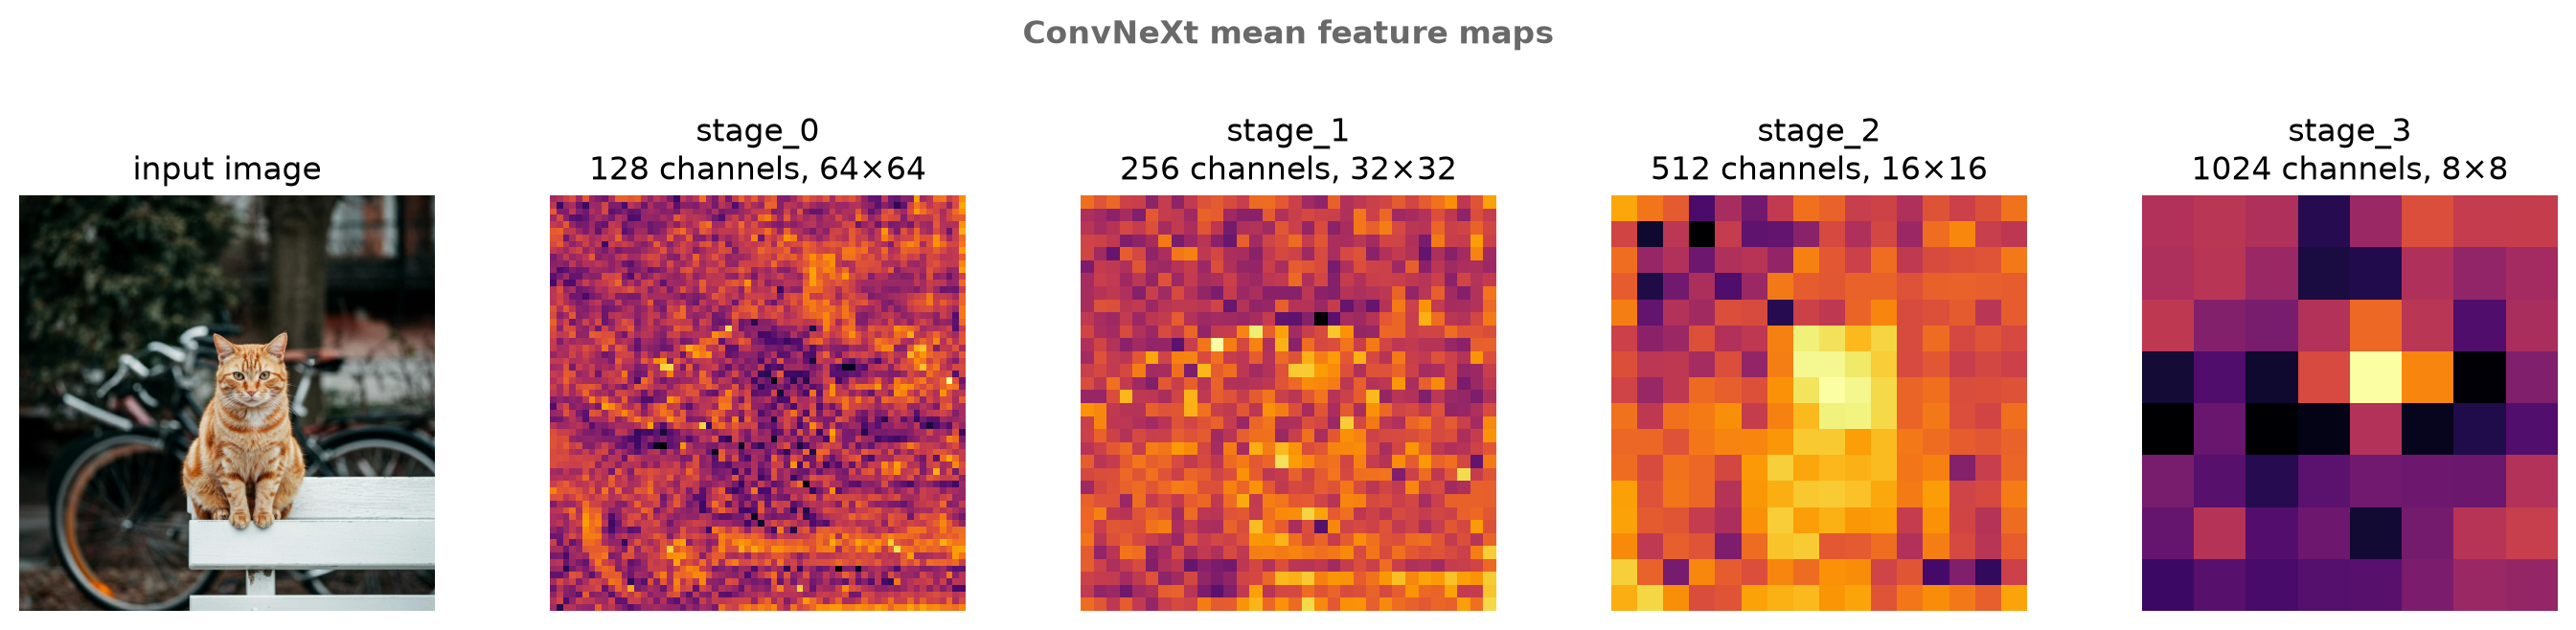

In [91]:
# визуализируем feature maps, усредненные по каналам сверточных слоев

fig, axes = plt.subplots(1, len(feature_maps) + 1, figsize=(14, 3))

axes[0].imshow(image)
axes[0].set_title('input image')
axes[0].axis('off')

for ax, (name, feature_map) in zip(axes[1:], feature_maps.items()):
    fmap = feature_map[0].mean(axis=0).numpy()
    channels, height, width = feature_map.shape[1:]

    ax.imshow(fmap, cmap='inferno')
    ax.set_title(f'{name}\n{channels} channels, {height}×{width}')
    ax.axis('off')

plt.suptitle('ConvNeXt mean feature maps', y=1.08, fontsize=12, fontweight='bold', color='dimgrey')
plt.tight_layout()
plt.show()

По мере прохождения через ConvNeXt пространственное разрешение уменьшается (64×64 → 8×8), число каналов увеличивается (128 → 1024). На ранних этапах сеть реагирует на локальные текстуры и границы, на поздних концентрируется на наиболее информативных областях изображения. Карты полученны усреднением активаций по всем каналам каждого stage.

- **Stage 0** (128×64×64): модель еще почти не выделяет объекты. Активность распределена почти по всему изображению, кошка еще не отделена от фона.
- **Stage 1** (256×32×32): начинают проявляться более крупные структуры. Кошка становится заметнее, фон постепенно теряет детализацию.
- **Stage 2** (512×16×16): основная активность уже сосредоточена на главном объекте.
- **Stage 3** (1024×8×8): карта очень грубая пространственно (всего 8×8 клетки), зато содержит 1024 канала. Она уже не хранит детали изображения, а показывает, где расположены наиболее важные области для формирования итогового embedding.
<br>

first conv: stem.0 torch.Size([128, 3, 4, 4])


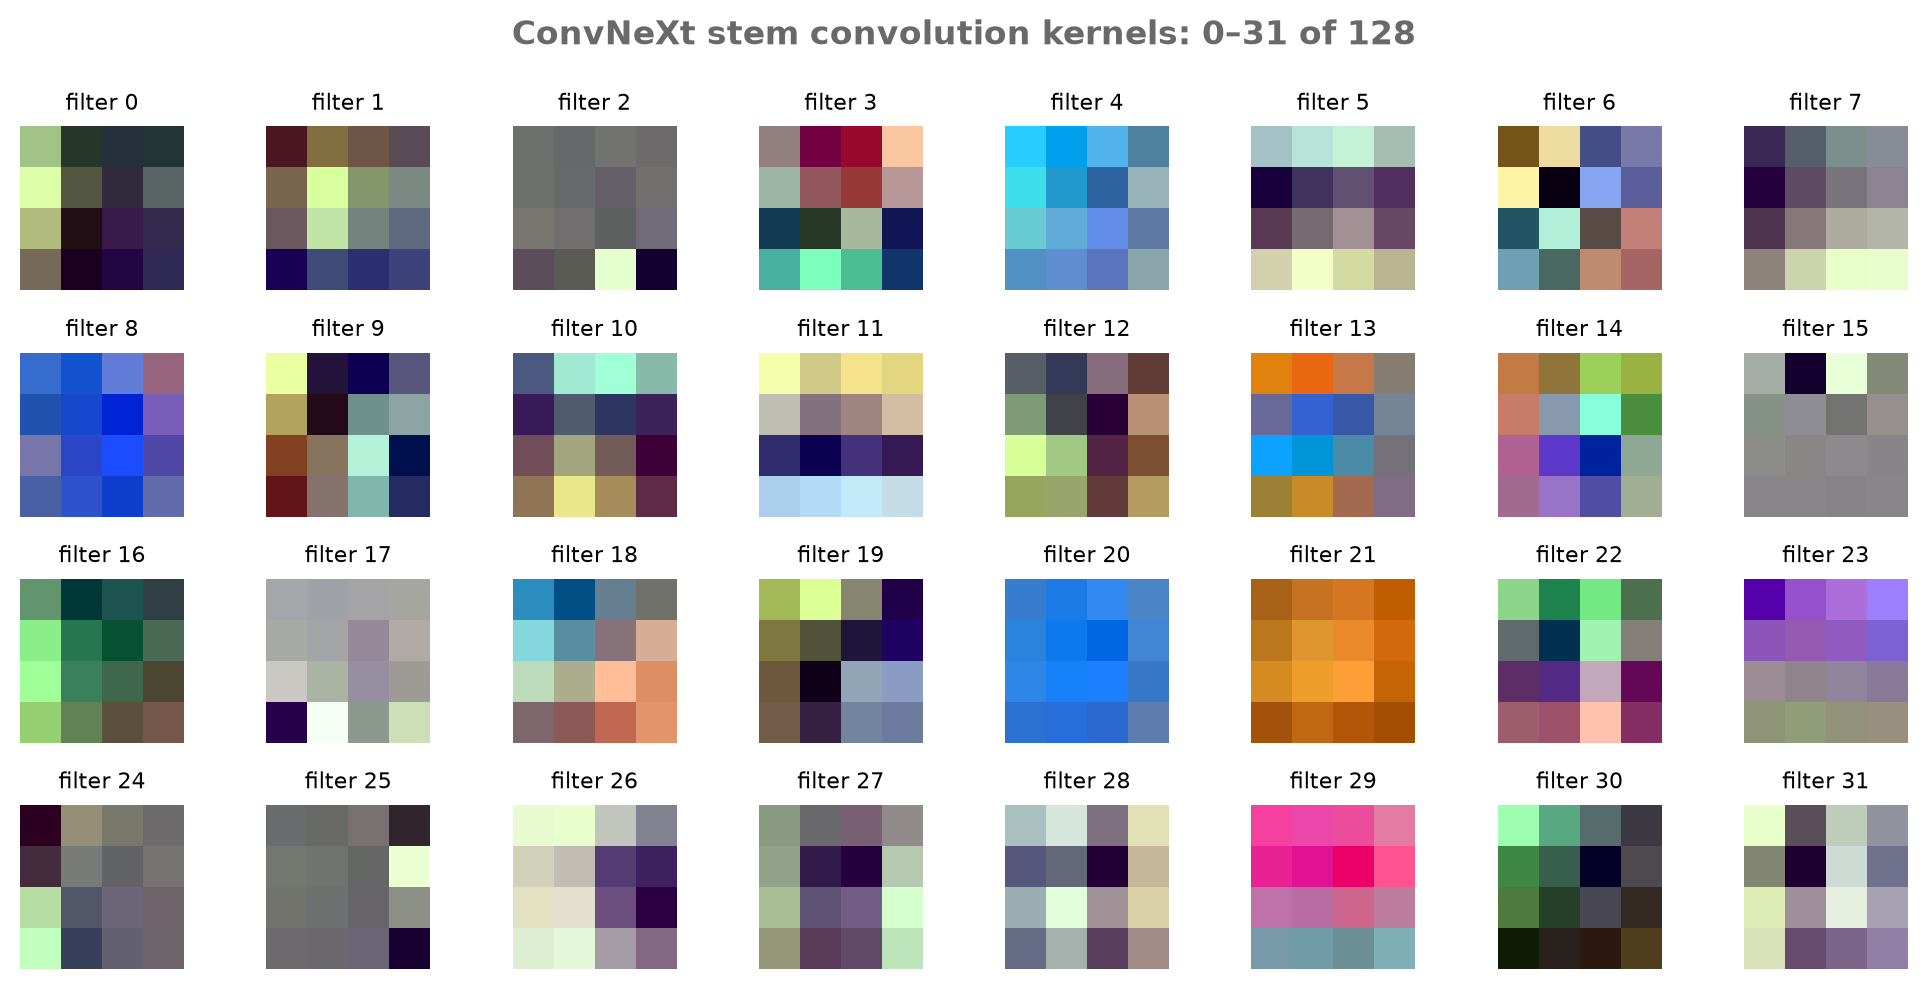

In [92]:
# визуализируем первые convolution kernels stem

first_conv = None

for name, module in convnext_encoder.visual.trunk.named_modules():
    if isinstance(module, nn.Conv2d):
        first_conv = module
        print('first conv:', name, module.weight.shape)
        break

weights = first_conv.weight.detach().cpu()
n_filters = min(32, weights.shape[0])

fig, axes = plt.subplots(4, 8, figsize=(10, 5))

for ax, idx in zip(axes.ravel(), range(n_filters)):
    kernel = weights[idx]
    kernel_img = kernel.permute(1, 2, 0).numpy()
    kernel_img = (kernel_img - kernel_img.min()) / (kernel_img.max() - kernel_img.min() + 1e-9)

    ax.imshow(kernel_img)

    ax.set_title(f'filter {idx}', fontsize=8)
    ax.axis('off')

plt.suptitle(f'ConvNeXt stem convolution kernels: 0–{n_filters - 1} of {weights.shape[0]}',
    fontsize=12, fontweight='bold', color='dimgrey')

plt.tight_layout()
plt.show()

**Веса первых 32 из 128 фильтров первого сверточного слоя (stem).**     
torch.Size([128, 3, 4, 4]): 128 фильтров, каждый принимает 3 RGB-канала, размер ядра 4×4.
Они преобразуют исходное изображение в 128 карт признаков размером 64×64, которые становятся входом для последующих блоков ConvNeXt. Эти фильтры фиксированы и одинаковы для любого изображения. Каждый фильтр содержит отдельные веса для каналов RGB, поэтому при визуализации они выглядят разноцветными и могут по-разному реагировать на различные сочетания цветов, границ и текстур.

---

### Embeddings


In [93]:
# функция расчета OpenCLIP embeddings

def extract_convnext_embeddings(images, batch_size=32):
    embeddings = []

    for start in tqdm(range(0, len(images), batch_size)):
        batch_bytes = images[start:start + batch_size]
        batch_images = [convnext_preprocess(decode_image(image_bytes)) for image_bytes in batch_bytes]
        inputs = torch.stack(batch_images).to(DEVICE)

        with torch.no_grad():
            batch_embeddings = convnext_encoder.encode_image(inputs)
            batch_embeddings = batch_embeddings / batch_embeddings.norm(dim=1, keepdim=True)

        embeddings.append(batch_embeddings.cpu().numpy().astype('float32'))

    return np.vstack(embeddings)

In [94]:
# embeddings для train image_1/image_2
convnext_train_emb = {}

for image_name, suffix in [('image_1', 'emb_1'), ('image_2', 'emb_2')]:
    convnext_train_emb[image_name] = get_cached_embeddings(
        ARTEFACTS_DIR / f'{CONVNEXT_NAME}_train_{suffix}.npy',
        train[image_name],
        extract_convnext_embeddings
    )

# embeddings для test image_1/image_2
convnext_test_emb = {}

for image_name, suffix in [('image_1', 'emb_1'), ('image_2', 'emb_2')]:
    convnext_test_emb[image_name] = get_cached_embeddings(
        ARTEFACTS_DIR / f'{CONVNEXT_NAME}_test_{suffix}.npy',
        test[image_name],
        extract_convnext_embeddings
    )

loading embeddings: artefacts/convnext-base_train_emb_1.npy
embeddings shape: (8710, 640)
loading embeddings: artefacts/convnext-base_train_emb_2.npy
embeddings shape: (8710, 640)
loading embeddings: artefacts/convnext-base_test_emb_1.npy
embeddings shape: (4290, 640)
loading embeddings: artefacts/convnext-base_test_emb_2.npy
embeddings shape: (4290, 640)


---

### Pair features


Ожидаемый размер матриц после добавления pair features:

5 feature blocks * 640 = **3200**

In [95]:
# матрицы pair features для ConvNeXt CatBoost

X_convnext = pair_embedding_features(
    convnext_train_emb['image_1'],
    convnext_train_emb['image_2']
)

X_convnext_test = pair_embedding_features(
    convnext_test_emb['image_1'],
    convnext_test_emb['image_2']
)

print(f'X_convnext shape:      {X_convnext.shape}')
print(f'X_convnext_test shape: {X_convnext_test.shape}')


X_convnext shape:      (8710, 3200)
X_convnext_test shape: (4290, 3200)


---

### CatBoost Classifier


In [96]:
cb_convnext_params = {
    'iterations': 700,
    'depth': 5,
    'l2_leaf_reg': 5,
}


In [97]:
print(f'=== CatBoost seed ensemble | {CONVNEXT_NAME} ===')

convnext_catboost_oof_path = ARTEFACTS_DIR / f'{CONVNEXT_NAME}_catboost_oof_pred.npy'
convnext_catboost_test_path = ARTEFACTS_DIR / f'{CONVNEXT_NAME}_catboost_test_pred.npy'

# если артефакты существуют и CB_RETRAIN = False: загружаем артефакты
if convnext_catboost_oof_path.exists() and convnext_catboost_test_path.exists() and not CB_RETRAIN:
    convnext_catboost_oof_pred = np.load(convnext_catboost_oof_path)
    convnext_catboost_test_pred = np.load(convnext_catboost_test_path)
    print()
    print(f'oof loaded: {convnext_catboost_oof_path}; shape={convnext_catboost_oof_pred.shape}')
    print(f'test loaded: {convnext_catboost_test_path}; shape={convnext_catboost_test_pred.shape}')

# иначе - переобучение CatBoost Classifier seed ensemble
else:
    print(f'params={cb_convnext_params}')
    print(f'split seed: {SEED}; model seeds={seeds_11}\n')

    convnext_catboost_seed_oof_preds = []
    convnext_catboost_seed_test_preds = []

    # запускаем функцию обучения run_catboost_cv 
    for model_seed in seeds_11:
        print(f'seed={model_seed}')
        seed_oof_pred, seed_test_pred, seed_cv_auc = run_catboost_cv(
            X_convnext,
            X_convnext_test,
            target,
            cb_convnext_params,
            seed=model_seed,
            split_seed=SEED
        )
        print(f'CV ROC AUC: {seed_cv_auc:.6f}\n')

        convnext_catboost_seed_oof_preds.append(seed_oof_pred)
        convnext_catboost_seed_test_preds.append(seed_test_pred)

    # усредняем предсказания по фолдам
    convnext_catboost_oof_pred = np.mean(convnext_catboost_seed_oof_preds, axis=0)
    convnext_catboost_test_pred = np.mean(convnext_catboost_seed_test_preds, axis=0)

    # сохранение артефактов модели
    np.save(convnext_catboost_oof_path, convnext_catboost_oof_pred)
    np.save(convnext_catboost_test_path, convnext_catboost_test_pred)

    print(f'saved oof predictions:  {convnext_catboost_oof_path};  '
          f'shape={convnext_catboost_oof_pred.shape}')
    print(f'saved test predictions: {convnext_catboost_test_path}; '
          f'shape={convnext_catboost_test_pred.shape}')

convnext_catboost_cv_auc = roc_auc_score(target, convnext_catboost_oof_pred)
print(f'CV ROC AUC: {roc_auc_score(target, convnext_catboost_oof_pred):.6f}\n')


=== CatBoost seed ensemble | convnext-base ===

oof loaded: artefacts/convnext-base_catboost_oof_pred.npy; shape=(8710,)
test loaded: artefacts/convnext-base_catboost_test_pred.npy; shape=(4290,)
CV ROC AUC: 0.663945



<div style="font-size:14px; font-weight:700; margin-bottom:6px;">Model training log</div>

<pre style="
  background:#fcfcfc; border:1px solid #d1d5db; border-radius:6px; padding:12px 14px;
  font-size:11px; line-height:1.45; overflow-x:auto; white-space:pre; text-align:left;
  display:block; width:99%; max-width:100%; box-sizing:border-box; margin:0 0 16px 0;
">=== CatBoost seed ensemble | convnext-base ===

seed=42 | folds=[0.654387 0.652935 0.662294 0.658770 0.658889] | best_iter=[242 481 418 369 699] | CV AUC=0.656163
seed=43 | folds=[0.657600 0.653346 0.653620 0.659451 0.653684] | best_iter=[364 601 232 305 236] | CV AUC=0.654230
seed=44 | folds=[0.655200 0.659369 0.649635 0.662173 0.652786] | best_iter=[580 240 340 626 607] | CV AUC=0.654088
seed=45 | folds=[0.655688 0.652513 0.657804 0.655956 0.652261] | best_iter=[508 232 385 358 684] | CV AUC=0.653050
seed=46 | folds=[0.644949 0.657776 0.661243 0.663216 0.649122] | best_iter=[536 326 665 420 677] | CV AUC=0.653572
seed=47 | folds=[0.646112 0.657751 0.656202 0.664293 0.669338] | best_iter=[334 483  95 609 697] | CV AUC=0.652871
seed=48 | folds=[0.655698 0.654816 0.661581 0.661786 0.657884] | best_iter=[624 680 379 605 298] | CV AUC=0.657164
seed=49 | folds=[0.657651 0.655062 0.654142 0.658722 0.652385] | best_iter=[549 352 343 483 698] | CV AUC=0.654413
seed=50 | folds=[0.655666 0.653633 0.654570 0.665326 0.655885] | best_iter=[699 379 331 440 404] | CV AUC=0.656090
seed=51 | folds=[0.654146 0.660232 0.660123 0.667204 0.652527] | best_iter=[508 122 510 341 335] | CV AUC=0.654378
seed=52 | folds=[0.656438 0.660664 0.661177 0.657576 0.649175] | best_iter=[430 545 460 379 421] | CV AUC=0.657017

seed ensemble OOF ROC AUC=0.663945</pre>

In [98]:
model_scores_df = update_model_score(
    model_scores_df,
    encoder='OpenCLIP ConvNeXt',
    model='CatBoost',
    n_seeds=len(seeds_11),
    oof_roc_auc=convnext_catboost_cv_auc
)

model_scores_df.style.background_gradient('Blues', subset='oof_roc_auc')

,encoder,model,n_seeds,oof_roc_auc
0,CLIP ViT Base,CatBoost,11,0.658693
1,CLIP ViT Base,Siamese,11,0.658450
2,CLIP ViT Large,CatBoost,11,0.657851
3,CLIP ViT Large,Siamese,11,0.654819
4,SigLIP 256,CatBoost,11,0.667187
5,SigLIP 256,Siamese,11,0.660901
6,SigLIP 384,CatBoost,11,0.666871
7,OpenCLIP ConvNeXt,CatBoost,11,0.663945


<div style="
    background: #f3f4f6;
    border-radius: 6px;
    margin-top:20px;
    height: 30px;
"></div>

## EVA-CLIP Base

**Encoder:** `EVA02-B-16`  
**Pretrained weights:** `merged2b_s8b_b131k`  
**Source:** open_clip  
**Backbone:** EVA-CLIP Base, ViT-B/16  
**Patch size:** 16×16  
**Models:** CatBoost


EVA-CLIP сохраняет архитектуру Vision Transformer, но использует модель EVA-02, которая была предварительно обучена на значительно большем объеме изображений, а затем дообучена по схеме CLIP.

### Encoder setup


In [99]:
EVA_B_MODEL_NAME = 'EVA02-B-16'
EVA_B_PRETRAINED = 'merged2b_s8b_b131k'
EVA_B_NAME = 'eva-b'

EVA_B_BATCH_SIZE = 32

In [100]:
eva_b_encoder, _, eva_b_preprocess = open_clip.create_model_and_transforms(
    EVA_B_MODEL_NAME,
    pretrained=EVA_B_PRETRAINED,
    device=DEVICE
)
eva_b_encoder.eval();

print('encoder loaded')

encoder loaded


In [101]:
print(f'\n=== {EVA_B_MODEL_NAME} / {EVA_B_PRETRAINED} ===\n')

pre = eva_b_preprocess
visual = eva_b_encoder.visual
trunk = eva_b_encoder.visual.trunk

print(f'image processor type: {pre.__class__.__name__}')
print(f'size:                 {pre.transforms[0].size}; center_crop={pre.transforms[1].size}\n')

print(f'visual encoder:       {visual.__class__.__name__}({trunk.__class__.__name__})')
print(f'patch embedding:      {trunk.patch_embed.proj}')

print(
    f'ViT tokens:           '
    f'({trunk.patch_embed.num_patches} patch tokens + '
    f'{trunk.cls_token.shape[1]} CLS token) × '
    f'{trunk.patch_embed.proj.out_channels}'
)

print(f'position encoding:    {trunk.rope.__class__.__name__} (RoPE)')

block = trunk.blocks[0]
print(
    f'transformer blocks:   {len(trunk.blocks)} × '
    f'[{block.attn.num_heads}-head {block.attn.__class__.__name__} | '
    f'{block.mlp.__class__.__name__} {block.mlp.fc1_g.in_features} → '
    f'2 × {block.mlp.fc1_g.out_features} → {block.mlp.fc2.out_features} | '
    f'{block.mlp.act.__class__.__name__}]'
)

print(f'visual projection:    {trunk.head.__class__.__name__}'
      f'({trunk.head.in_features} → {trunk.head.out_features})')
print()


=== EVA02-B-16 / merged2b_s8b_b131k ===

image processor type: Compose
size:                 224; center_crop=(224, 224)

visual encoder:       TimmModel(Eva)
patch embedding:      Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
ViT tokens:           (196 patch tokens + 1 CLS token) × 768
position encoding:    RotaryEmbeddingCat (RoPE)
transformer blocks:   12 × [12-head EvaAttention | SwiGLU 768 → 2 × 2048 → 768 | SiLU]
visual projection:    Linear(768 → 512)



Каркас модели **EVA02-B-16** почти одинаковый с CLIP ViT-B/16:   
входное изображение 224 × 224   
→ (196 patch embeddings + 1 CLS токен) × 768     
→ 12 transformer blocks по 12 heads    
→ CLS representation   
→ visual projection: Linear 768 → 512   

Различается внутреннее устройство блоков.  

Во-первых, CLIP ViT добавляет к токенам обучаемые positional embeddings, а EVA использует RoPE внутри attention: позиционная информация добавляется через поворот query- и key-векторов.

Во-вторых, обычная MLP заменена на SwiGLU. Вместо схемы Linear → activation → Linear используются две ветки, одна из которых управляет второй.

В-третьих, вместо стандартного CLIPAttention используется EvaAttention с RoPE и дополнительной нормализацией.

---

### Embeddings


In [102]:
# функция расчета EVA-B embeddings

def extract_eva_b_embeddings(images, batch_size=EVA_B_BATCH_SIZE):
    embeddings = []

    for start in tqdm(range(0, len(images), batch_size)):
        batch_bytes = images[start:start + batch_size]
        batch_images = [eva_b_preprocess(decode_image(image_bytes)) for image_bytes in batch_bytes]
        inputs = torch.stack(batch_images).to(DEVICE)

        with torch.no_grad():
            batch_embeddings = eva_b_encoder.encode_image(inputs)
            batch_embeddings = batch_embeddings / batch_embeddings.norm(dim=1, keepdim=True)

        embeddings.append(batch_embeddings.cpu().numpy().astype('float32'))

    return np.vstack(embeddings)

In [103]:
# embeddings для train image_1/image_2
eva_b_train_emb = {}

for image_name, suffix in [('image_1', 'emb_1'), ('image_2', 'emb_2')]:
    eva_b_train_emb[image_name] = get_cached_embeddings(
        ARTEFACTS_DIR / f'{EVA_B_NAME}_train_{suffix}.npy',
        train[image_name],
        extract_eva_b_embeddings
    )

# embeddings для test image_1/image_2
eva_b_test_emb = {}

for image_name, suffix in [('image_1', 'emb_1'), ('image_2', 'emb_2')]:
    eva_b_test_emb[image_name] = get_cached_embeddings(
        ARTEFACTS_DIR / f'{EVA_B_NAME}_test_{suffix}.npy',
        test[image_name],
        extract_eva_b_embeddings
    )

loading embeddings: artefacts/eva-b_train_emb_1.npy
embeddings shape: (8710, 512)
loading embeddings: artefacts/eva-b_train_emb_2.npy
embeddings shape: (8710, 512)
loading embeddings: artefacts/eva-b_test_emb_1.npy
embeddings shape: (4290, 512)
loading embeddings: artefacts/eva-b_test_emb_2.npy
embeddings shape: (4290, 512)


---

### Pair features


Ожидаемый размер матриц после добавления pair features:

5 feature blocks * 512 = **2560**

In [104]:
# матрицы pair features для EVA-B CatBoost

X_eva_b = pair_embedding_features(
    eva_b_train_emb['image_1'],
    eva_b_train_emb['image_2']
)

X_eva_b_test = pair_embedding_features(
    eva_b_test_emb['image_1'],
    eva_b_test_emb['image_2']
)

print(f'X_eva_b shape:      {X_eva_b.shape}')
print(f'X_eva_b_test shape: {X_eva_b_test.shape}')


X_eva_b shape:      (8710, 2560)
X_eva_b_test shape: (4290, 2560)


---

### CatBoost Classifier


In [105]:
cb_eva_b_params = {
    'iterations': 700,
    'depth': 5,
    'l2_leaf_reg': 5,
}

In [106]:
print(f'=== CatBoost seed ensemble | {EVA_B_NAME} ===\n')

eva_b_catboost_oof_path = ARTEFACTS_DIR / f'{EVA_B_NAME}_catboost_oof_pred.npy'
eva_b_catboost_test_path = ARTEFACTS_DIR / f'{EVA_B_NAME}_catboost_test_pred.npy'

# если артефакты существуют и CB_RETRAIN = False: загружаем артефакты
if eva_b_catboost_oof_path.exists() and eva_b_catboost_test_path.exists() and not CB_RETRAIN:
    eva_b_catboost_oof_pred = np.load(eva_b_catboost_oof_path)
    eva_b_catboost_test_pred = np.load(eva_b_catboost_test_path)

    print(f'oof loaded:  {eva_b_catboost_oof_path};  shape={eva_b_catboost_oof_pred.shape}')
    print(f'test loaded: {eva_b_catboost_test_path}; shape={eva_b_catboost_test_pred.shape}')

# иначе - переобучение CatBoost Classifier seed ensemble
else:
    print(f'params={cb_eva_b_params}')
    print(f'split seed: {SEED}; model seeds={seeds_11}\n')

    eva_b_catboost_seed_oof_preds = []
    eva_b_catboost_seed_test_preds = []

    # запускаем функцию обучения run_catboost_cv
    for model_seed in seeds_11:
        print(f'seed={model_seed}')
        seed_oof_pred, seed_test_pred, seed_cv_auc = run_catboost_cv(
            X_eva_b,
            X_eva_b_test,
            target,
            cb_eva_b_params,
            seed=model_seed,
            split_seed=SEED
        )
        print(f'CV ROC AUC: {seed_cv_auc:.6f}\n')

        eva_b_catboost_seed_oof_preds.append(seed_oof_pred)
        eva_b_catboost_seed_test_preds.append(seed_test_pred)

    # усредняем предсказания по seeds
    eva_b_catboost_oof_pred = np.mean(eva_b_catboost_seed_oof_preds, axis=0)
    eva_b_catboost_test_pred = np.mean(eva_b_catboost_seed_test_preds, axis=0)

    # сохранение артефактов модели
    np.save(eva_b_catboost_oof_path, eva_b_catboost_oof_pred)
    np.save(eva_b_catboost_test_path, eva_b_catboost_test_pred)

    print(f'saved oof predictions:  {eva_b_catboost_oof_path};  '
          f'shape={eva_b_catboost_oof_pred.shape}')
    print(f'saved test predictions: {eva_b_catboost_test_path}; '
          f'shape={eva_b_catboost_test_pred.shape}')

eva_b_catboost_cv_auc = roc_auc_score(target, eva_b_catboost_oof_pred)

print(f'CV ROC AUC: {eva_b_catboost_cv_auc:.6f}')

=== CatBoost seed ensemble | eva-b ===

oof loaded:  artefacts/eva-b_catboost_oof_pred.npy;  shape=(8710,)
test loaded: artefacts/eva-b_catboost_test_pred.npy; shape=(4290,)
CV ROC AUC: 0.663183


<div style="font-size:14px; font-weight:700; margin-bottom:6px;">Model training log</div>

<pre style="
  background:#fcfcfc; border:1px solid #d1d5db; border-radius:6px; padding:12px 14px;
  font-size:11px; line-height:1.45; overflow-x:auto; white-space:pre; text-align:left;
  display:block; width:99%; max-width:100%; box-sizing:border-box; margin:0 0 16px 0;
">=== CatBoost seed ensemble | eva-b ===

params={'iterations': 700, 'depth': 5, 'l2_leaf_reg': 5}
split seed: 42; model seeds=[42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52]

seed=42 | folds=[0.650724 0.654247 0.633329 0.652696 0.666232] | best iterations=[576 475 699 697 521] | CV AUC=0.650582
seed=43 | folds=[0.646519 0.659270 0.638943 0.660862 0.666269] | best iterations=[295 410 488 682 650] | CV AUC=0.653518
seed=44 | folds=[0.647475 0.655576 0.642025 0.664994 0.667588] | best iterations=[587 651 644 423 690] | CV AUC=0.654775
seed=45 | folds=[0.653807 0.657524 0.640068 0.667387 0.664501] | best iterations=[427 214 686 519 666] | CV AUC=0.654076
seed=46 | folds=[0.651151 0.665854 0.637593 0.663183 0.663404] | best iterations=[329 546 549 662 629] | CV AUC=0.655407
seed=47 | folds=[0.659638 0.661032 0.643557 0.665850 0.671989] | best iterations=[649 356 507 649 667] | CV AUC=0.659489
seed=48 | folds=[0.658726 0.666800 0.644946 0.662799 0.660392] | best iterations=[688 422 635 633 620] | CV AUC=0.657643
seed=49 | folds=[0.656671 0.666267 0.652389 0.660096 0.654796] | best iterations=[471 304 639 543 440] | CV AUC=0.656797
seed=50 | folds=[0.656969 0.662096 0.638814 0.657520 0.666848] | best iterations=[439 464 699 541 698] | CV AUC=0.655860
seed=51 | folds=[0.655854 0.656063 0.649884 0.668499 0.666210] | best iterations=[442 364 570 651 525] | CV AUC=0.658743
seed=52 | folds=[0.658309 0.657142 0.641182 0.661348 0.666965] | best iterations=[691 457 688 529 629] | CV AUC=0.656457

seed ensemble OOF ROC AUC=0.663183</pre>

In [107]:
model_scores_df = update_model_score(
    model_scores_df,
    encoder='EVA-CLIP Base',
    model='CatBoost',
    n_seeds=len(seeds_11),
    oof_roc_auc=eva_b_catboost_cv_auc
)

model_scores_df.style.background_gradient('Blues', subset='oof_roc_auc')

,encoder,model,n_seeds,oof_roc_auc
0,CLIP ViT Base,CatBoost,11,0.658693
1,CLIP ViT Base,Siamese,11,0.658450
2,CLIP ViT Large,CatBoost,11,0.657851
3,CLIP ViT Large,Siamese,11,0.654819
4,SigLIP 256,CatBoost,11,0.667187
5,SigLIP 256,Siamese,11,0.660901
6,SigLIP 384,CatBoost,11,0.666871
7,OpenCLIP ConvNeXt,CatBoost,11,0.663945
8,EVA-CLIP Base,CatBoost,11,0.663183


<div style="
    background: #f3f4f6;
    border-radius: 6px;
    margin-top:20px;
    height: 30px;
"></div>

## EVA-CLIP Large

**Encoder:** `EVA02-L-14`  
**Pretrained weights:** `merged2b_s4b_b131k`  
**Source:** open_clip  
**Backbone:** EVA-CLIP Large, ViT-L/14  
**Patch size:** 14×14  
**Models:** CatBoost


### Encoder setup


In [108]:
EVA_L_MODEL_NAME = 'EVA02-L-14'
EVA_L_PRETRAINED = 'merged2b_s4b_b131k'
EVA_L_NAME = 'eva-l'

EVA_L_BATCH_SIZE = 16

In [109]:
eva_l_encoder, _, eva_l_preprocess = open_clip.create_model_and_transforms(
    EVA_L_MODEL_NAME,
    pretrained=EVA_L_PRETRAINED,
    device=DEVICE
)
eva_l_encoder.eval();
print('encoder loaded')

encoder loaded


In [110]:
print(f'=== {EVA_L_MODEL_NAME} ===\n')

pre = eva_l_preprocess
visual = eva_l_encoder.visual
trunk = eva_l_encoder.visual.trunk

print(f'image processor type: {pre.__class__.__name__}')
print(f'size:                 {pre.transforms[0].size}; center_crop={pre.transforms[1].size}\n')

print(f'visual encoder:       {visual.__class__.__name__}({trunk.__class__.__name__})')
print(f'patch embedding:      {trunk.patch_embed.proj}')

print(
    f'ViT tokens:           '
    f'({trunk.patch_embed.num_patches} patch tokens + '
    f'{trunk.cls_token.shape[1]} CLS token) × '
    f'{trunk.patch_embed.proj.out_channels}'
)

print(f'position encoding:    {trunk.rope.__class__.__name__} (RoPE)')

block = trunk.blocks[0]
print(
    f'transformer blocks:   {len(trunk.blocks)} × '
    f'[{block.attn.num_heads}-head {block.attn.__class__.__name__} | '
    f'{block.mlp.__class__.__name__} {block.mlp.fc1_g.in_features} → '
    f'2 × {block.mlp.fc1_g.out_features} → {block.mlp.fc2.out_features} | '
    f'{block.mlp.act.__class__.__name__}]'
)

print(f'visual projection:    {trunk.head.__class__.__name__}'
      f'({trunk.head.in_features} → {trunk.head.out_features})')
print()

=== EVA02-L-14 ===

image processor type: Compose
size:                 224; center_crop=(224, 224)

visual encoder:       TimmModel(Eva)
patch embedding:      Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14))
ViT tokens:           (256 patch tokens + 1 CLS token) × 1024
position encoding:    RotaryEmbeddingCat (RoPE)
transformer blocks:   24 × [16-head EvaAttention | SwiGLU 1024 → 2 × 2730 → 1024 | SiLU]
visual projection:    Linear(1024 → 768)



**EVA02-L-14** сохраняет общий каркас EVA02-B-16, но использует меньшие патчи, больше токенов, вдвое больше трансформер-блоков и более широкие представления. Поэтому она может извлекать более подробные и сложные признаки.

---

### Embeddings


In [111]:
# функция расчета EVA-L embeddings

def extract_eva_l_embeddings(images, batch_size=EVA_L_BATCH_SIZE):
    embeddings = []

    for start in tqdm(range(0, len(images), batch_size)):
        batch_bytes = images[start:start + batch_size]
        batch_images = [eva_l_preprocess(decode_image(image_bytes)) for image_bytes in batch_bytes]
        inputs = torch.stack(batch_images).to(DEVICE)

        with torch.no_grad():
            batch_embeddings = eva_l_encoder.encode_image(inputs)
            batch_embeddings = batch_embeddings / batch_embeddings.norm(dim=1, keepdim=True)

        embeddings.append(batch_embeddings.cpu().numpy().astype('float32'))

    return np.vstack(embeddings)

In [112]:
# embeddings для train image_1/image_2
eva_l_train_emb = {}

for image_name, suffix in [('image_1', 'emb_1'), ('image_2', 'emb_2')]:
    eva_l_train_emb[image_name] = get_cached_embeddings(
        ARTEFACTS_DIR / f'{EVA_L_NAME}_train_{suffix}.npy',
        train[image_name],
        extract_eva_l_embeddings
    )

# embeddings для test image_1/image_2
eva_l_test_emb = {}

for image_name, suffix in [('image_1', 'emb_1'), ('image_2', 'emb_2')]:
    eva_l_test_emb[image_name] = get_cached_embeddings(
        ARTEFACTS_DIR / f'{EVA_L_NAME}_test_{suffix}.npy',
        test[image_name],
        extract_eva_l_embeddings
    )

loading embeddings: artefacts/eva-l_train_emb_1.npy
embeddings shape: (8710, 768)
loading embeddings: artefacts/eva-l_train_emb_2.npy
embeddings shape: (8710, 768)
loading embeddings: artefacts/eva-l_test_emb_1.npy
embeddings shape: (4290, 768)
loading embeddings: artefacts/eva-l_test_emb_2.npy
embeddings shape: (4290, 768)


---

### Pair features


Ожидаемый размер матриц после добавления pair features:

5 feature blocks * 768 = **3840**


In [113]:
# матрицы pair features для EVA-L CatBoost

X_eva_l = pair_embedding_features(
    eva_l_train_emb['image_1'],
    eva_l_train_emb['image_2']
)

X_eva_l_test = pair_embedding_features(
    eva_l_test_emb['image_1'],
    eva_l_test_emb['image_2']
)

print(f'X_eva_l shape:      {X_eva_l.shape}')
print(f'X_eva_l_test shape: {X_eva_l_test.shape}')


X_eva_l shape:      (8710, 3840)
X_eva_l_test shape: (4290, 3840)


---

### CatBoost Classifier


In [114]:
cb_eva_l_params = {
    'iterations': 700,
    'depth': 5,
    'l2_leaf_reg': 5,
}


In [115]:
print(f'=== CatBoost seed ensemble | {EVA_L_NAME} ===')

eva_l_catboost_oof_path = ARTEFACTS_DIR / f'{EVA_L_NAME}_catboost_oof_pred.npy'
eva_l_catboost_test_path = ARTEFACTS_DIR / f'{EVA_L_NAME}_catboost_test_pred.npy'

# если артефакты существуют и CB_RETRAIN = False: загружаем артефакты
if eva_l_catboost_oof_path.exists() and eva_l_catboost_test_path.exists() and not CB_RETRAIN:
    eva_l_catboost_oof_pred = np.load(eva_l_catboost_oof_path)
    eva_l_catboost_test_pred = np.load(eva_l_catboost_test_path)

    print()
    print(f'oof loaded:  {eva_l_catboost_oof_path};  shape={eva_l_catboost_oof_pred.shape}')
    print(f'test loaded: {eva_l_catboost_test_path}; shape={eva_l_catboost_test_pred.shape}')

# иначе - переобучение CatBoost seed ensemble
else:
    print()
    print(f'params={cb_eva_l_params}')
    print(f'split seed: {SEED}; model seeds={seeds_11}\n')

    eva_l_catboost_seed_oof_preds = []
    eva_l_catboost_seed_test_preds = []

    # cv обучение для каждого сида
    for model_seed in seeds_11:
        print(f'seed={model_seed}')

        seed_oof_pred, seed_test_pred, seed_cv_auc = run_catboost_cv(
            X_eva_l,
            X_eva_l_test,
            target,
            cb_eva_l_params,
            seed=model_seed,
            split_seed=SEED
        )

        print(f'CV ROC AUC: {seed_cv_auc:.6f}\n')

        eva_l_catboost_seed_oof_preds.append(seed_oof_pred)
        eva_l_catboost_seed_test_preds.append(seed_test_pred)

    # усредняем предсказания по seeds
    eva_l_catboost_oof_pred = np.mean(eva_l_catboost_seed_oof_preds, axis=0)
    eva_l_catboost_test_pred = np.mean(eva_l_catboost_seed_test_preds, axis=0)

    np.save(eva_l_catboost_oof_path, eva_l_catboost_oof_pred)
    np.save(eva_l_catboost_test_path, eva_l_catboost_test_pred)

    print(f'saved oof predictions:  {eva_l_catboost_oof_path};  '
          f'shape={eva_l_catboost_oof_pred.shape}')
    print(f'saved test predictions: {eva_l_catboost_test_path}; '
          f'shape={eva_l_catboost_test_pred.shape}')

eva_l_catboost_cv_auc = roc_auc_score(target, eva_l_catboost_oof_pred)

print(f'CV ROC AUC: {eva_l_catboost_cv_auc:.6f}')

=== CatBoost seed ensemble | eva-l ===

oof loaded:  artefacts/eva-l_catboost_oof_pred.npy;  shape=(8710,)
test loaded: artefacts/eva-l_catboost_test_pred.npy; shape=(4290,)
CV ROC AUC: 0.659781


<div style="font-size:14px; font-weight:700; margin-bottom:6px;">Model training log</div>

<pre style="
  background:#fcfcfc; border:1px solid #d1d5db; border-radius:6px; padding:12px 14px;
  font-size:11px; line-height:1.45; overflow-x:auto; white-space:pre; text-align:left;
  display:block; width:99%; max-width:100%; box-sizing:border-box; margin:0 0 16px 0;
">=== CatBoost seed ensemble | eva-l ===

params={'iterations': 700, 'depth': 5, 'l2_leaf_reg': 5}
split seed: 42; model seeds=[42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52]

seed=42 | folds=[0.637873 0.661439 0.655796 0.653450 0.646583] | best_iter=[352 404 582 431 383] | CV AUC=0.651103
seed=43 | folds=[0.643872 0.652195 0.654553 0.662922 0.650544] | best_iter=[524 673 433 569 654] | CV AUC=0.652159
seed=44 | folds=[0.642386 0.653519 0.657646 0.658476 0.653248] | best_iter=[310 451 608 689 673] | CV AUC=0.652377
seed=45 | folds=[0.643135 0.655378 0.655666 0.659252 0.645879] | best_iter=[223 268 599 362 383] | CV AUC=0.651079
seed=46 | folds=[0.647794 0.663708 0.652717 0.659156 0.650700] | best_iter=[684 588 464 453 312] | CV AUC=0.653667
seed=47 | folds=[0.649693 0.656361 0.642962 0.660666 0.651426] | best_iter=[327 425 699 583 667] | CV AUC=0.651080
seed=48 | folds=[0.648637 0.654830 0.649599 0.658158 0.655072] | best_iter=[531 498 397 680 387] | CV AUC=0.652621
seed=49 | folds=[0.649899 0.655967 0.653259 0.657462 0.654729] | best_iter=[699 343 437 552 675] | CV AUC=0.653039
seed=50 | folds=[0.641184 0.654795 0.646817 0.662834 0.650173] | best_iter=[677 547 369 692 687] | CV AUC=0.650389
seed=51 | folds=[0.648542 0.659383 0.664206 0.653888 0.653037] | best_iter=[311 390 425 593 321] | CV AUC=0.655133
seed=52 | folds=[0.647820 0.655163 0.645662 0.654861 0.658197] | best_iter=[516 120 400 308 447] | CV AUC=0.648433

seed ensemble OOF ROC AUC=0.659781</pre>

In [116]:
model_scores_df = update_model_score(
    model_scores_df,
    encoder='EVA-CLIP Large',
    model='CatBoost',
    n_seeds=len(seeds_11),
    oof_roc_auc=eva_l_catboost_cv_auc
)

model_scores_df.style.background_gradient('Blues', subset='oof_roc_auc')

,encoder,model,n_seeds,oof_roc_auc
0,CLIP ViT Base,CatBoost,11,0.658693
1,CLIP ViT Base,Siamese,11,0.658450
2,CLIP ViT Large,CatBoost,11,0.657851
3,CLIP ViT Large,Siamese,11,0.654819
4,SigLIP 256,CatBoost,11,0.667187
5,SigLIP 256,Siamese,11,0.660901
6,SigLIP 384,CatBoost,11,0.666871
7,OpenCLIP ConvNeXt,CatBoost,11,0.663945
8,EVA-CLIP Base,CatBoost,11,0.663183
9,EVA-CLIP Large,CatBoost,11,0.659781


Для одного и того же энкодера CatBoost дает в среднем чуть лучшее качество, у CLIP ViT Base разница между метриками Сatboost Classifier и Siamese Comparator минимальная, у CLIP ViT Large немного больше, и для SigLIP 256 CatBoost сработал уже заметно сильнее Siamese. Для остальных энкодеров Siamese не обучался.

---

## Weight stabilization

### OOF/test предсказания базовых моделей

In [117]:
base_oof_df = pd.DataFrame({
    'clip_base_catboost': clip_base_oof_pred,
    'clip_base_siamese': clip_base_siamese_oof_pred,
    'clip_large_catboost': clip_large_oof_pred,
    'clip_large_siamese': clip_large_siamese_oof_pred,
    'siglip_256_catboost': siglip_256_catboost_oof_pred,
    'siglip_256_siamese': siglip_256_siamese_oof_pred,
    'siglip_384_catboost': siglip_384_catboost_oof_pred,
    'convnext_catboost': convnext_catboost_oof_pred,
    'eva_b_catboost': eva_b_catboost_oof_pred,
    'eva_l_catboost': eva_l_catboost_oof_pred,
})

base_test_df = pd.DataFrame({
    'clip_base_catboost': clip_base_test_pred,
    'clip_base_siamese': clip_base_siamese_test_pred,
    'clip_large_catboost': clip_large_test_pred,
    'clip_large_siamese': clip_large_siamese_test_pred,
    'siglip_256_catboost': siglip_256_catboost_test_pred,
    'siglip_256_siamese': siglip_256_siamese_test_pred,
    'siglip_384_catboost': siglip_384_catboost_test_pred,
    'convnext_catboost': convnext_catboost_test_pred,
    'eva_b_catboost': eva_b_catboost_test_pred,
    'eva_l_catboost': eva_l_catboost_test_pred,
})

base_scores = pd.DataFrame({
    'model': base_oof_df.columns,
    'oof_roc_auc': [roc_auc_score(target, base_oof_df[col]) for col in base_oof_df.columns]
}).sort_values('oof_roc_auc', ascending=False)


# проверки размерностей базовых предсказаний
assert base_oof_df.shape[0] == len(target)
assert base_test_df.shape[0] == len(test)
assert base_oof_df.shape[1] == base_test_df.shape[1]
assert list(base_oof_df.columns) == list(base_test_df.columns)

assert not base_oof_df.isna().any().any()
assert not base_test_df.isna().any().any()

base_scores.style.background_gradient('Blues', subset='oof_roc_auc')

,model,oof_roc_auc
4,siglip_256_catboost,0.667187
6,siglip_384_catboost,0.666871
7,convnext_catboost,0.663945
8,eva_b_catboost,0.663183
5,siglip_256_siamese,0.660901
9,eva_l_catboost,0.659781
0,clip_base_catboost,0.658693
1,clip_base_siamese,0.658450
2,clip_large_catboost,0.657851
3,clip_large_siamese,0.654819


Более крупные версии энкодеров не дали прироста, SigLIP-384 практически повторил результат SigLIP-256, а EVA-L и CLIP Large показали AUC ниже базовых версий.
<br>

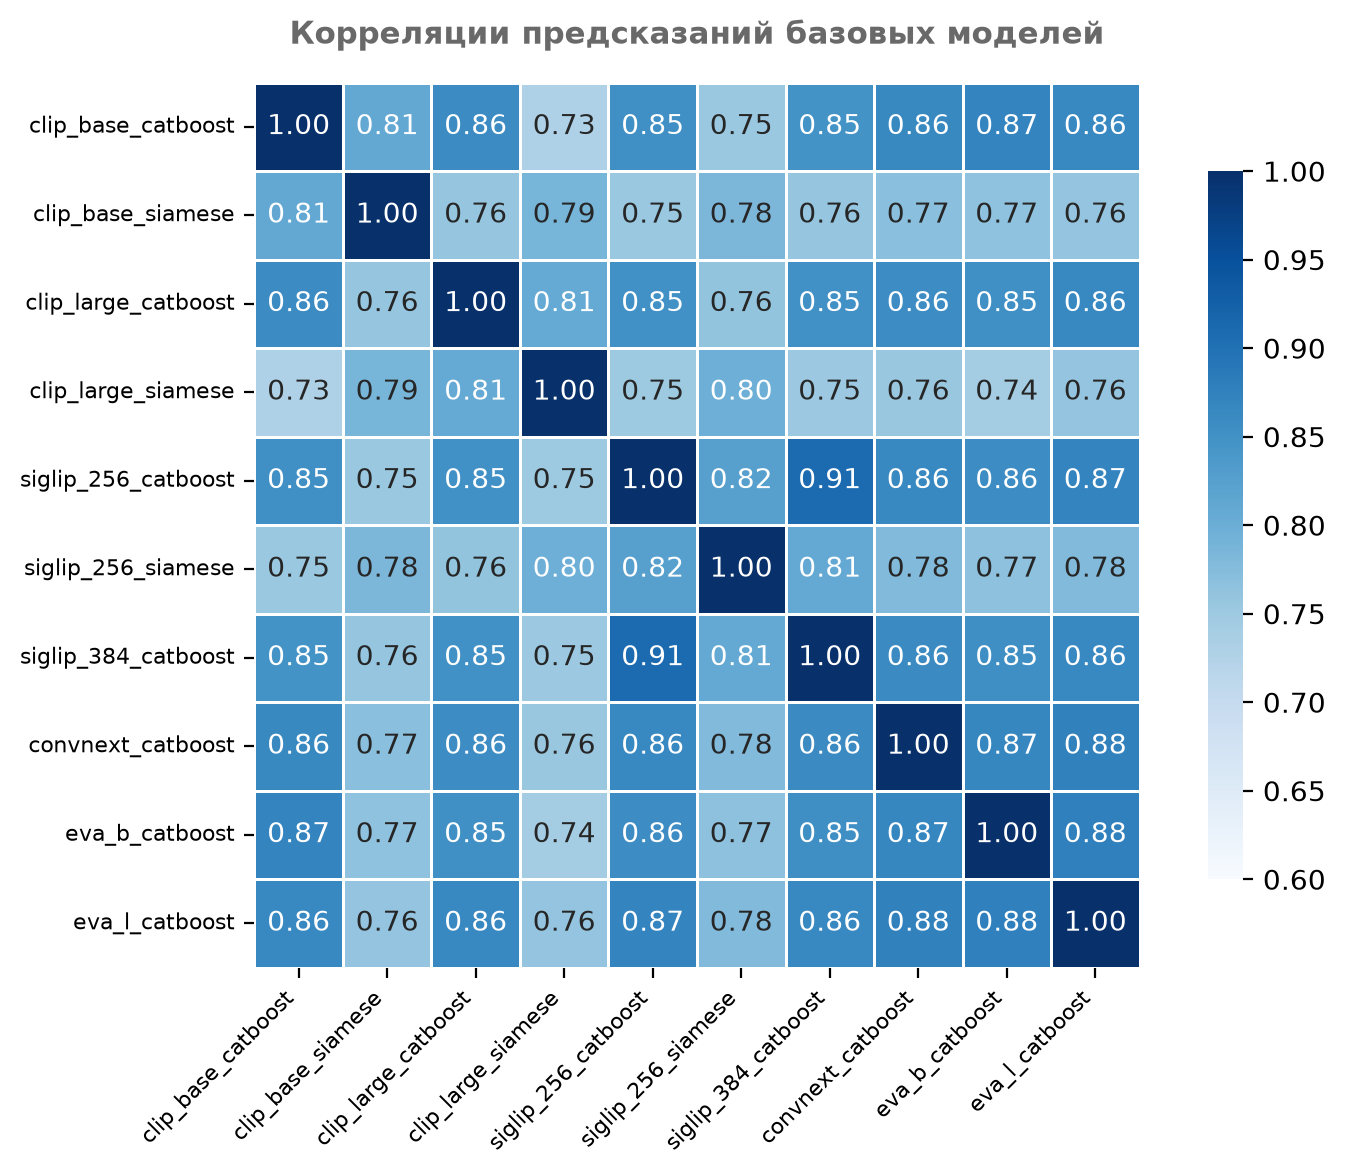

In [118]:
base_corr = base_oof_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    base_corr,
    cmap='Blues',
    vmin=0.6,
    vmax=1,
    annot=True,
    fmt='.2f',
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)

plt.title('Корреляции предсказаний базовых моделей', pad=14, fontsize=11, fontweight='bold', c='dimgrey')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

**CatBoost**-модели довольно похожи друг на друга, большинство корреляций между ними находится в диапазоне 0.85-0.88. Самая близкая пара SigLIP 256 и SigLIP 384 с корреляцией 0.91. То есть повышение разрешения меньше меняет предсказания, чем переход на другой энкодер.

**Siamese**: даже при одном энкодере его корреляция с CatBoost составляет только 0.81-0.82, а с другими CatBoost-моделями в основном 0.73-0.80. Получается, способ сравнения эмбеддингов влияет на предсказания сильнее, чем смена энкодера внутри группы CatBoost.

Самая низкая корреляция 0.73 между CLIP Base CatBoost и CLIP Large Siamese. В целом Siamese-модели сильнее всего отличаются от основной группы и поэтому могут добавить в бленд новый сигнал.

---

### Ablation test


In [119]:
# функция подбирает веса ансамбля через random search и усредняет top-n весов

def fit_stable_weights(oof_df, target, n_samples=10_000, top_n=100, seed=42):
    rng = np.random.default_rng(seed)

    # матрица oof-предсказаний
    oof_matrix = oof_df.values

    results = []
    progress_step = max(1, n_samples // 10)
    print('% ', end='')
    
    # случайно пробуем много наборов весов
    for i in range(1, n_samples + 1):
        weights = rng.random(oof_df.shape[1])
        weights = weights / weights.sum()

        # считаем blend и auc для текущих весов
        pred = oof_matrix @ weights
        auc = roc_auc_score(target, pred)

        # сохраняем метрику и веса текущего варианта
        results.append({
            'iteration': i,
            'roc_auc': auc,
            **dict(zip(oof_df.columns, weights))
        })

        # прогресс каждые 10%
        if i % progress_step == 0:
            print(f'{int(i / n_samples * 100)}..', end='')

    # сортируем наборы весов по auc
    results = pd.DataFrame(results).sort_values('roc_auc', ascending=False)

    # усредняем top-n лучших весовых векторов
    stable_weights = results.head(top_n)[oof_df.columns].mean()
    stable_weights = stable_weights / stable_weights.sum()

    # считаем метрику ансамбля с усредненными весами
    stable_pred = oof_matrix @ stable_weights.values
    stable_auc = roc_auc_score(target, stable_pred)

    print(f' | stable AUC={stable_auc:.6f}')

    return stable_auc, stable_weights, results

In [120]:
# ablation: сначала сравниваем полный и сокращенный ансамбли,
# затем убираем из сокращенного ансамбля по одной модели и считаем изменение метрики

ABLATION_SAMPLES = 10_000
ABLATION_TOP_N = 100

# полный набор моделей
print(f'{"full ensemble":<20} | ', end='')

full_ensemble_auc, full_ensemble_weights, _ = fit_stable_weights(
    base_oof_df,
    target,
    n_samples=ABLATION_SAMPLES,
    top_n=ABLATION_TOP_N,
    seed=42
)

# эти модели в бленде ухудшают AUC, исключены
skipped_models = [
    'clip_base_catboost',
    'eva_l_catboost',
    'clip_large_catboost',
]

models_to_check = [
    model
    for model in base_oof_df.columns
    if model not in skipped_models
]

print(f'\n{'skipped models:':<20} {skipped_models}')

# финальный сокращенный набор моделей
print(f'{"reduced ensemble":<20} | ', end='')

final_ensemble_auc, final_ensemble_weights, _ = fit_stable_weights(
    base_oof_df[models_to_check],
    target,
    n_samples=ABLATION_SAMPLES,
    top_n=ABLATION_TOP_N,
    seed=42
)
print(f'{"gain:":<20} | {final_ensemble_auc - full_ensemble_auc:.6f}')

print('\nAblation test without:')
ablation_results = []

for col in models_to_check:
    print(f'{col:<20} | ', end='')

    reduced_oof_df = base_oof_df[models_to_check].drop(columns=[col])

    reduced_auc, _, _ = fit_stable_weights(
        reduced_oof_df,
        target,
        n_samples=ABLATION_SAMPLES,
        top_n=ABLATION_TOP_N,
        seed=42
    )

    ablation_results.append({
        'removed_model': col,
        'final_ensemble_auc': final_ensemble_auc,
        'without_model_auc': reduced_auc,
        'delta': final_ensemble_auc - reduced_auc
    })

ablation_df = pd.DataFrame(ablation_results).sort_values('delta', ascending=False)

print()
ablation_df

full ensemble        | % 10..20..30..40..50..60..70..80..90..100.. | stable AUC=0.676844

skipped models:      ['clip_base_catboost', 'eva_l_catboost', 'clip_large_catboost']
reduced ensemble     | % 10..20..30..40..50..60..70..80..90..100.. | stable AUC=0.677246
gain:                | 0.000402

Ablation test without:
clip_base_siamese    | % 10..20..30..40..50..60..70..80..90..100.. | stable AUC=0.676341
clip_large_siamese   | % 10..20..30..40..50..60..70..80..90..100.. | stable AUC=0.676888
siglip_256_catboost  | % 10..20..30..40..50..60..70..80..90..100.. | stable AUC=0.676793
siglip_256_siamese   | % 10..20..30..40..50..60..70..80..90..100.. | stable AUC=0.677000
siglip_384_catboost  | % 10..20..30..40..50..60..70..80..90..100.. | stable AUC=0.676806
convnext_catboost    | % 10..20..30..40..50..60..70..80..90..100.. | stable AUC=0.677068
eva_b_catboost       | % 10..20..30..40..50..60..70..80..90..100.. | stable AUC=0.676644



,removed_model,final_ensemble_auc,without_model_auc,delta
0,clip_base_siamese,0.677246,0.676341,0.000906
6,eva_b_catboost,0.677246,0.676644,0.000602
2,siglip_256_catboost,0.677246,0.676793,0.000454
4,siglip_384_catboost,0.677246,0.676806,0.000441
1,clip_large_siamese,0.677246,0.676888,0.000358
3,siglip_256_siamese,0.677246,0.677000,0.000246
5,convnext_catboost,0.677246,0.677068,0.000178


По результатам ablation-теста исключены `clip_base_catboost`, `eva_l_catboost` и `clip_large_catboost`. После удаления трех моделей AUC практически не изменился, прирост AUC составил 0.0004. Сокращенный набор оставлен как более компактный.

---

### Подбор весов

Теперь заново подберем веса для усеченного ансамбля на более широкой выборке случайных весов.

In [121]:
print(f'Исключены из ансамбля: {skipped_models}\n')

Исключены из ансамбля: ['clip_base_catboost', 'eva_l_catboost', 'clip_large_catboost']



In [122]:
# финальный random search весов для сокращенного ансамбля

N_WEIGHT_SAMPLES = 50_000
WEIGHT_SEED = 42
TOP_N = 100

final_models = [
    model
    for model in base_oof_df.columns
    if model not in skipped_models
]

final_blend_auc, final_weights, weight_search_results = fit_stable_weights(
   base_oof_df[final_models],
    target,
    n_samples=N_WEIGHT_SAMPLES,
    top_n=TOP_N,
    seed=WEIGHT_SEED
)

final_blend_oof = base_oof_df[final_models].values @ final_weights.values
final_blend_test = base_test_df[final_models].values @ final_weights.values

print(f'final weighted blend OOF ROC AUC: {final_blend_auc:.6f}\n')

% 10..20..30..40..50..60..70..80..90..100.. | stable AUC=0.677236
final weighted blend OOF ROC AUC: 0.677236



In [123]:
final_weights_df = pd.DataFrame({
    'model': final_weights.index,
    'blend weight': final_weights.values,
    'oof auc': [
        roc_auc_score(target, base_oof_df[col])
        for col in final_weights.index
    ]
})

(
    final_weights_df
    .sort_values('blend weight', ascending=False)
    .style
    .hide(axis='index')
    .format({
        'blend weight': '{:.3f}',
        'oof auc': '{:.5f}'
    })
    .background_gradient(cmap='Blues', subset=['blend weight'])
    .background_gradient(cmap='Greens', subset=['oof auc'])
)

model,blend weight,oof auc
siglip_256_catboost,0.202,0.66719
siglip_384_catboost,0.198,0.66687
eva_b_catboost,0.190,0.66318
convnext_catboost,0.130,0.66395
clip_base_siamese,0.120,0.65845
siglip_256_siamese,0.086,0.66090
clip_large_siamese,0.074,0.65482


Бленд почти наполовину состоит из моделей на SigLIP-эмбеддингах: вместе они получили 48.6% веса. Еще 19% приходится на EVA-B. Веса в целом согласуются с самостоятельным AUC моделей, но не точно, например, EVA-B получила больший вес, чем немного более сильная ConvNeXt. Siamese-модели слабее по отдельности, но вместе занимают 28% ансамбля.
<br>
<br>


In [124]:
# сохраним финальные веса в файл

final_weights_path = 'files/final_weights.csv'
(
    final_weights_df
    .sort_values('blend weight', ascending=False)
    .to_csv(final_weights_path, index=False)
)

print(f'saved: {final_weights_path}\n')

saved: files/final_weights.csv



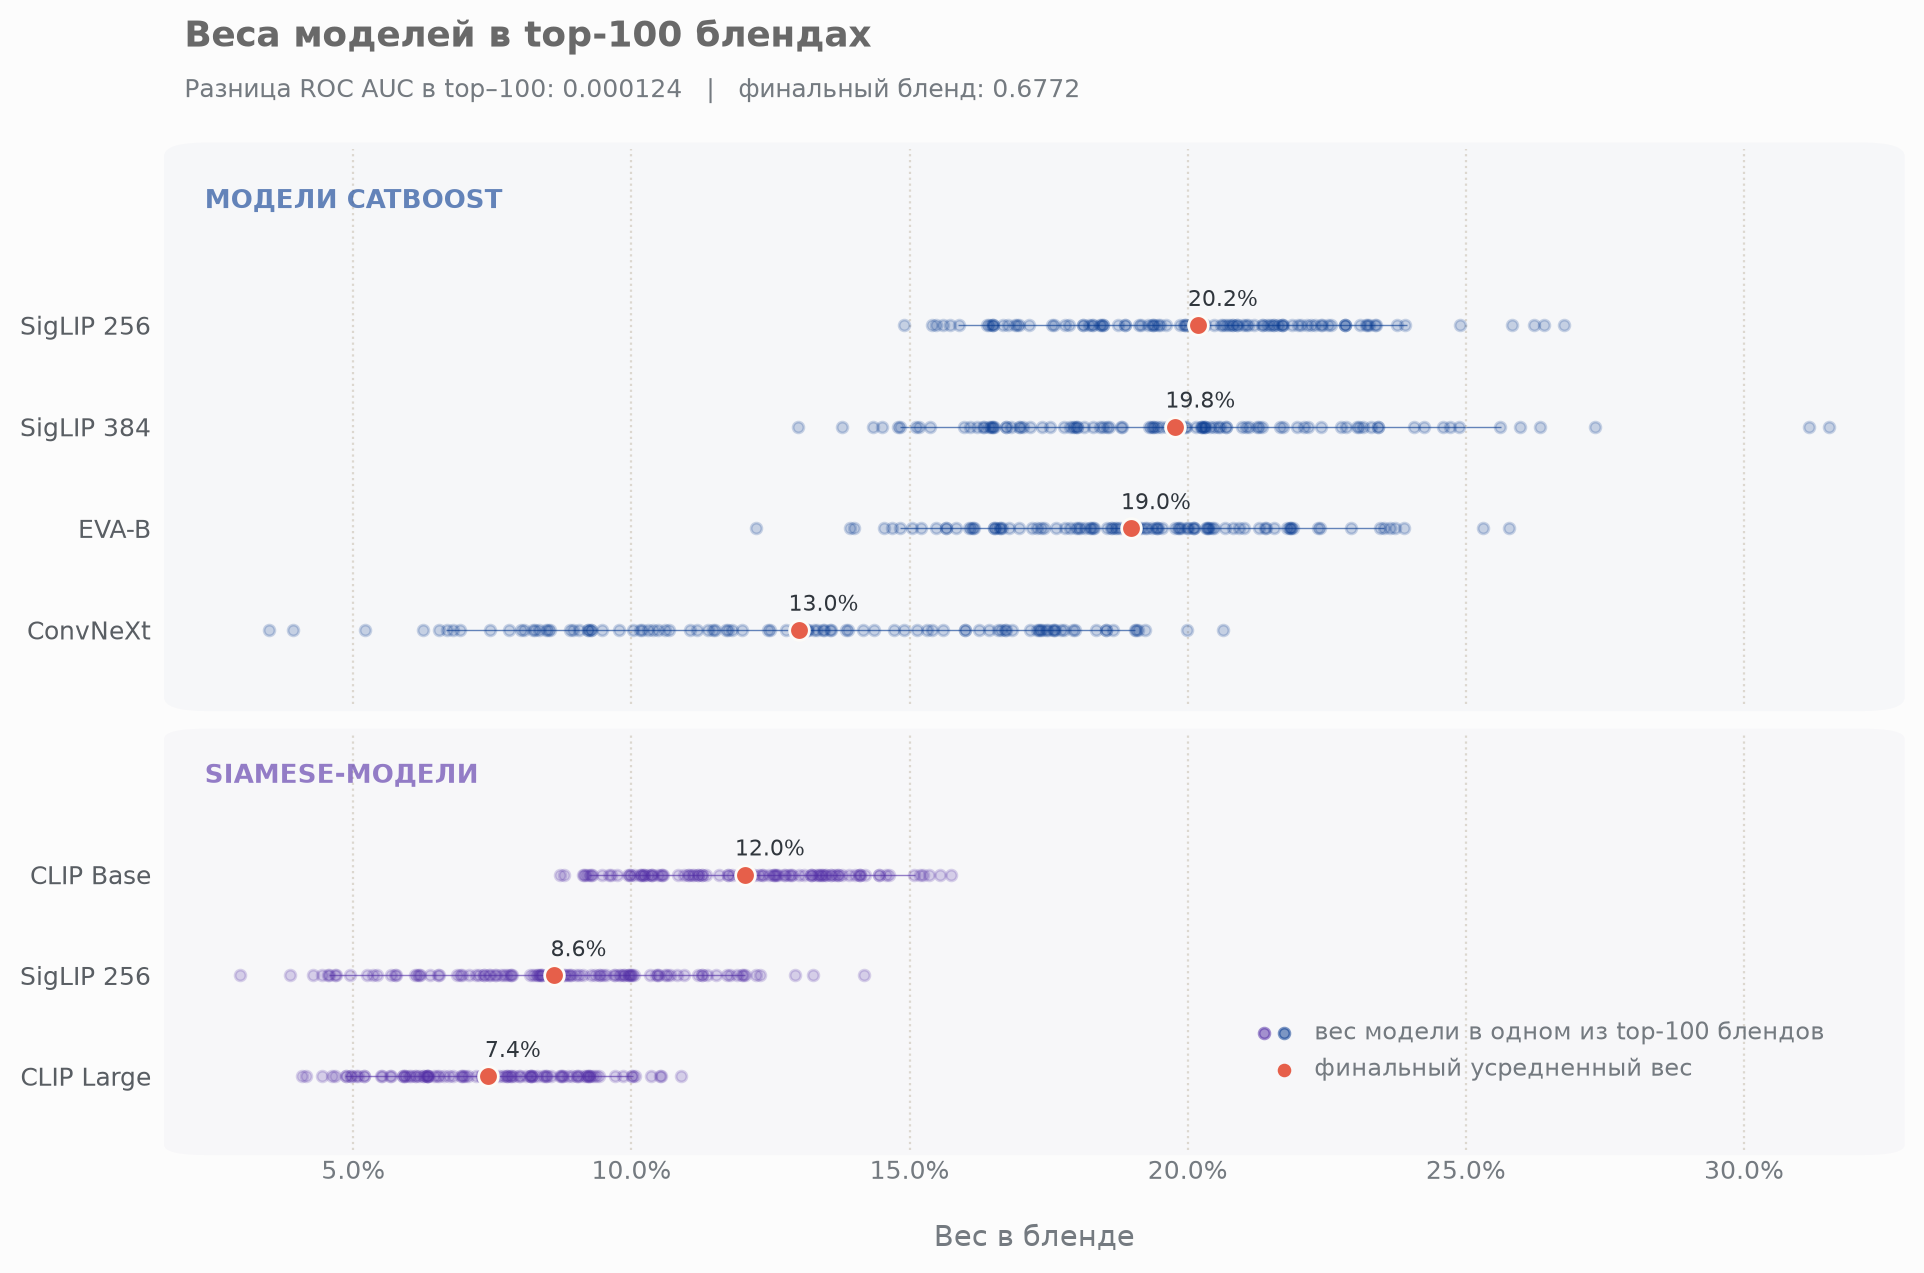

In [125]:
# визуализация диапазона весов

top_results = weight_search_results.nlargest(TOP_N, 'roc_auc').copy()

catboost_models = ['siglip_256_catboost', 'siglip_384_catboost', 'eva_b_catboost', 'convnext_catboost']
siamese_models = ['clip_base_siamese', 'siglip_256_siamese', 'clip_large_siamese']
all_models = catboost_models + siamese_models

display_names = {
    'siglip_256_catboost': 'SigLIP 256',
    'siglip_384_catboost': 'SigLIP 384',
    'eva_b_catboost': 'EVA-B',
    'convnext_catboost': 'ConvNeXt',
    'clip_base_siamese': 'CLIP Base',
    'siglip_256_siamese': 'SigLIP 256',
    'clip_large_siamese': 'CLIP Large'
}

x_min = max(0, top_results[all_models].min().min() - 0.01)
x_max = top_results[all_models].max().max() + 0.01

background_color = '#fcfcfc'
panel_color = '#FCFBF8'
text_color = '#30363D'
muted_text_color = '#747A80'
grid_color = '#DCD7CF'
catboost_color = "#02368F"
siamese_color = "#502BA5"
final_color = '#E65F4A'


def add_panel(ax, edge_color):
    panel = FancyBboxPatch((0, 0), 1, 1, transform=ax.transAxes, 
            boxstyle='round,pad=0.012,rounding_size=0.025', 
            facecolor=edge_color, linewidth=0, alpha=0.025, clip_on=False, zorder=-10)
    ax.add_patch(panel)


def draw_scatter_group(ax, models, color, title):
    y_positions = np.arange(len(models))[::-1] * 0.75
    add_panel(ax, color)

    for y, model in zip(y_positions, models):
        values = top_results[model].to_numpy()
        final_weight = final_weights[model]
        q_low, q_high = np.quantile(values, [0.05, 0.95])
        ax.hlines(y, q_low, q_high, color=color, linewidth=0.5, alpha=0.6, zorder=1)
        ax.scatter(values, np.full(len(values), y), s=15, color=color, alpha=0.2, edgecolor=color, zorder=2)
        ax.scatter(final_weight, y, s=50, marker='o', color='#E65F4A', edgecolor=panel_color, 
                   linewidth=1, zorder=4)
        ax.annotate(f'{final_weight:.1%}', xy=(final_weight, y), xytext=(9, 9), 
                   textcoords='offset points', va='center', ha='center', fontsize=8, color=text_color)

    ax.set_yticks(y_positions)
    ax.set_yticklabels([display_names[model] for model in models], fontsize=9, color=text_color, alpha=0.8)
    ax.text(0.012, 0.93, title, transform=ax.transAxes, ha='left', va='top', 
        fontsize=9.5, fontweight='bold', color=color, alpha=0.6)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(-0.55, len(models) - 0.45)
    ax.grid(axis='x', color=grid_color, linestyle=':', linewidth=0.8)
    ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
    ax.tick_params(axis='y', length=0, pad=12)
    ax.tick_params(axis='x', length=0, colors=muted_text_color, labelsize=9)


fig, axes = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True, 
    gridspec_kw={'height_ratios': [4, 3], 'hspace': 0.06})
fig.patch.set_facecolor(background_color)

for ax in axes:
    ax.set_facecolor(background_color)

draw_scatter_group(axes[0], catboost_models, catboost_color, 'МОДЕЛИ CATBOOST')
draw_scatter_group(axes[1], siamese_models, siamese_color, 'SIAMESE-МОДЕЛИ')

axes[0].tick_params(axis='x', labelbottom=False)
axes[1].xaxis.set_major_formatter(PercentFormatter(1))
axes[1].set_xlabel('Вес в бленде', fontsize=10.5, color=muted_text_color, labelpad=14)

legend_x = 0.68
legend_y = 0.2

plt.scatter(legend_x, legend_y, s=15, color=catboost_color, alpha=0.5, edgecolor=catboost_color, 
    transform=fig.transFigure, clip_on=False)
plt.scatter(legend_x-0.01, legend_y, s=15, color=siamese_color, alpha=0.5, edgecolor=siamese_color, 
    transform=fig.transFigure, clip_on=False)
fig.text(legend_x + 0.015, legend_y, f'вес модели в одном из top-{TOP_N} блендов', 
    ha='left', va='center', fontsize=8.5, color=muted_text_color)

plt.scatter(legend_x, legend_y - 0.028, s=15, color=final_color,  
    transform=fig.transFigure, clip_on=False)
fig.text(legend_x + 0.015, legend_y - 0.028, 'финальный усредненный вес', 
    ha='left', va='center', fontsize=8.5, color=muted_text_color)

top_auc = top_results['roc_auc']

fig.suptitle(f'Веса моделей в top-{TOP_N} блендах', x=0.13, y=0.98, ha='left', 
    fontsize=13, fontweight='bold', color='dimgrey')
fig.text(0.13, 0.92, (
    f'Разница ROC AUC в top–{TOP_N}: {(top_auc.max()-top_auc.min()):.6f}   |   '
    f'финальный бленд: {final_blend_auc:.4f}'
    ), ha='left', fontsize=9, color=muted_text_color)
plt.subplots_adjust(left=0.13, right=0.98, top=0.88, bottom=0.11)
plt.show()
print()

Топ-100 вариантов блендов дают почти одинаковый AUC при довольно разных весах, поэтому единственной оптимальной комбинации здесь нет. Сильнее всего меняется роль ConvNeXt, его вес меняется примерно от 3% до 21%. Но базовая структура бленда сохраняется, наибольшую долю получают CatBoost на SigLIP и EVA-B, а Siamese-модели добавляют более слабый дополнительный сигнал. Выбранные веса (красные) находятся внутри основных скоплений точек, то есть финальный бленд это типичное решение среди лучших.

---

## Final prediction

In [126]:
# # формируем финальный submission

# submission = sample_submission.copy()
# submission['is_image1_better'] = final_blend_test

# assert len(submission) == len(final_blend_test)
# assert ((final_blend_test >= 0) & (final_blend_test <= 1)).all()

# submission_path = SUBMISSIONS_DIR / 'final_weighted_blend_submission.csv'
# submission.to_csv(submission_path, index=False)

# print(f'submission saved: {submission_path}')
# print(f'submission shape: {submission.shape}')

# submission.head()

---

# Error analisys

### Распределение OOF-скоров по истинному таргету

In [127]:
error_view_df = train[['image_1', 'image_2', 'is_image1_better']].copy()
error_view_df['final_oof'] = final_blend_oof

error_view_df['correct_class_score'] = np.where(
    error_view_df['is_image1_better'] == 1,
    error_view_df['final_oof'],
    1 - error_view_df['final_oof']
)

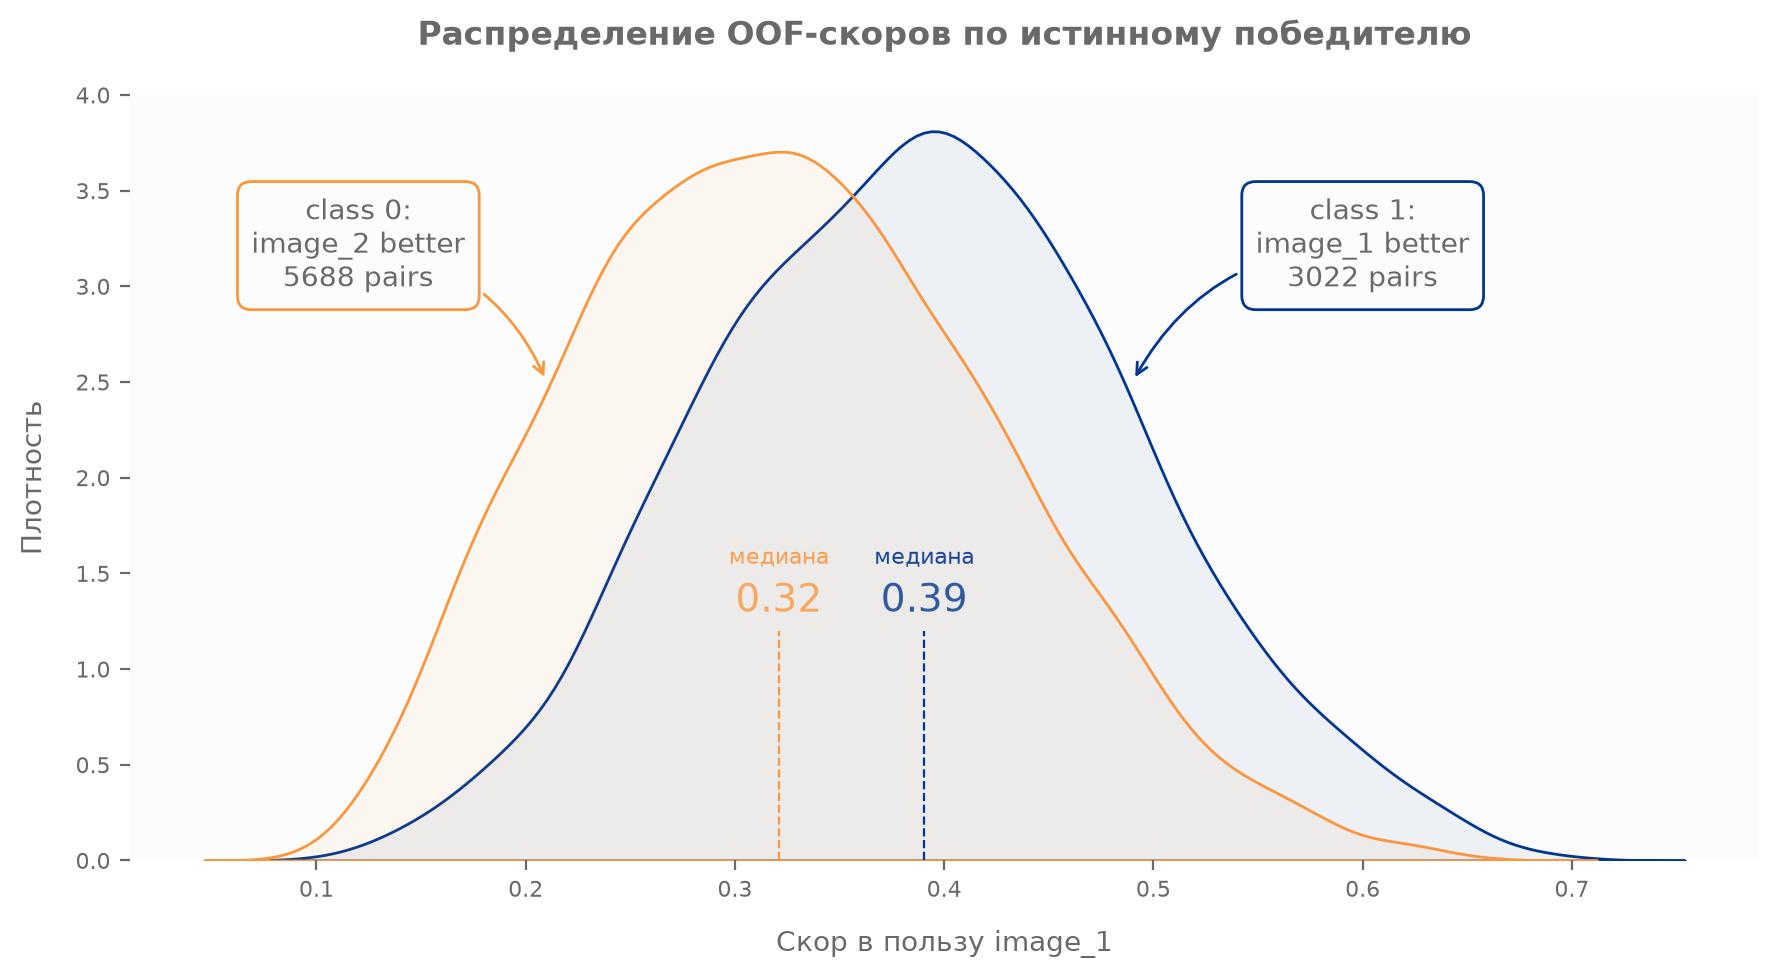

In [128]:
plot_df = error_view_df.copy()

palette = {0: '#FC963C', 1: '#02368F'}
labels = {0: 'image_2 better', 1: 'image_1 better'}
facecolor = '#fcfcfc'

fig, ax = plt.subplots(figsize=(9, 5))
ax.set_facecolor(facecolor)

# kde
sns.kdeplot(data=plot_df, x='final_oof', hue='is_image1_better', hue_order=[0, 1],
            common_norm=False, fill=True, alpha=0.06, linewidth=1, palette=palette, ax=ax)

# статистики
class_stats = (
    error_view_df.groupby('is_image1_better')['final_oof']
    .agg(count='count', median='median')
)

# медианы
for class_id in [0, 1]:
    median = class_stats.loc[class_id, 'median']
    ax.axvline(median, ymin=0, ymax=0.3, ls='--', color=palette[class_id], lw=0.8)
    ax.text(median, 1.55, 'медиана', ha='center', color=palette[class_id], fontsize=8, alpha=0.9)
    ax.text(median, 1.3, f'{median:.2f}', ha='center', color=palette[class_id], fontsize=14, alpha=0.8)

# аннотация
ax.annotate(f'class 0:\n{labels[0]}\n{class_stats.loc[0, "count"]} pairs', xy=(0.21, 2.5), xytext=(0.12, 3),
            ha='center', color='dimgrey', 
            bbox=dict(boxstyle='round,pad=0.5', fc=facecolor, ec=palette[0]),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=-0.3', color=palette[0], lw=1))

ax.annotate(f'class 1:\n{labels[1]}\n{class_stats.loc[1, "count"]} pairs', xy=(0.49, 2.5), xytext=(0.60, 3),
            ha='center', color='dimgrey', 
            bbox=dict(boxstyle='round,pad=0.5', fc=facecolor, ec=palette[1]),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3', color=palette[1], lw=1))

# settings
ax.set_title('Распределение OOF-скоров по истинному победителю', loc='center',
             fontsize=12, fontweight='bold', color='dimgrey', pad=18)
ax.set_xlabel('Скор в пользу image_1', fontsize=10, color='dimgrey', labelpad=10)
ax.set_ylabel('Плотность', fontsize=10, color='dimgrey', labelpad=10)
ax.tick_params(axis='both', labelsize=8, colors='dimgrey')
ax.grid(axis='both', visible=False)

ax.get_legend().remove()
sns.despine(ax=ax)
ax.spines[['left', 'bottom']].set_visible(False)
plt.tight_layout()
plt.show()

OOF-скоры для побед image_1 сдвинуты вправо (class 1), для побед image_2 – влево (class 0). Распределения сильно пересекаются, для большинства пар разделение остается нечетким.

---

### Крайние расхождения модели и разметки

In [129]:
N_MISTAKES_PER_CLASS = 50

# image_1 победила, но модель склонялась к image_2
low_score_image1_winners = (
    error_view_df[error_view_df['is_image1_better'] == 1]
    .nsmallest(N_MISTAKES_PER_CLASS, 'final_oof')
    .reset_index(names='pair_id')
)

# image_2 победила, но модель склонялась к image_1
high_score_image2_winners = (
    error_view_df[error_view_df['is_image1_better'] == 0]
    .nlargest(N_MISTAKES_PER_CLASS, 'final_oof')
    .reset_index(names='pair_id')
)

In [130]:
# NOTE: Блок кода с интерактивным выводом карточек для сравнения выбора модели и комиссии
# не рендерится валидно на GitHub. Ниже альтернативный блок через matplotlib.
# --------------------------------------------------------------------------

# HTML-галерея карточек для анализа пар с сильным расхождением модели и разметки комиссии

# бинарная картинка -> в base64-строку для вставки в HTML
def image_to_base64(image_bytes, size=200, quality=85):
    image = decode_image(image_bytes)
    image = resize_with_padding(image, size=size)

    buffer = io.BytesIO()
    image.save(buffer, format='JPEG', quality=quality, optimize=True)

    return base64.b64encode(buffer.getvalue()).decode()

# карточка для пары картинок
def render_pair_cards(df, title, chunk_size=10, target_col='is_image1_better'):
    def build_cards(cards_df):
        cards_html = []

        for _, row in cards_df.iterrows():
            winner_col = None
            pair_id = row['pair_id'] if 'pair_id' in row.index else row.name

            if target_col in row.index:
                winner_col = 'image_1' if row[target_col] == 1 else 'image_2'

            imgs_html = []

            # собрали строку из двух картинок
            for col_idx, col in enumerate(['image_1', 'image_2'], start=1):
                if col == winner_col:
                    label = f'Выбор комиссии [{col_idx}]'
                    label_class = 'winner-label'
                else:
                    label = f'pair {pair_id} [{col_idx}]'
                    label_class = 'pair-id-label'

                img_base64 = image_to_base64(row[col])

                imgs_html.append(f"""
                    <div class="image-block">
                        <div class="image-label {label_class}">{label}</div>
                        <img src="data:image/jpeg;base64,{img_base64}" />
                    </div>
                """)

            # добавили в массив карточек
            cards_html.append(f"""<div class="grid-card">{''.join(imgs_html)}</div>""")

        return ''.join(cards_html)

    # разбивает датафрейм на чанки по chunk_size пар во вложенные раскрывающиеся HTML-блоки
    def build_chunks(start):
        chunk_df = df.iloc[start:start + chunk_size]
        chunk_start = start + 1
        chunk_end = start + len(chunk_df)

        if len(chunk_df) == 0:
            return ''

        # первый чанк
        if start == 0:
            return f"""
                <div class="pair-page-label">Пары изображений {chunk_start}–{chunk_end} из {len(df)}</div>
                <div class="grid-container">{build_cards(chunk_df)}</div>
                {build_chunks(start + chunk_size)}
            """

        # следующие чанки - в details
        return f"""
            <details class="more-pairs">
                <summary>Показать пары {chunk_start}–{chunk_end} из {len(df)}</summary>
                <div class="grid-container">{build_cards(chunk_df)}</div>
                {build_chunks(start + chunk_size)}
            </details>
        """

    chunks_html = build_chunks(0)

    html = f"""
    <style>
        .grid-container {{display: grid; grid-template-columns: repeat(auto-fit, minmax(300px, 1fr)); gap: 15px; margin-top: 12px;}}
        .grid-card {{display: grid; grid-template-columns: 1fr 1fr; gap: 10px; padding: 12px; border: 1px solid #d1d5db; border-radius: 8px; background: #f8fafc; max-width: 520px; justify-self: center;}}
        .image-block {{display: flex; flex-direction: column; gap: 6px; min-width: 0;}}
        .image-label {{display: flex; height: 25px; align-items: center; justify-content: center; text-align: center; font-size: 12px;}}
        .winner-label {{color: #30363d;}}
        .pair-id-label {{color: #9ca3af;}}
        .image-block img {{width: 100%; aspect-ratio: 1 / 1; object-fit: contain; background: white;}}
        .more-pairs {{margin-top: 14px;}}
        .more-pairs summary {{cursor: pointer; color: #365489; font-weight: 600; font-size: 13px; margin: 10px 0;}}
        .pair-page-label {{margin: 8px 0 6px; font-size: 12px; color: #9ca3af; text-align: center;}}
    </style>

    <h3 style="text-align:center; color:dimgrey; margin-bottom:14px; font-size:16px">{title}</h3>

    {chunks_html}
    """

    display(HTML(html))

In [136]:
# # NOTE: Закомментировано для GitHub ipynb-renderer, ниже альтернативный вывод через mtplotlib

# CHUNK_SIZE = 6

# render_pair_cards(
#     low_score_image1_winners,
#     'Комиссия выбрала image_1, но модель дала ей самые низкие скоры',
#     chunk_size=CHUNK_SIZE
# )

# render_pair_cards(
#     high_score_image2_winners,
#     'Комиссия выбрала image_2, но модель дала image_1 самые высокие скоры',
#     chunk_size=CHUNK_SIZE
# )

In [137]:
# NOTE: Альтернативный вывод через matplotlib, без интерактивных чанков

N_PAIRS = 6

low_score_errors_path = 'files/low_score_errors.png'
high_score_errors_path = 'files/high_score_errors.png'

# сохраняем в отдельные PNG-файлы
plot_pair_cards(
    low_score_image1_winners,
    'Комиссия выбрала image_1, но модель дала ей самые низкие скоры',
    n_pairs=N_PAIRS, save_path=low_score_errors_path,
)

plot_pair_cards(
    high_score_image2_winners,
    'Комиссия выбрала image_2, но модель дала image_1 самые высокие скоры',
    n_pairs=N_PAIRS, save_path=high_score_errors_path,
)

# показываем сохраненные картинки
display(HTML(f"""
<img src="./{low_score_errors_path}?ts={time.time()}" style="max-width:100%; height:auto;">
"""))

display(HTML(f"""
<img src="./{high_score_errors_path}?ts={time.time()}" style="max-width:100%; height:auto;">
"""))


Расхождения в оценках модели и комиссии не выглядят как очевидные ошибки модели. Во многих парах альтернативное изображение не уступает выбору комиссии ни по техническому, ни по визуальному качеству. 

**Комиссия выбрала image_1, но модель дала ей самые низкие скоры**.    
В этом блоке примерно в половине случаев выбор комиссии выглядит однозначным, но есть сомнительные решения: выше ранжируются картинки с ошибками рендеринга текста, провалами в тенях или выбитыми светами, нарушениями пространственной логики, анатомии и заметными генеративными артефактами. Иногда оба изображения технически качественные, но различаются по содержанию и стилистике. Возможно, комиссия выбирала вариант, который точнее соответствовал исходному промпту, недоступному модели.

**Комиссия выбрала image_2, но модель дала image_1 самые высокие скоры**.    
В этом блоке я склонна больше согласиться с моделью, чем с выбором комиссии, примерно в 90% случаев. Особенно удивляет выбор в пользу изображения символа `#` вместо полноценной иллюстрации. Такие изображения встречаются много раз, имеют разные хеши и, вероятно, были намеренно добавлены в датасет с аугментациями. 
Это могут быть контрольные примеры или следствие правила разметки, которое нельзя восстановить только по изображениям. 

---

### ROC AUC по pair cosine similarity

In [133]:
error_view_df['pair_cosine_sim'] = 1 - paired_cosine_distances(
    siglip_256_train_emb['image_1'],
    siglip_256_train_emb['image_2']
)

In [134]:
similarity_auc_df = (
    error_view_df
    .assign(similarity_bin=pd.qcut(error_view_df['pair_cosine_sim'], 10))
    .groupby('similarity_bin', observed=True)
    .apply(lambda x: pd.Series({
        'n_pairs': len(x),
        'mean_cosine_sim': x['pair_cosine_sim'].mean(),
        'n_pos': x['is_image1_better'].sum(),
        'n_neg': len(x) - x['is_image1_better'].sum(),
        'roc_auc': roc_auc_score(x['is_image1_better'], x['final_oof'])
    }))
    .reset_index()
)

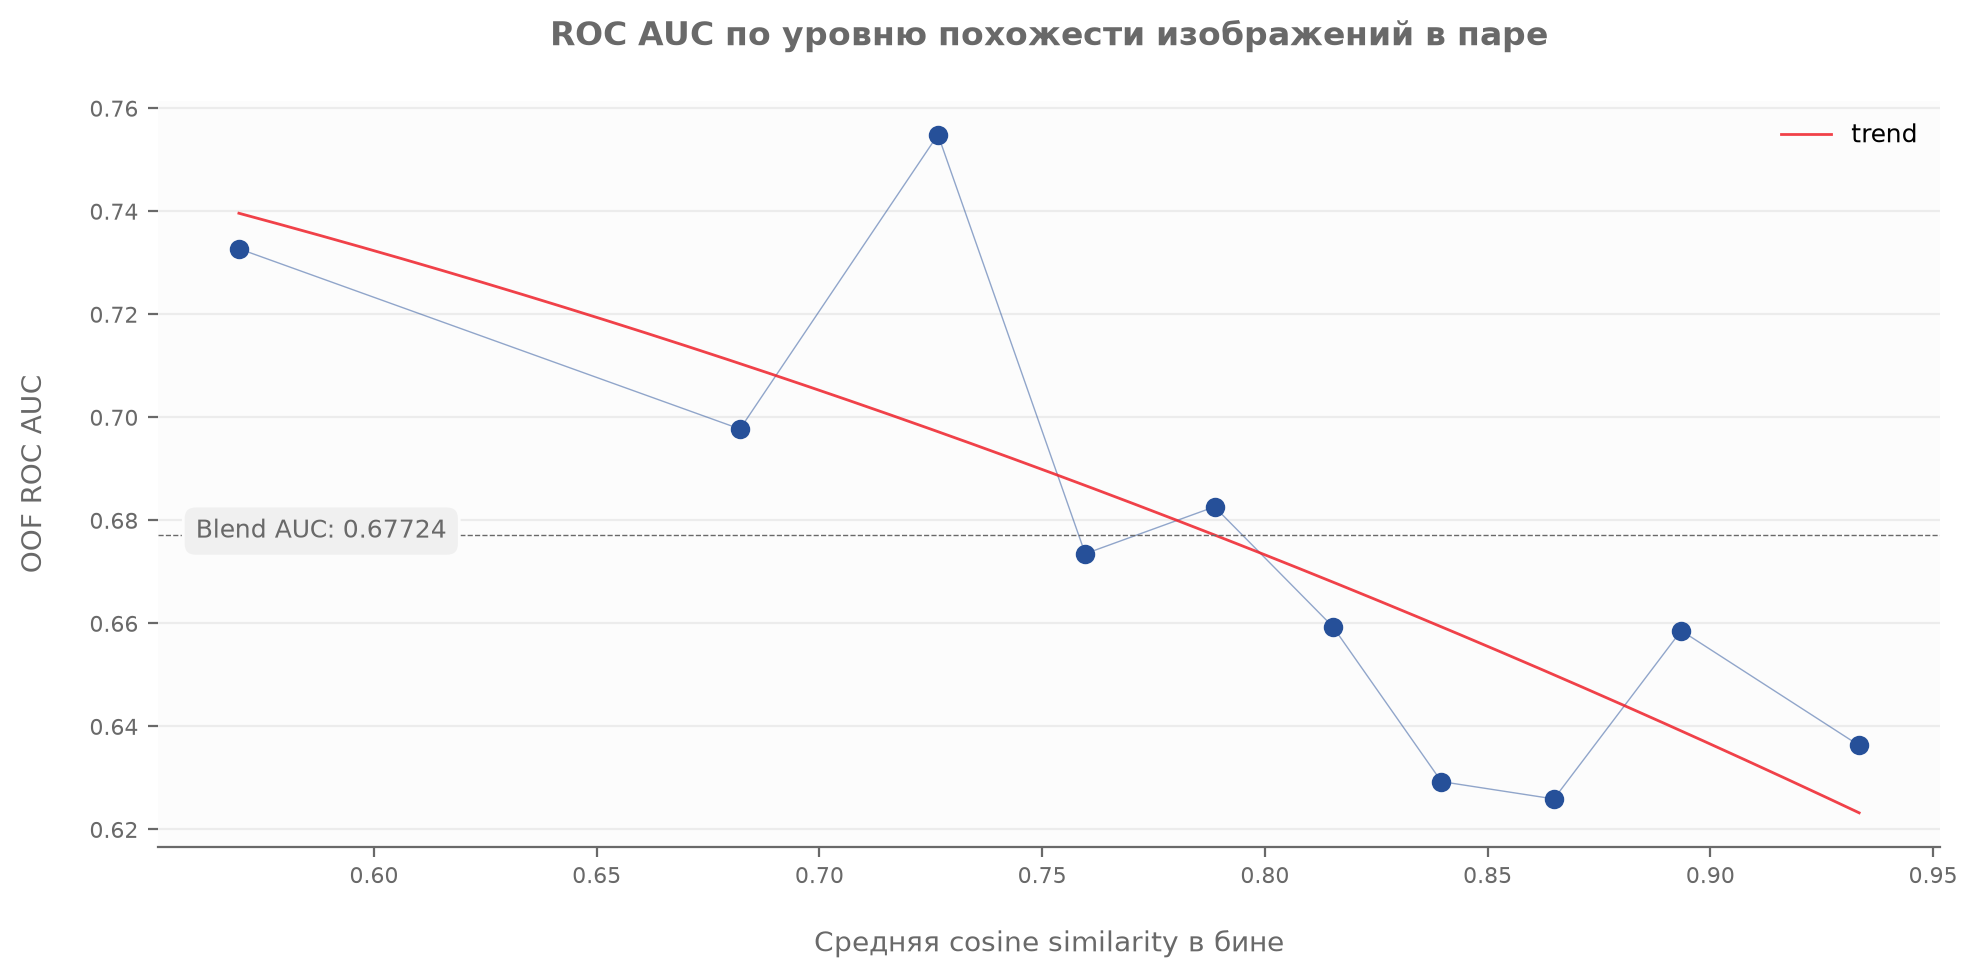

In [135]:
fig, ax = plt.subplots(figsize=(10, 5))

facecolor = "#fcfcfc"
ax.set_facecolor(facecolor)

ax.plot(similarity_auc_df['mean_cosine_sim'], similarity_auc_df['roc_auc'], marker='o', color="#265099", lw=0, )
ax.plot(similarity_auc_df['mean_cosine_sim'], similarity_auc_df['roc_auc'], color="#265099", lw=0.5, alpha=0.5)

# trend
x = similarity_auc_df['mean_cosine_sim'].to_numpy()
y = similarity_auc_df['roc_auc'].to_numpy()
trend_coef = np.polyfit(x, y, deg=2)
trend_poly = np.poly1d(trend_coef)

x_smooth = np.linspace(x.min(), x.max(), 200)
y_smooth = trend_poly(x_smooth)

ax.plot(x_smooth, y_smooth, color='#ef2029', lw=1, alpha=0.85, label='trend')

# blend auc
ax.axhline(final_blend_auc, ls='--', lw=0.5,c='dimgrey')
ax.text(0.56,  final_blend_auc*1.001, f'Blend AUC: {final_blend_auc:.5f}',ha='left', va='center', fontsize=9, color='dimgrey',
        bbox=dict(boxstyle='round,pad=0.5', fc="#f0f0f0", ec=facecolor))

# settings
ax.set_title('ROC AUC по уровню похожести изображений в паре', fontsize=12, fontweight='bold', color='dimgrey', pad=20)
ax.set_xlabel('Средняя cosine similarity в бине', fontsize=10, color='dimgrey', labelpad=15)
ax.set_ylabel('OOF ROC AUC', fontsize=10, color='dimgrey', labelpad=15)
ax.tick_params(axis='x', colors='dimgrey', labelsize=8)
ax.tick_params(axis='y', colors='dimgrey', labelsize=8)
ax.grid(axis='y', alpha=0.2)
ax.grid(axis='x', visible=False)
ax.legend(frameon=False, fontsize=9, )

sns.despine()
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('dimgrey')
plt.tight_layout()
plt.show()

Чем сильнее похожи изображения, тем хуже модель воспроизводит выбор комиссии. Зависимость не монотонная, но общий нисходящий тренд есть. Качество колеблется между соседними бинами, что может быть связано как с ограничениями модели, так и более субъективным выбором комиссии между похожими картинками.

---

# Outro

<style>
p, li { font-size: 14px; line-height: 1.3; margin:14px 0;}
</style>
<p>В этой задаче не сработала идея "взять самый большой энкодер и получить лучший результат". Гораздо полезнее оказалось объединить модели, которые по-разному сравнивают одни и те же изображения: CatBoost давал самый сильный самостоятельный результат, а Siamese-модели добавляли отличающиеся предсказания. Усреднение по сидам и отбор моделей сделали финальный бленд стабильнее. При этом часть выбора комиссии нельзя восстановить только по картинкам, без исходного промпта сложно понять спорные решения, особенно для очень похожих изображений.</p>

<p>Что можно было попробовать дальше:</p>
<ol>

<li>Найти группы аугментированных версий одних и тех же изображений и использовать GroupKFold, чтобы близкие варианты одной картинки не оказывались одновременно в train и validation. По хешам все файлы уникальны, поэтому группы придется собирать по визуальному сходству.</li>

<li>Провести небольшой тюнинг Siamese comparator. Текущая архитектура выбрана по базовым разумным настройкам, но отдельно не оптимизировалась.</li>

<li>Проверить признаки специализированных image quality и human preference моделей. Text-image alignment здесь вряд ли поможет, поскольку исходные промпты неизвестны.</li>

<li>Проверить парный рейтинг Bradley-Terry: построить граф сравнений между группами аугментированных изображений или учить рейтинг картинки по ее эмбеддингу, чтобы модель могла оценивать новые изображения.</li>

</ol>

&nbsp;

<br>

&nbsp;

&nbsp;

&nbsp;